# Dataset Inspection: AIT-ADS

Reproduces the analysis + plots from the old `run_eda.py` / `run_eda_host.py` scripts for the AIT-ADS scenarios (fox, harrison, russellmitchell, santos, shaw, wardbeck, wheeler, wilson), via `thesis.data.eda` (computation) and `thesis.visualization.eda` (plotting). Output is written under `artifacts/experiments/run_eda/` the same way the script did, plus inline display here.

In [1]:
import sys
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd

REPO = Path.cwd().resolve().parents[3]  # src/thesis/notebooks/eda -> repo root
sys.path.insert(0, str(REPO / 'src'))

import thesis.data.eda as de
from thesis.configs import load_scenarios
from thesis.visualization.eda import load_alerts

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)

DATASET = 'ait-ads'
DATA_DIR = REPO / 'data' / 'alerts_csv'
ALERT_GROUPS_BASE_DIR = REPO / 'artifacts' / 'alert_groups'
scenarios = load_scenarios(DATASET)
print(f'Scenarios: {scenarios}')

run_ts = datetime.now(timezone.utc).strftime('%Y%m%d_%H%M%S')
run_dir = REPO / 'artifacts' / 'experiments' / 'run_eda' / DATASET / f'run_{run_ts}_raw'
run_dir.mkdir(parents=True, exist_ok=True)
summary_dir = run_dir / 'summary'
print(f'Output dir: {run_dir}')

Scenarios: ['fox', 'harrison', 'russellmitchell', 'santos', 'shaw', 'wardbeck', 'wheeler', 'wilson']
Output dir: /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/run_eda/ait-ads/run_20260905_160546_raw


## Load alerts

In [2]:
all_df = load_alerts(str(DATA_DIR), scenarios=scenarios, dataset=DATASET)
print(f'{len(all_df):,} alerts loaded.')
all_df.head()

2,655,821 alerts loaded.


,time,name,ip,host,short,time_label,event_label,timestamp,scenario,label,signature,is_attack
0,1642213952,Wazuh: ClamAV database update,172.17.131.81,mail,W-Sys-Cav,false_positive,-,2022-01-15 02:32:32+00:00,fox,false_positive,Wazuh: ClamAV database update,False
1,1642213952,Wazuh: ClamAV database update,192.168.128.170,jonesmorgan_mail,W-Sys-Cav,false_positive,-,2022-01-15 02:32:32+00:00,fox,false_positive,Wazuh: ClamAV database update,False
2,1642213957,Wazuh: ClamAV database update,172.17.131.81,mail,W-Sys-Cav,false_positive,-,2022-01-15 02:32:37+00:00,fox,false_positive,Wazuh: ClamAV database update,False
3,1642213962,Wazuh: ClamAV database update,172.17.131.81,mail,W-Sys-Cav,false_positive,-,2022-01-15 02:32:42+00:00,fox,false_positive,Wazuh: ClamAV database update,False
4,1642213967,Wazuh: ClamAV database update,172.17.131.81,mail,W-Sys-Cav,false_positive,-,2022-01-15 02:32:47+00:00,fox,false_positive,Wazuh: ClamAV database update,False


## Phase 1a: class balance & headline counts

One row per scenario: duration, raw-alert counts + attack % (time-based label), fixed-2s-window alert_group counts + attack %, signature counts (total + benign-only/attack-only/mixed split), and how many distinct attack labels ("attack stages") occur. The numbers behind `tab:ait-eda-summary` in the write-up. Builds each scenario's alert_groups cache if it doesn't already exist yet (so this can run before or after Phase 1 either way).

In [3]:
ait_eda_summary = de.compute_ait_eda_summary_table(
    all_df, scenarios=scenarios, alert_groups_base_dir=ALERT_GROUPS_BASE_DIR
)
ait_eda_summary.to_csv(run_dir / 'ait_eda_summary_table.csv', index=False)
ait_eda_summary

  fox: alert_groups cache exists → /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/alert_groups/raw/fox_alert_groups.csv (skipping)
  harrison: alert_groups cache exists → /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/alert_groups/raw/harrison_alert_groups.csv (skipping)
  russellmitchell: alert_groups cache exists → /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/alert_groups/raw/russellmitchell_alert_groups.csv (skipping)
  santos: alert_groups cache exists → /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/alert_groups/raw/santos_alert_groups.csv (skipping)
  shaw: alert_groups cache exists → /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/alert_groups/raw/shaw_alert_groups.csv (skipping)
  wardbeck: alert_groups cache exists → /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/alert_groups/raw/wardbeck_alert_groups.csv (skipping)
  wheeler: alert_groups cache exists → /Users/annavisman/stack/TUDelft/thesis/msc-th

,scenario,duration_days,total_alerts,benign_alerts,attack_alerts,attack_pct,n_groups_2s,attack_pct_groups,n_signatures,signatures_benign_attack_mixed,n_attack_stages
0,fox,5,473104,51451,421653,89.1,10310,7.9,77,30 / 11 / 36,10
1,harrison,5,593948,162456,431492,72.6,34594,4.9,78,25 / 17 / 36,10
2,russellmitchell,4,45544,33529,12015,26.4,5593,3.2,72,25 / 16 / 31,10
3,santos,4,130779,117775,13004,9.9,22540,1.4,84,30 / 14 / 40,10
4,shaw,6,70782,63847,6935,9.8,10397,1.5,73,31 / 11 / 31,10
5,wardbeck,5,91257,84217,7040,7.7,11757,1.4,80,29 / 14 / 37,10
6,wheeler,5,616161,183827,432334,70.2,20981,2.9,78,29 / 16 / 33,9
7,wilson,6,634246,194138,440108,69.4,26525,4.6,86,35 / 14 / 37,10


## Phase 1: per-scenario alert_groups

Builds the fixed 2-second-window alert_groups for each scenario and caches them to `artifacts/alert_groups/raw/<scenario>_alert_groups.csv` -- skips rebuilding a scenario if that cache file already exists. Phase 2's alert_group volume plots read this cache.

In [4]:
for scenario in scenarios:
    scenario_df = all_df[all_df['scenario'] == scenario].copy()
    de.build_scenario_alert_groups(
        scenario_df,
        scenario,
        alert_groups_base_dir=ALERT_GROUPS_BASE_DIR,
    )

  fox: alert_groups cache exists → /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/alert_groups/raw/fox_alert_groups.csv (skipping)
  harrison: alert_groups cache exists → /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/alert_groups/raw/harrison_alert_groups.csv (skipping)
  russellmitchell: alert_groups cache exists → /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/alert_groups/raw/russellmitchell_alert_groups.csv (skipping)
  santos: alert_groups cache exists → /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/alert_groups/raw/santos_alert_groups.csv (skipping)
  shaw: alert_groups cache exists → /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/alert_groups/raw/shaw_alert_groups.csv (skipping)
  wardbeck: alert_groups cache exists → /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/alert_groups/raw/wardbeck_alert_groups.csv (skipping)
  wheeler: alert_groups cache exists → /Users/annavisman/stack/TUDelft/thesis/msc-th

## Phase 1b: signature behaviour & temporal stability (CSCAS parity)

Ports the CSCAS notebook's signature-vocabulary-churn / signature-behaviour-summary / overview-CSV sections so both datasets' write-ups can quote comparable plots and tables for the EDA questions "signature behaviour" and "temporal stability": signature purity (always-benign / always-attack / mixed), volume concentration and persistence, whether the active-signature set turns over across the window or saturates early, and whether attacks arrive at a steady rate or cluster into bursts. Run per scenario (each AIT-ADS scenario is its own ~3-6 day window, so `bin_freq='1h'` here vs. CSCAS's `12h`). Writes a text summary + plots per scenario, and overview CSVs mirroring CSCAS's `overview_csvs/`.

  Running signature-behaviour EDA for scenario 'fox'...


/Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/visualization/eda.py:1064: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 12.
  plt.tight_layout()
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/data/eda.py:79: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 12.
  fig.savefig(out_path, dpi=150, bbox_inches="tight")


  fox: signature-behaviour EDA done → /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/run_eda/ait-ads/run_20260905_160546_raw/fox
  Running signature-behaviour EDA for scenario 'harrison'...


/Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/visualization/eda.py:1064: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 12.
  plt.tight_layout()
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/data/eda.py:79: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 12.
  fig.savefig(out_path, dpi=150, bbox_inches="tight")


  harrison: signature-behaviour EDA done → /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/run_eda/ait-ads/run_20260905_160546_raw/harrison
  Running signature-behaviour EDA for scenario 'russellmitchell'...


...

/Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/visualization/eda.py:1064: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 12.
  plt.tight_layout()
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/data/eda.py:79: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 12.
  fig.savefig(out_path, dpi=150, bbox_inches="tight")


  santos: signature-behaviour EDA done → /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/run_eda/ait-ads/run_20260905_160546_raw/santos
  Running signature-behaviour EDA for scenario 'shaw'...
  shaw: signature-behaviour EDA done → /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/run_eda/ait-ads/run_20260905_160546_raw/shaw
  Running signature-behaviour EDA for scenario 'wardbeck'...


/Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/visualization/eda.py:868: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=figsize)


  wardbeck: signature-behaviour EDA done → /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/run_eda/ait-ads/run_20260905_160546_raw/wardbeck
  Running signature-behaviour EDA for scenario 'wheeler'...
  wheeler: signature-behaviour EDA done → /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/run_eda/ait-ads/run_20260905_160546_raw/wheeler
  Running signature-behaviour EDA for scenario 'wilson'...
  wilson: signature-behaviour EDA done → /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/run_eda/ait-ads/run_20260905_160546_raw/wilson


/opt/miniconda3/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 12.
  func(*args, **kwargs)


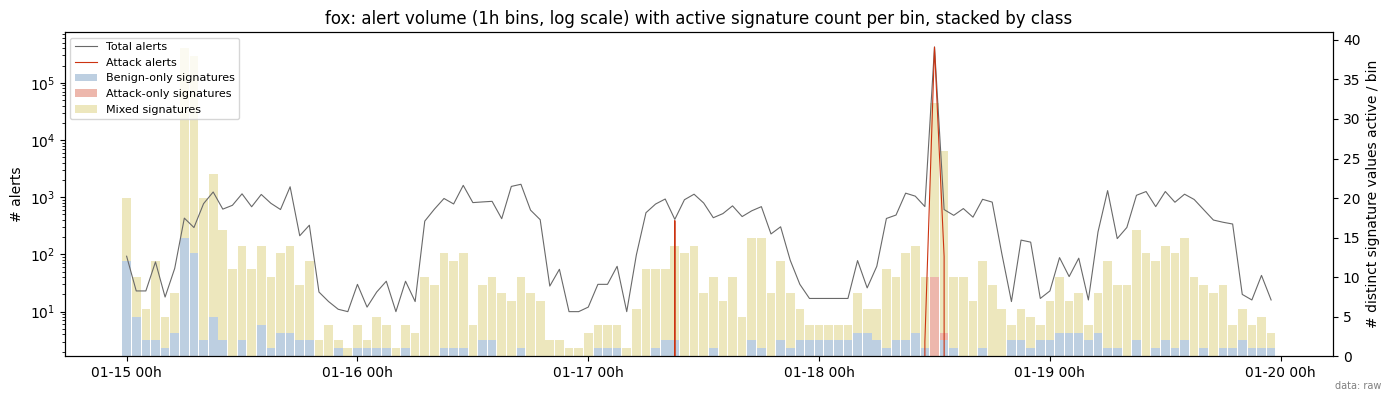

/opt/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 12.
  fig.canvas.print_figure(bytes_io, **kw)


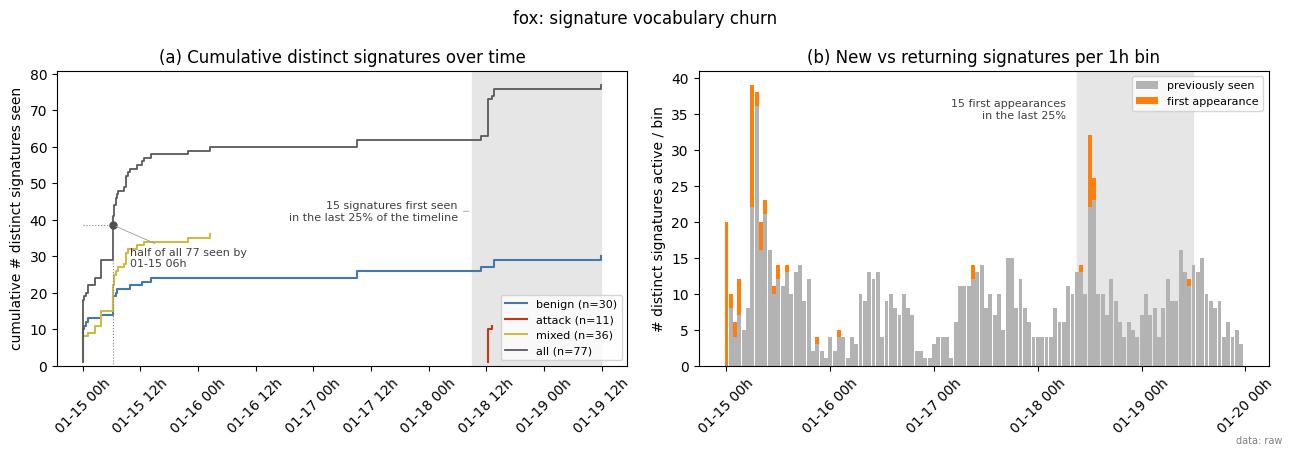

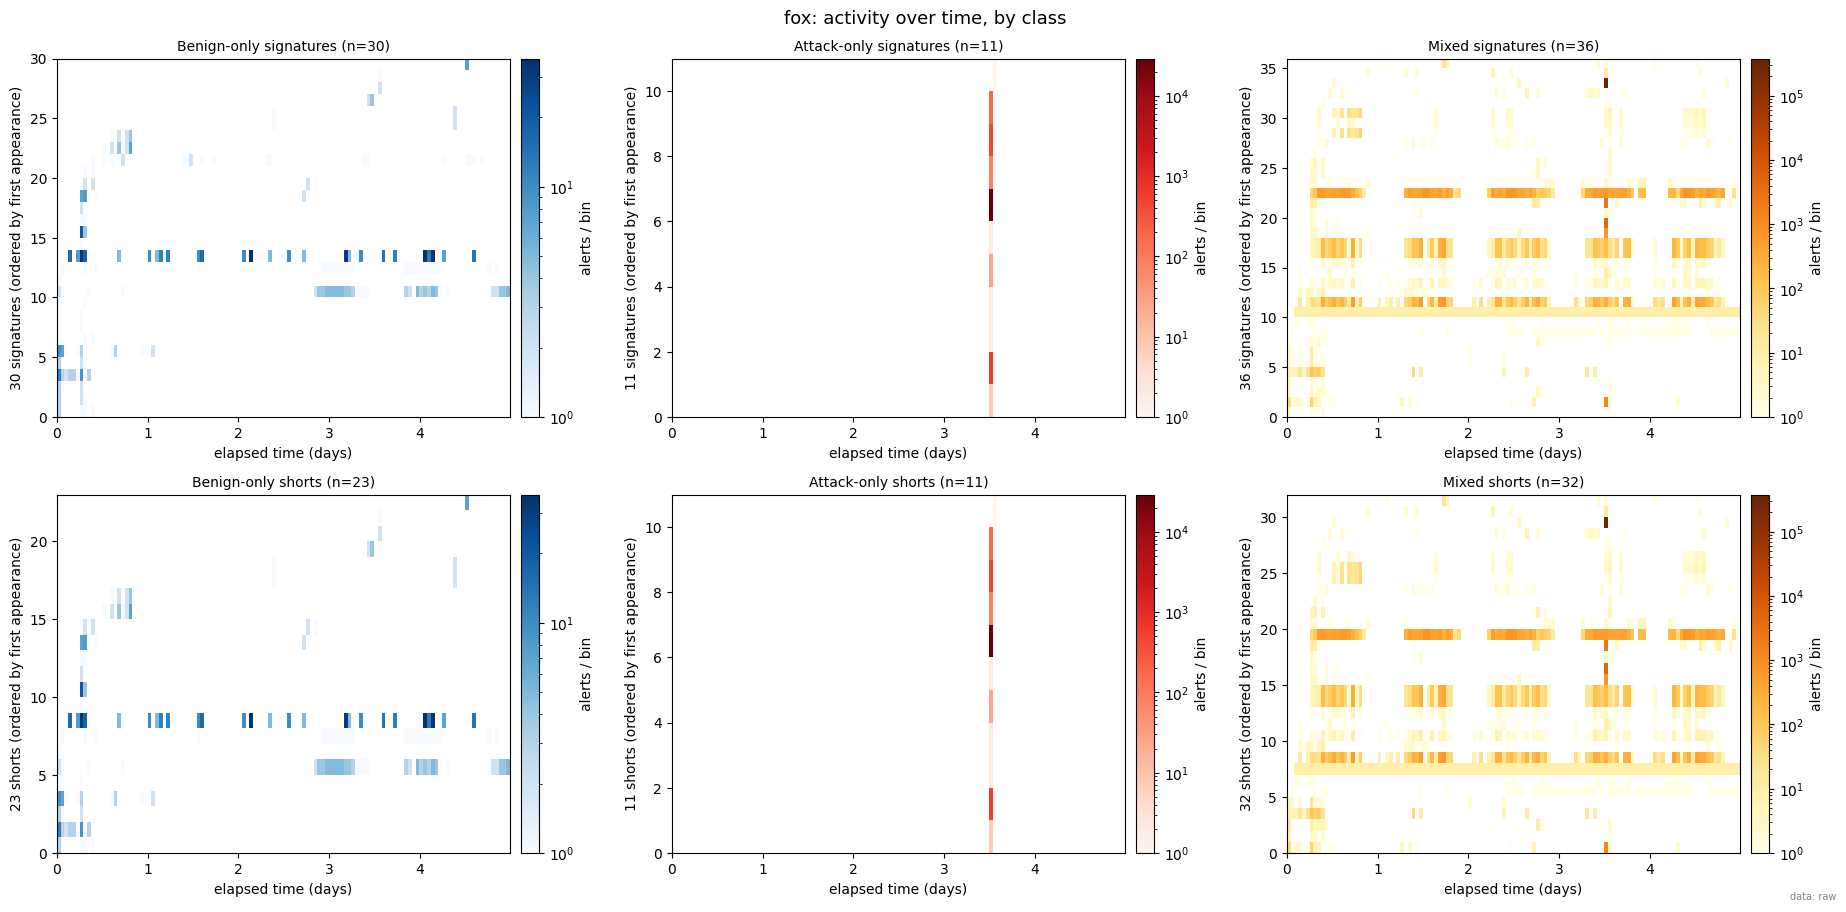

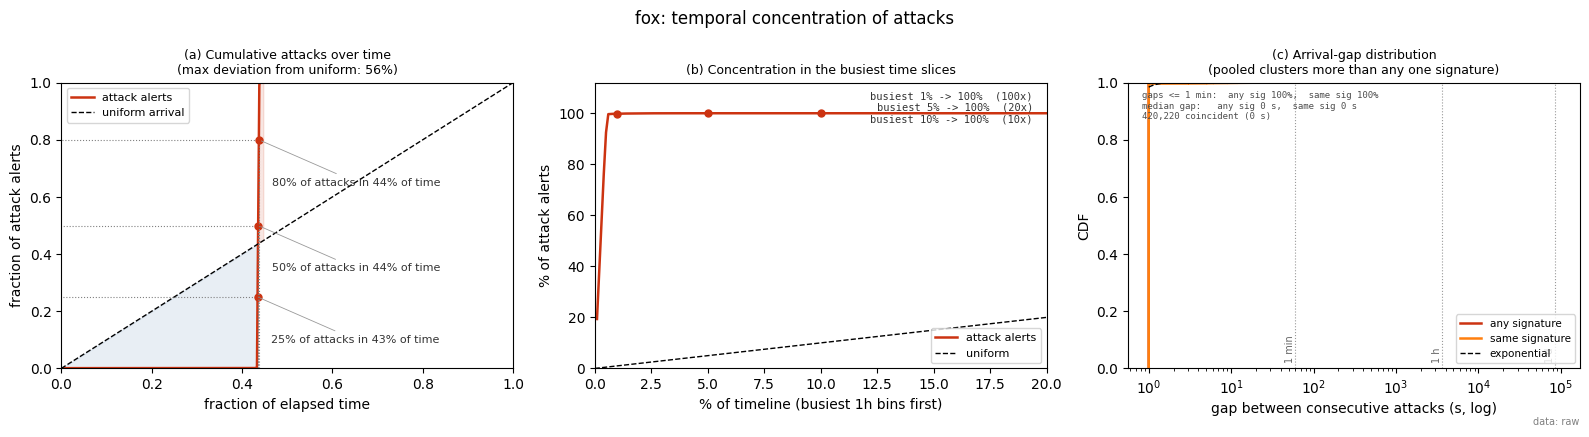

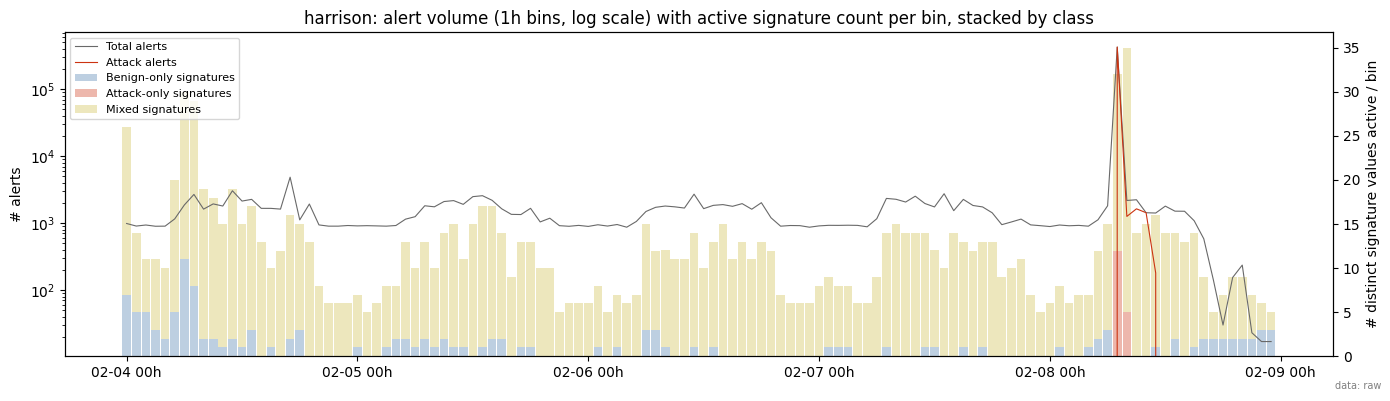

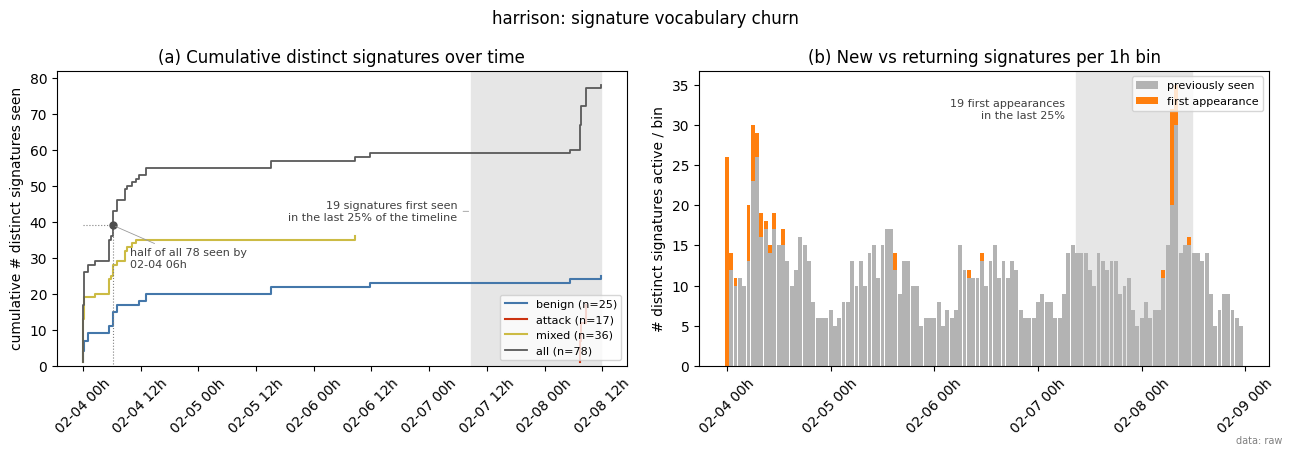

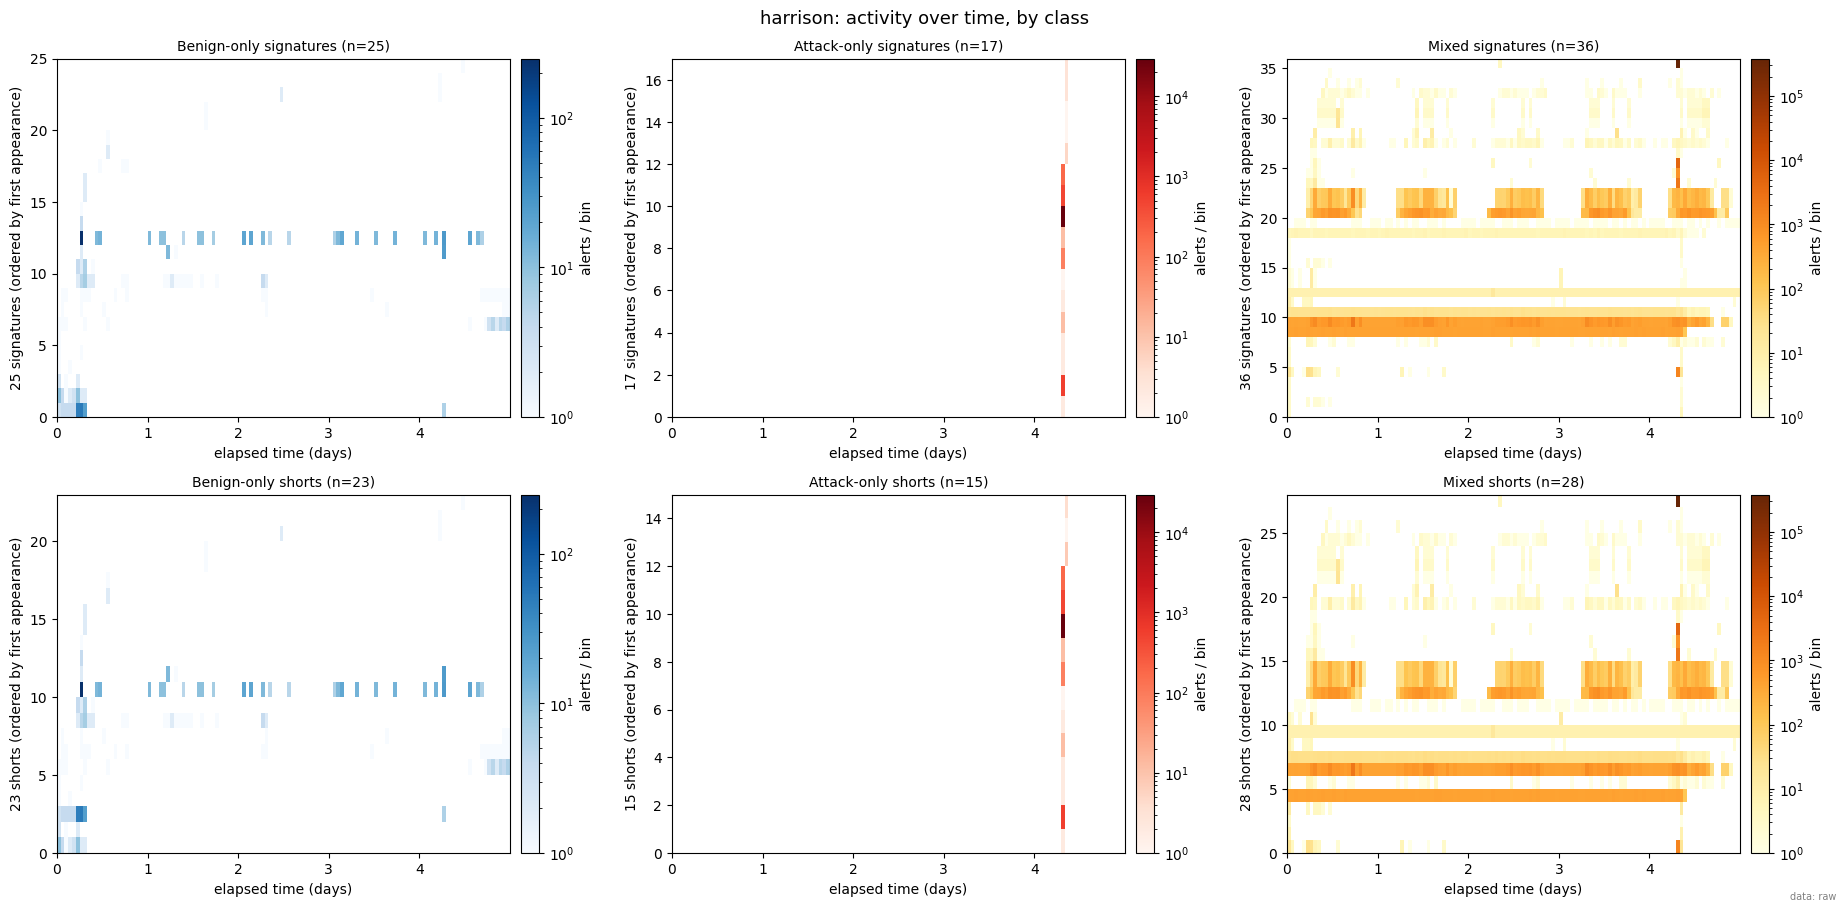

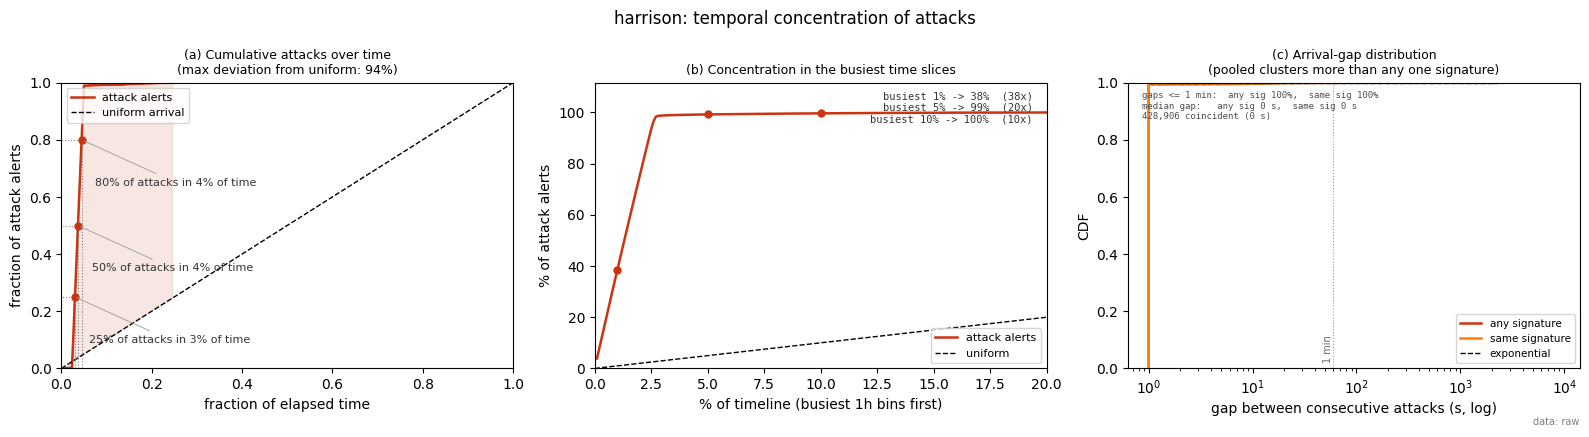

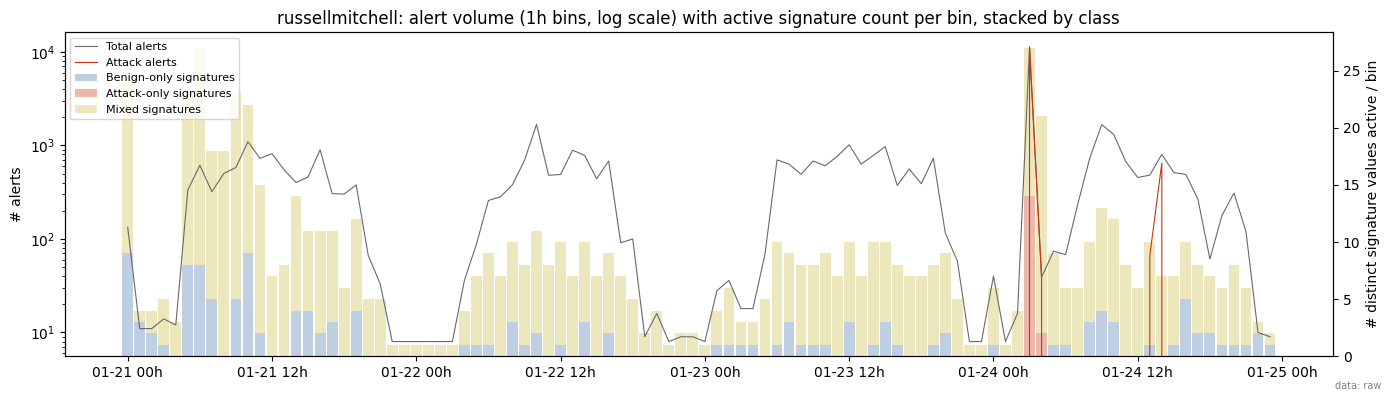

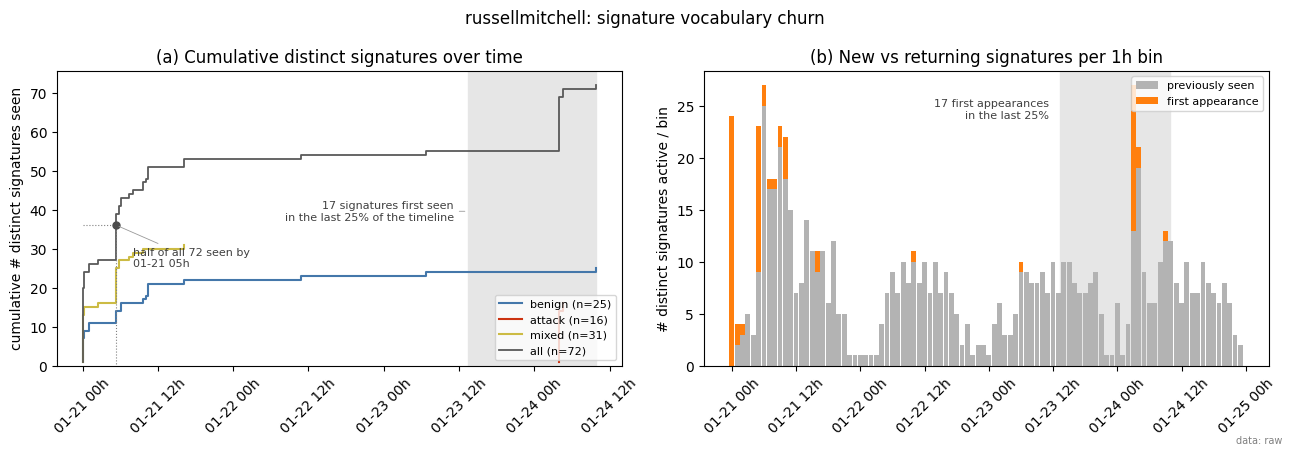

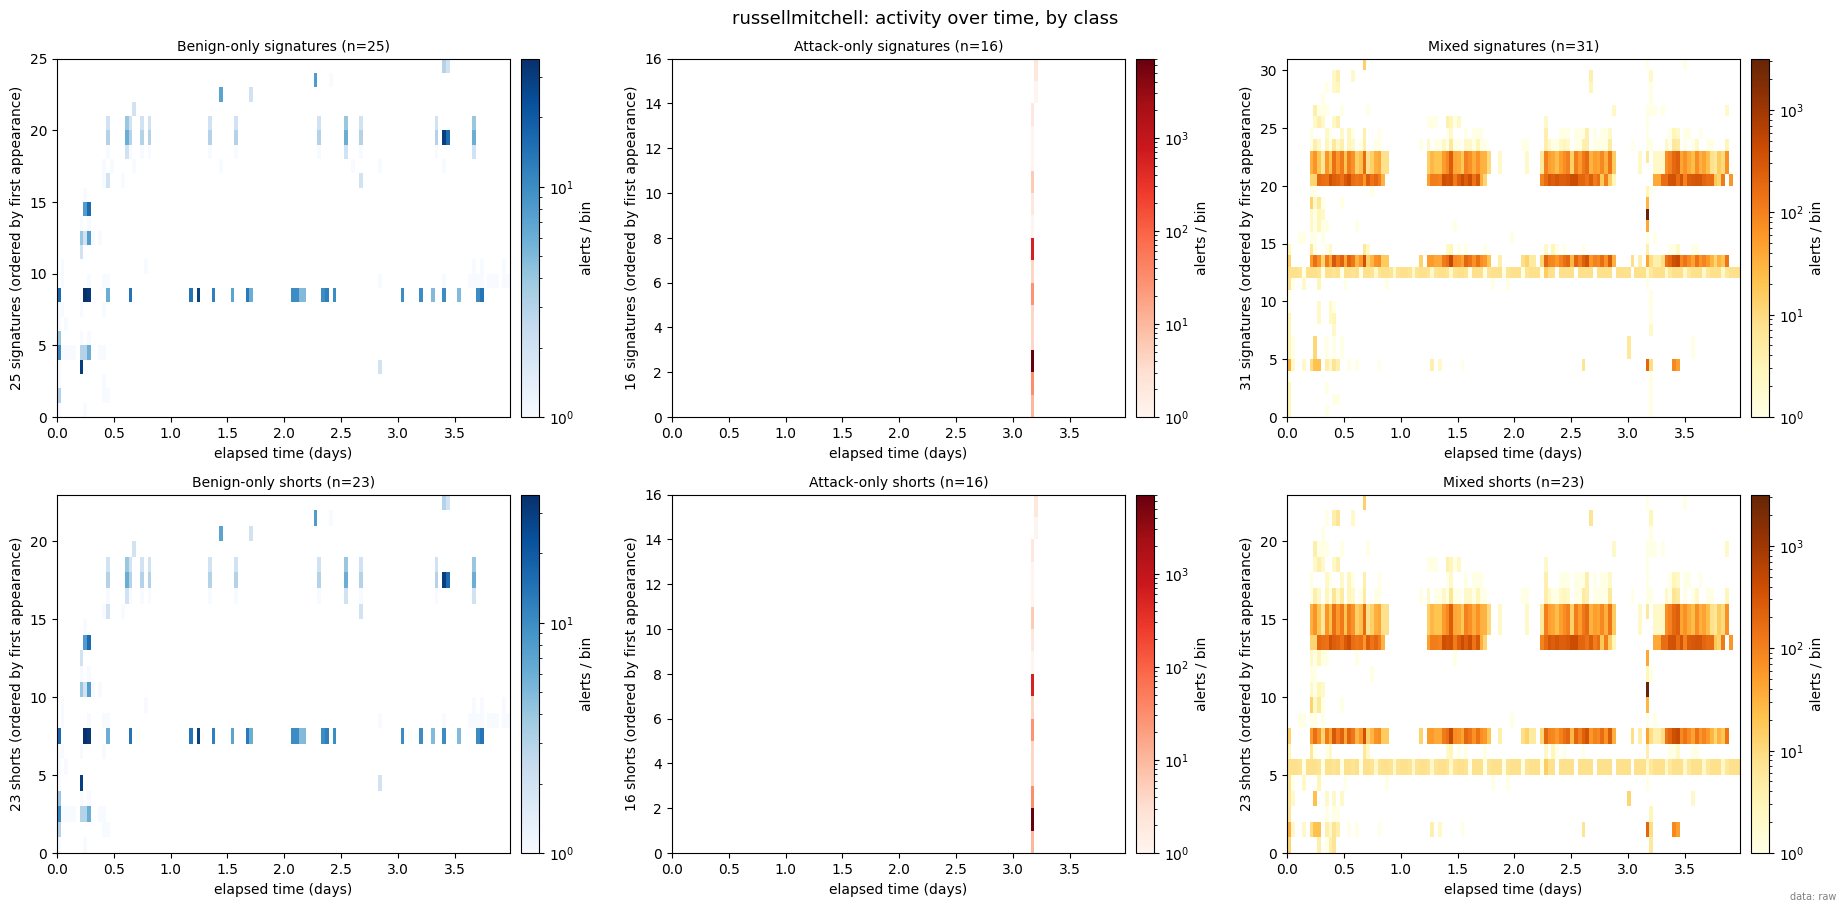

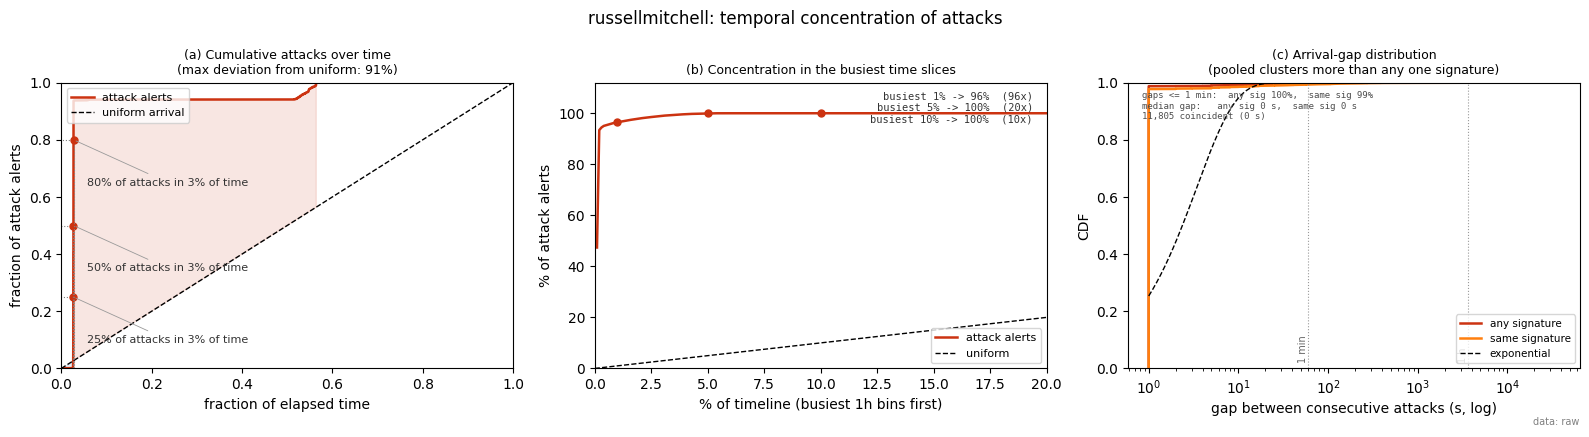

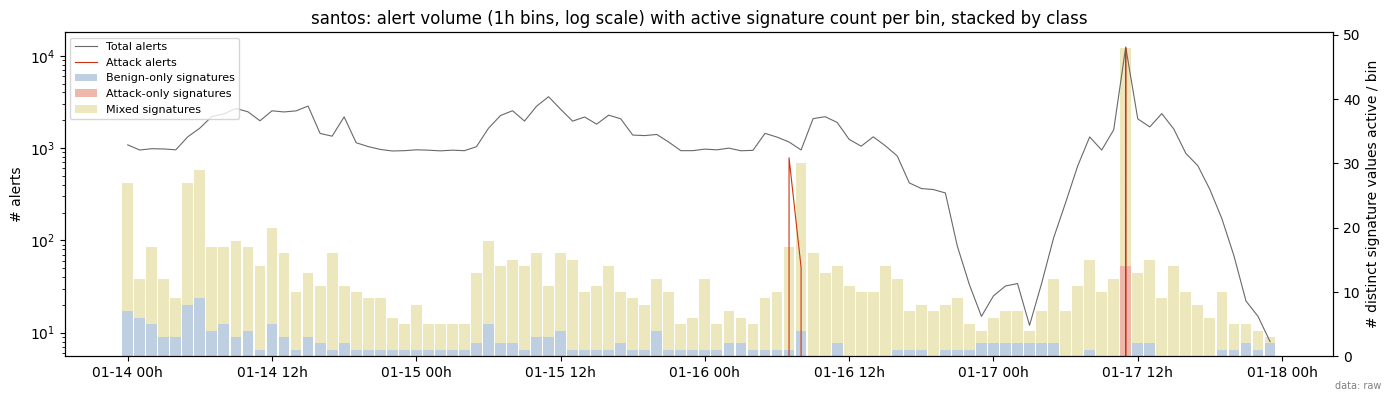

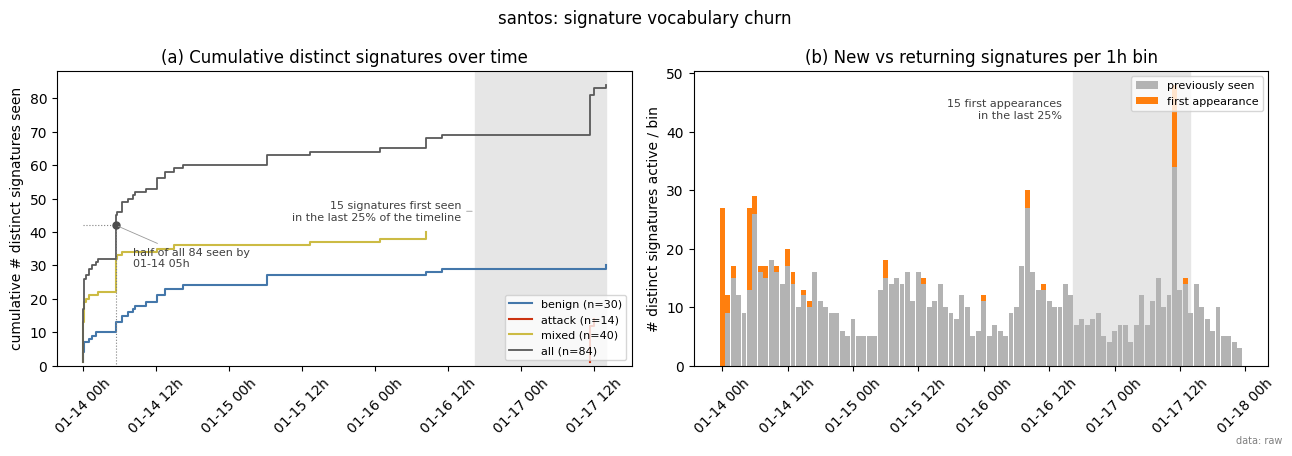

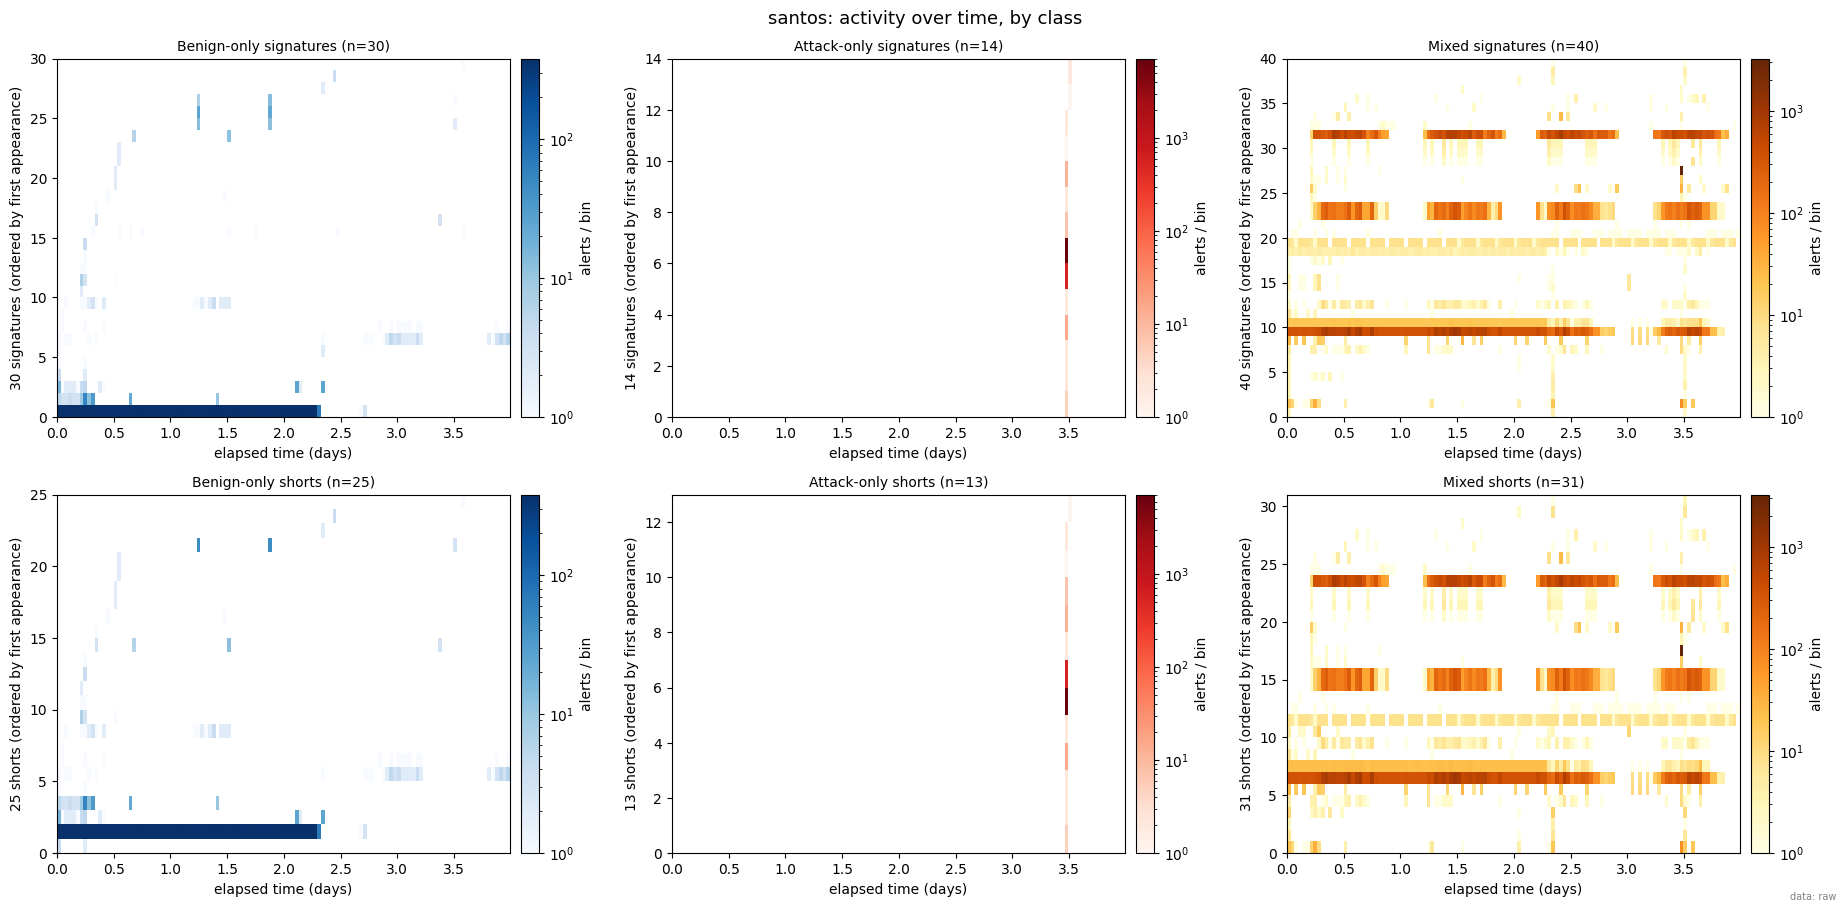

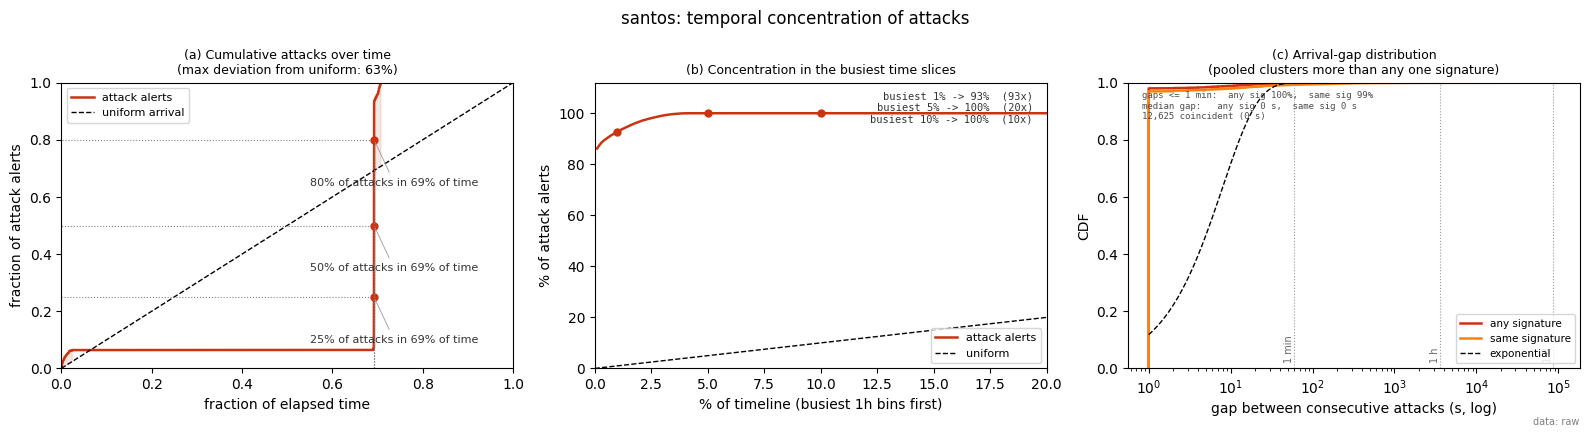

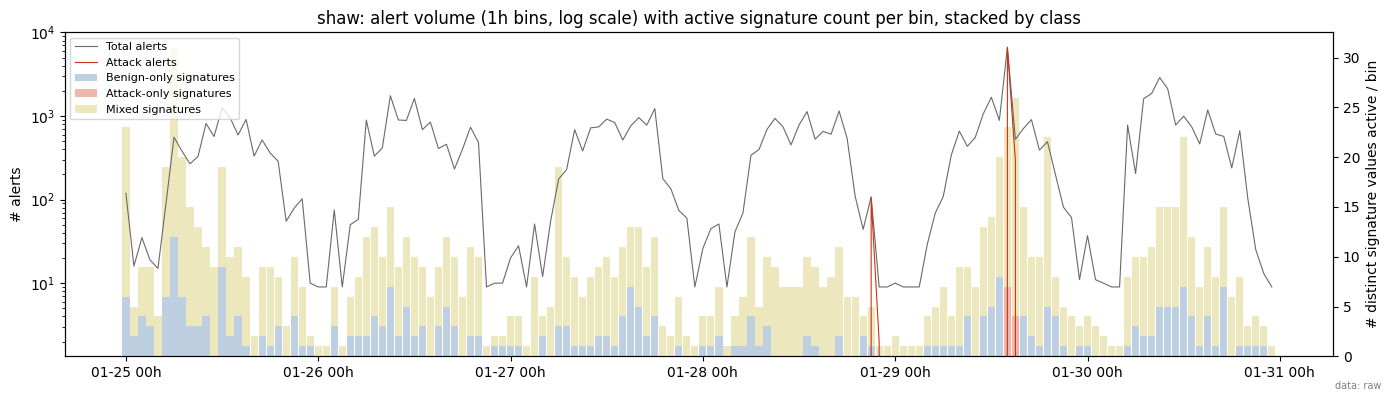

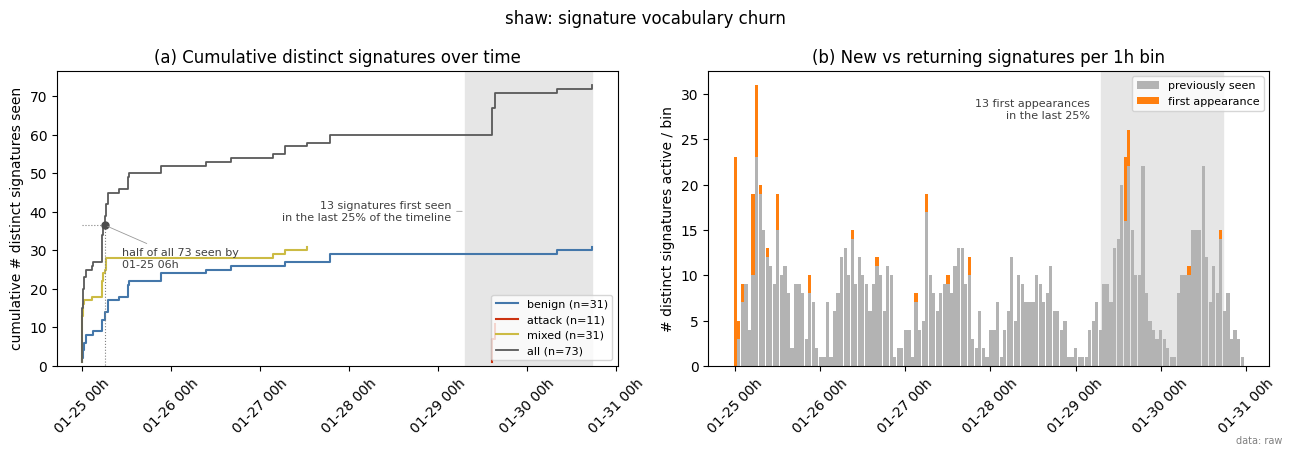

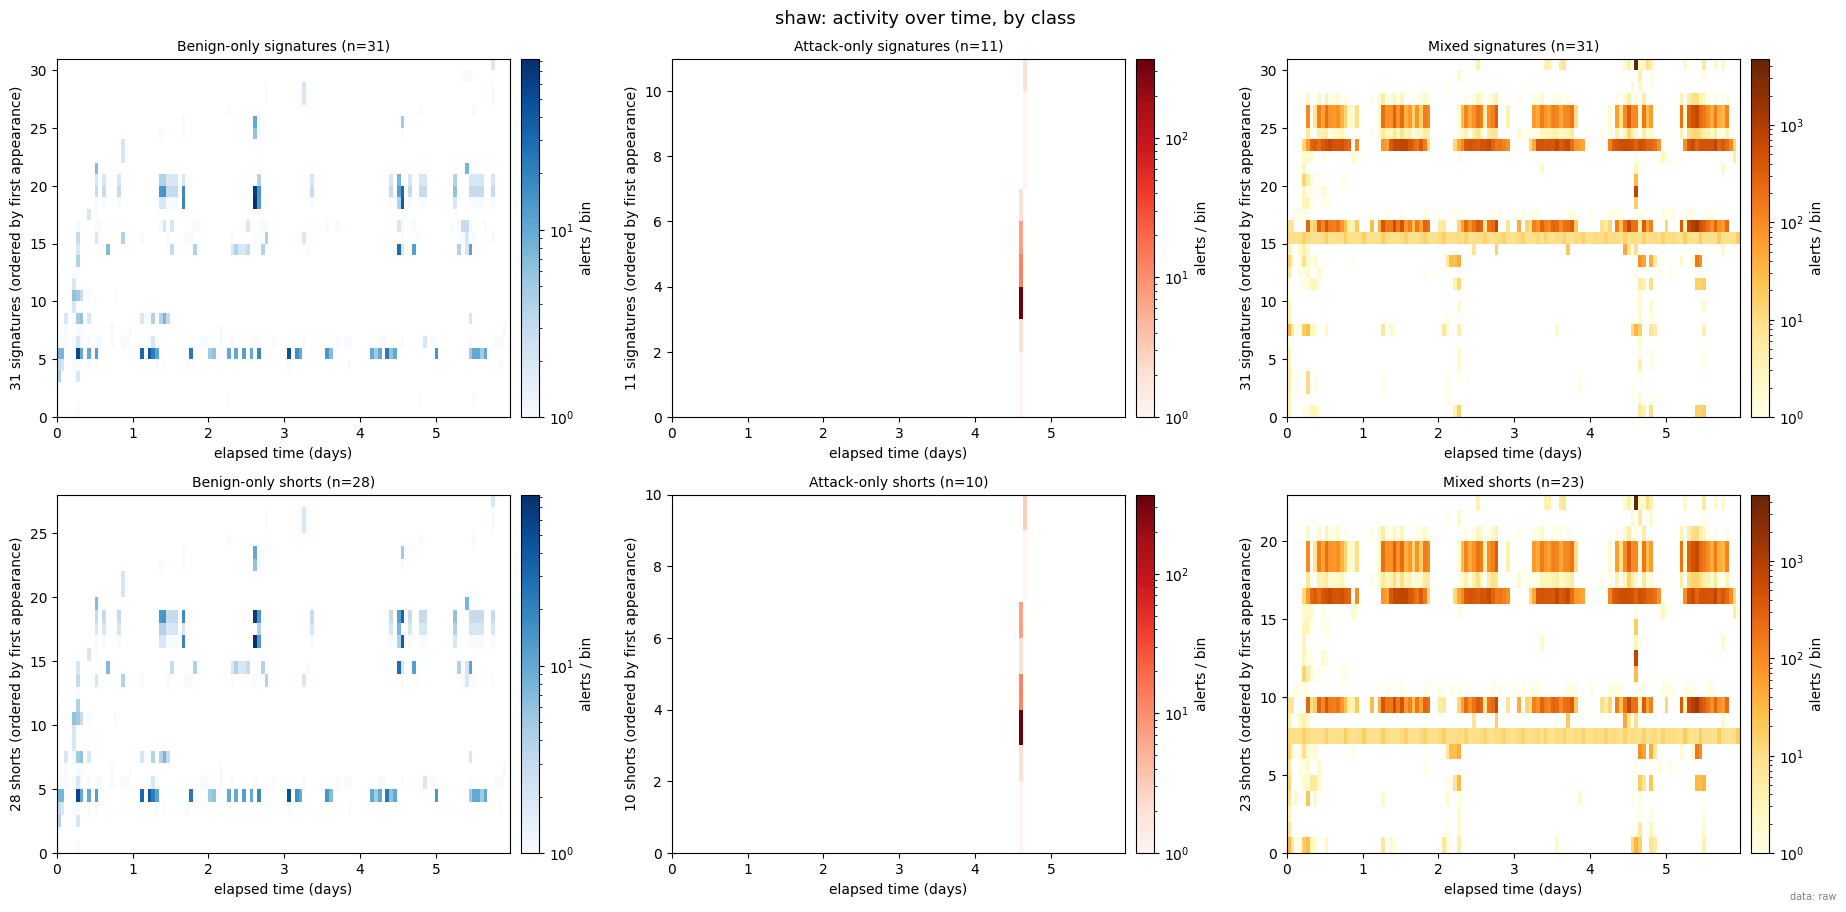

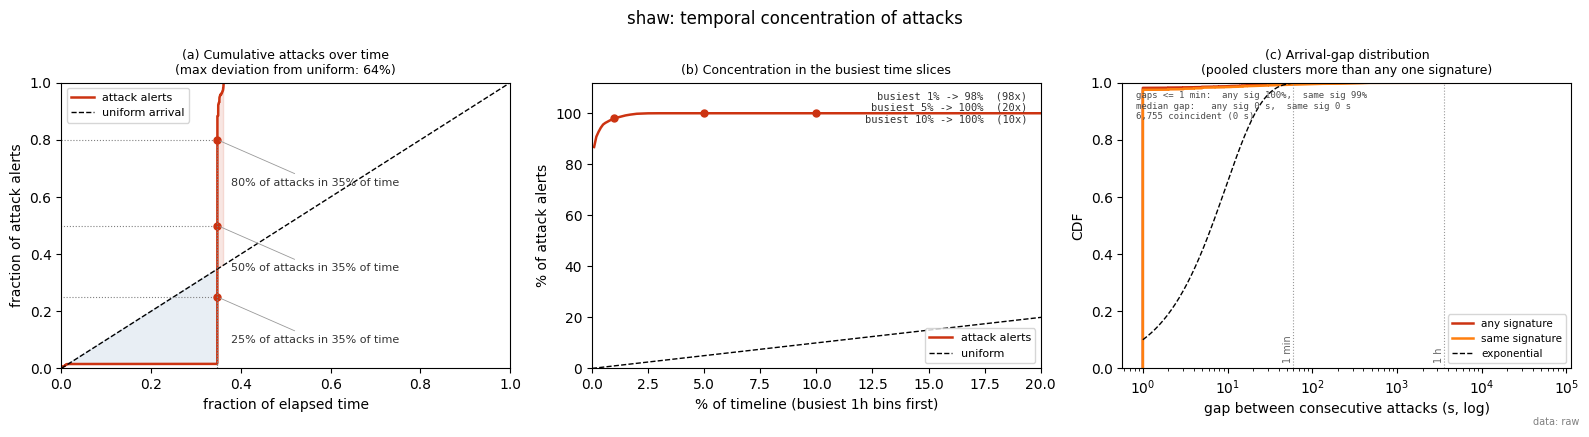

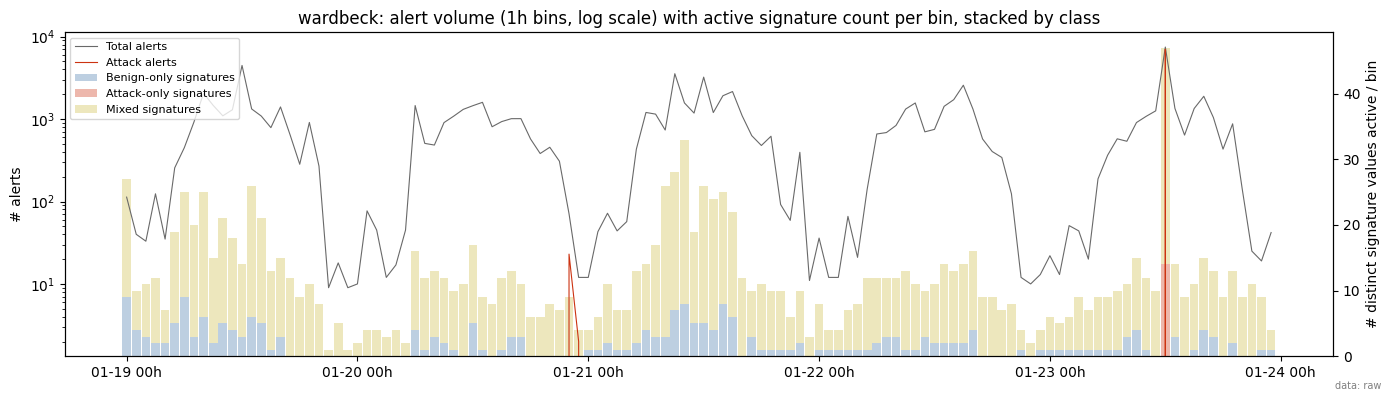

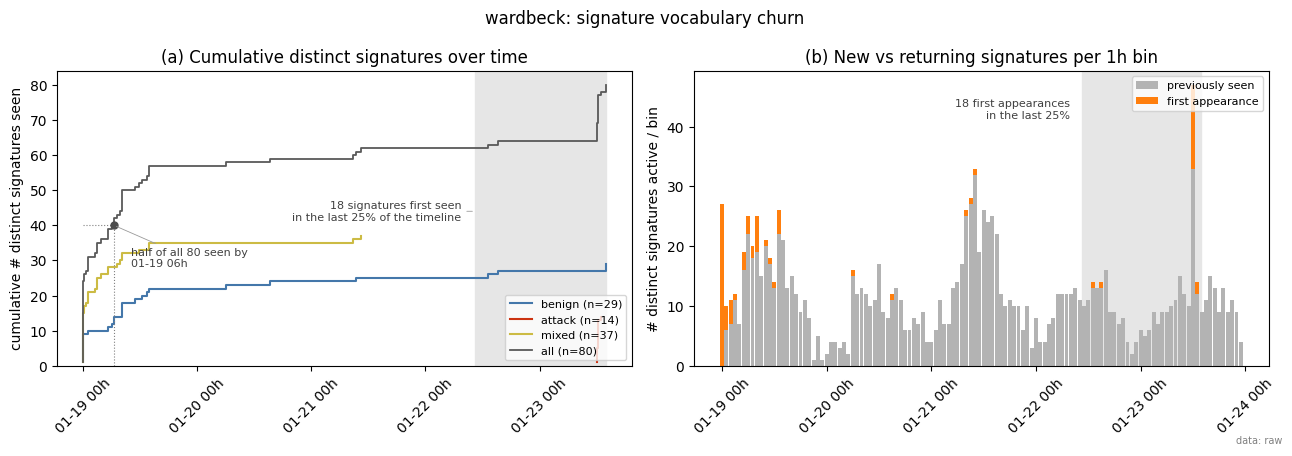

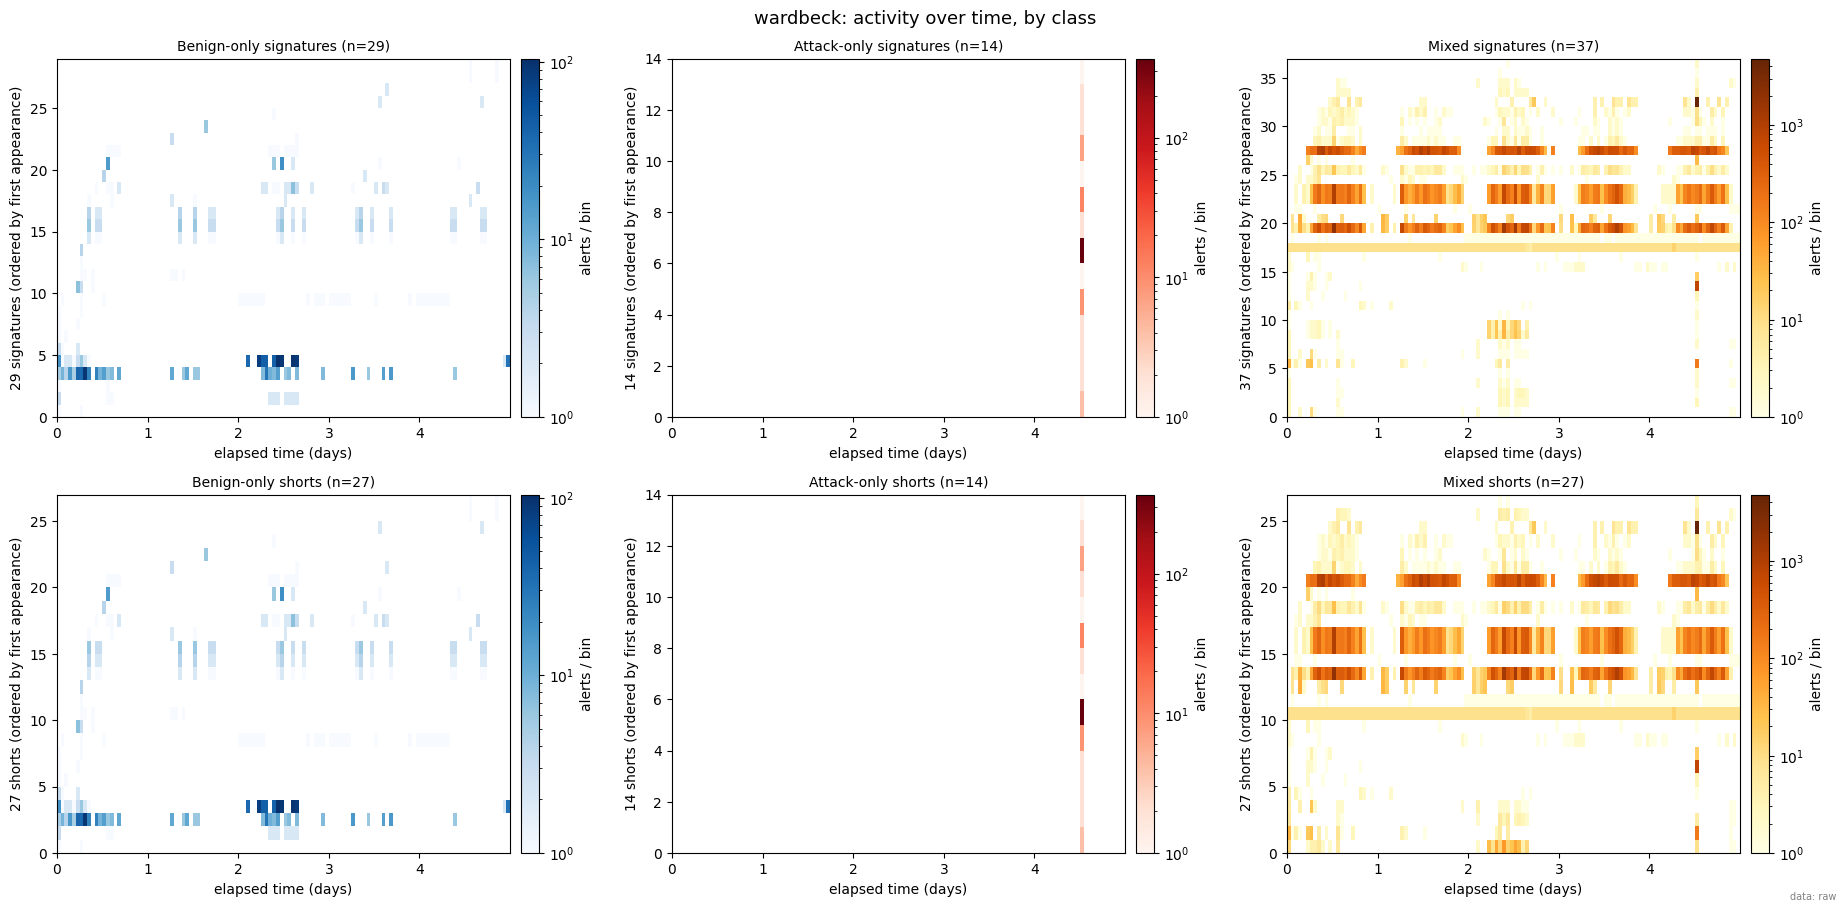

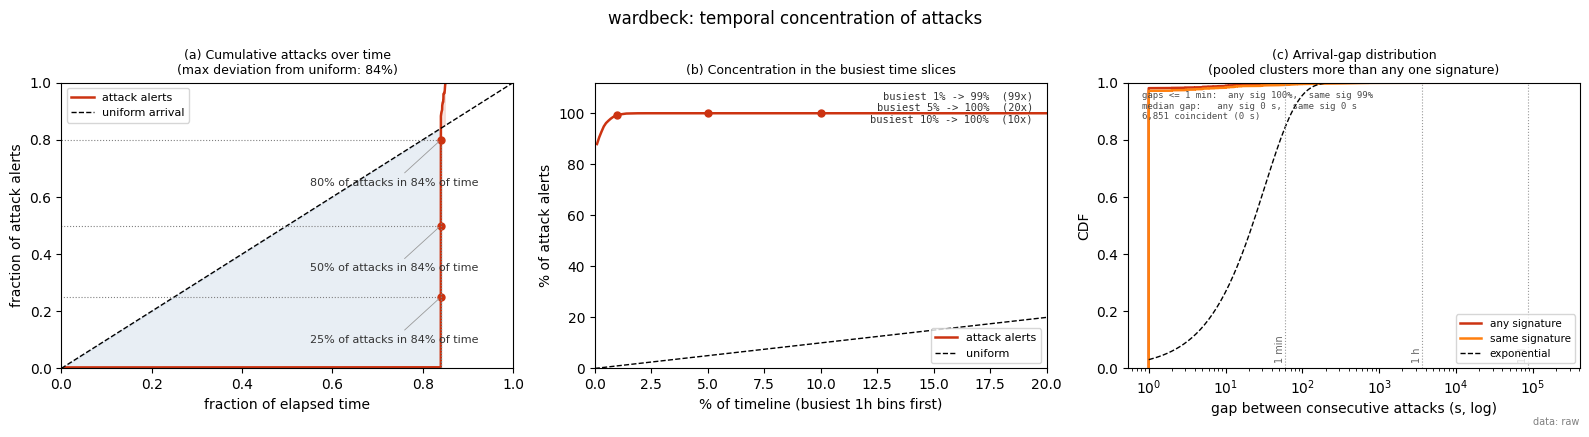

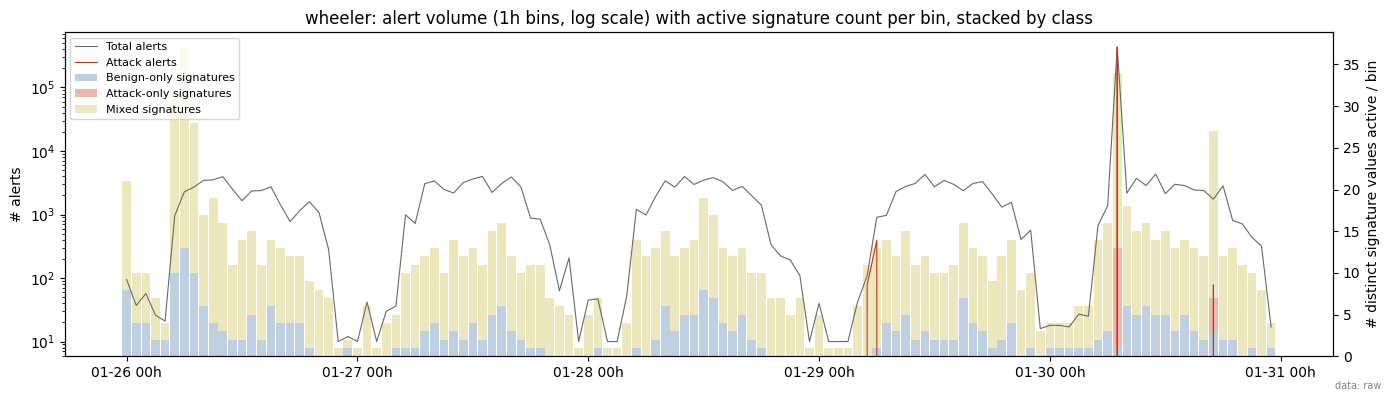

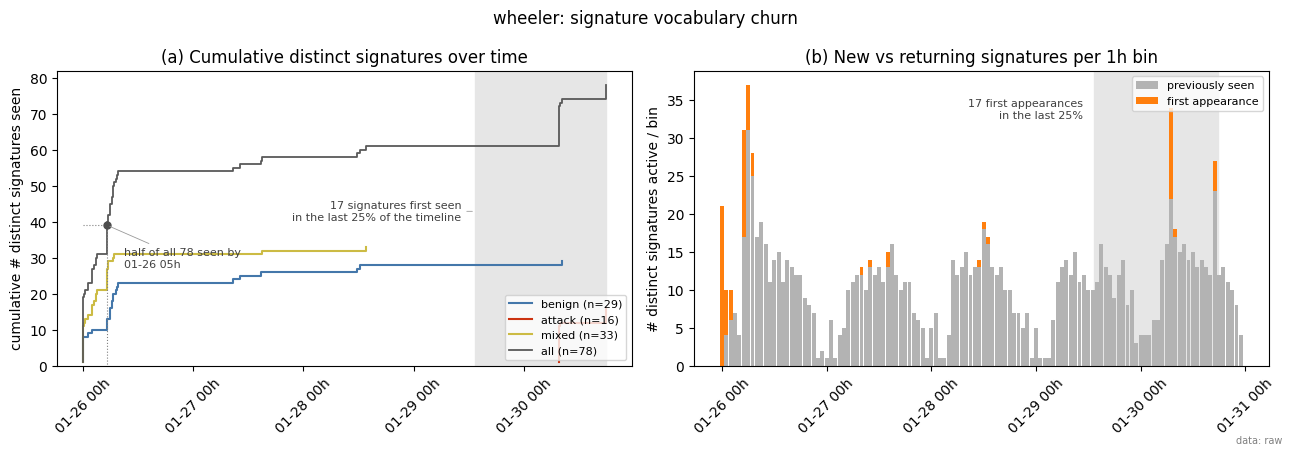

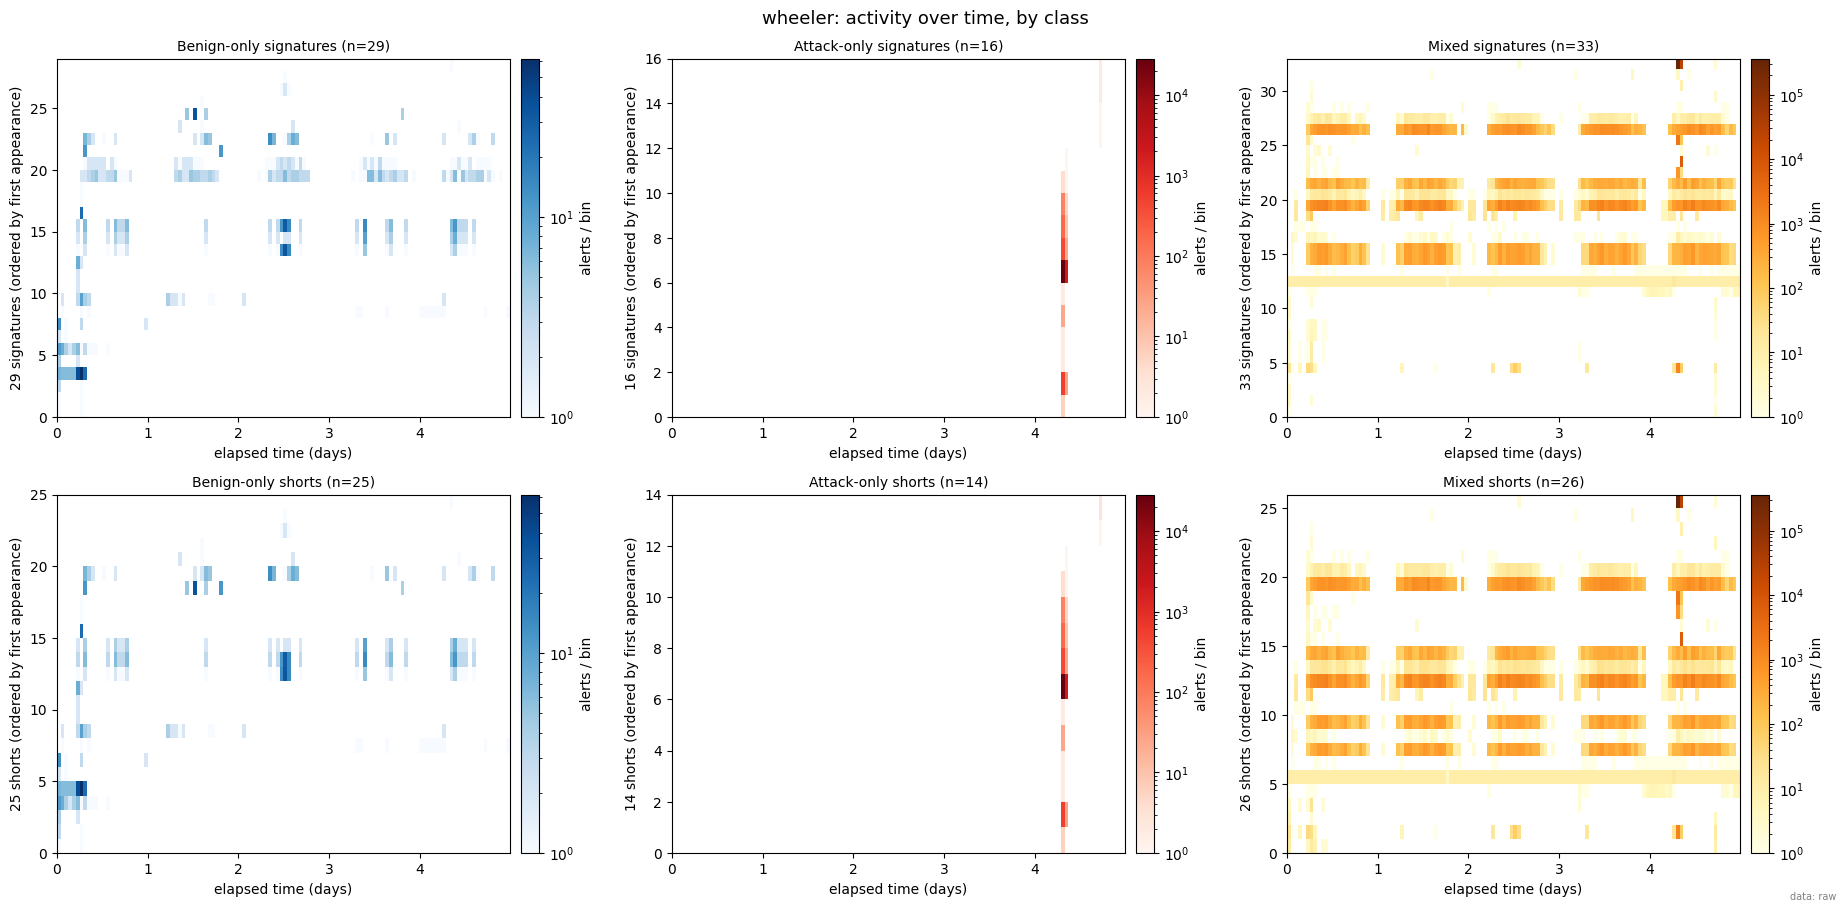

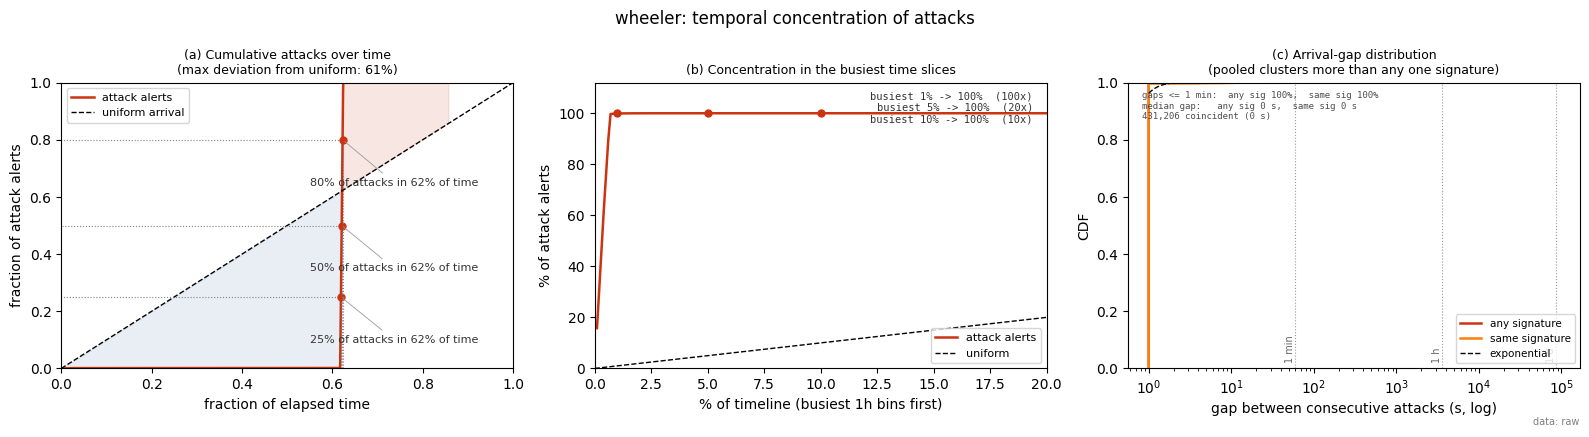

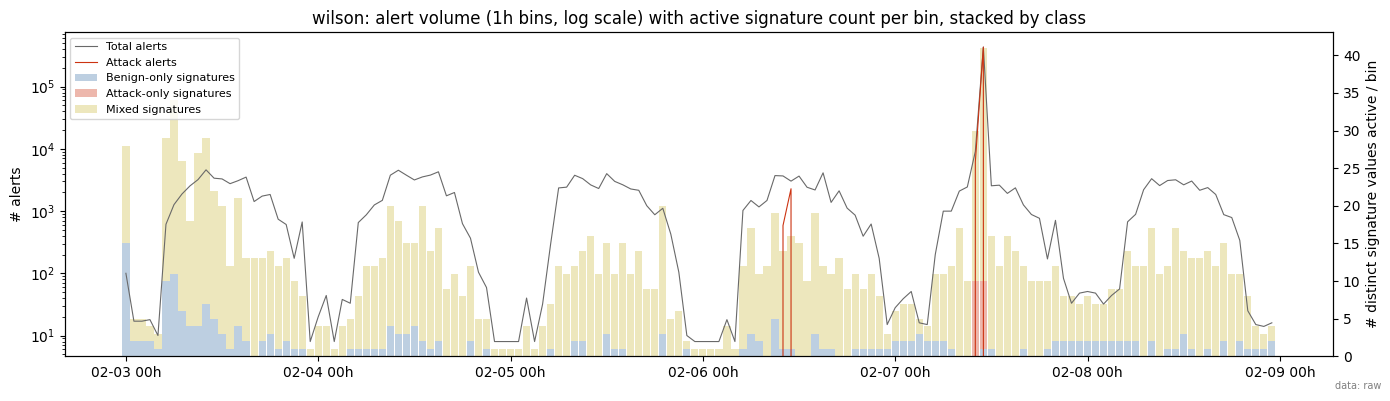

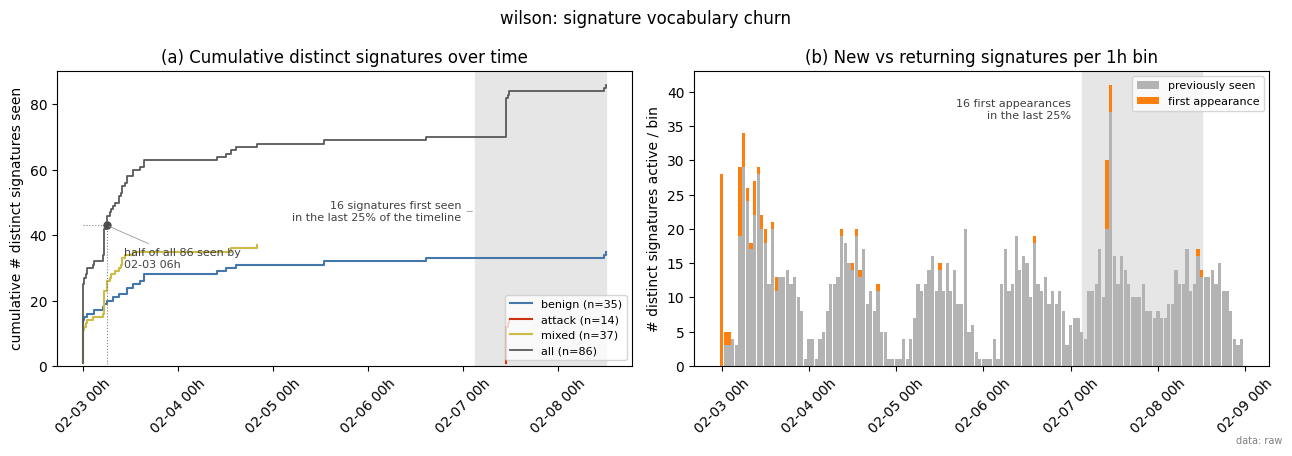

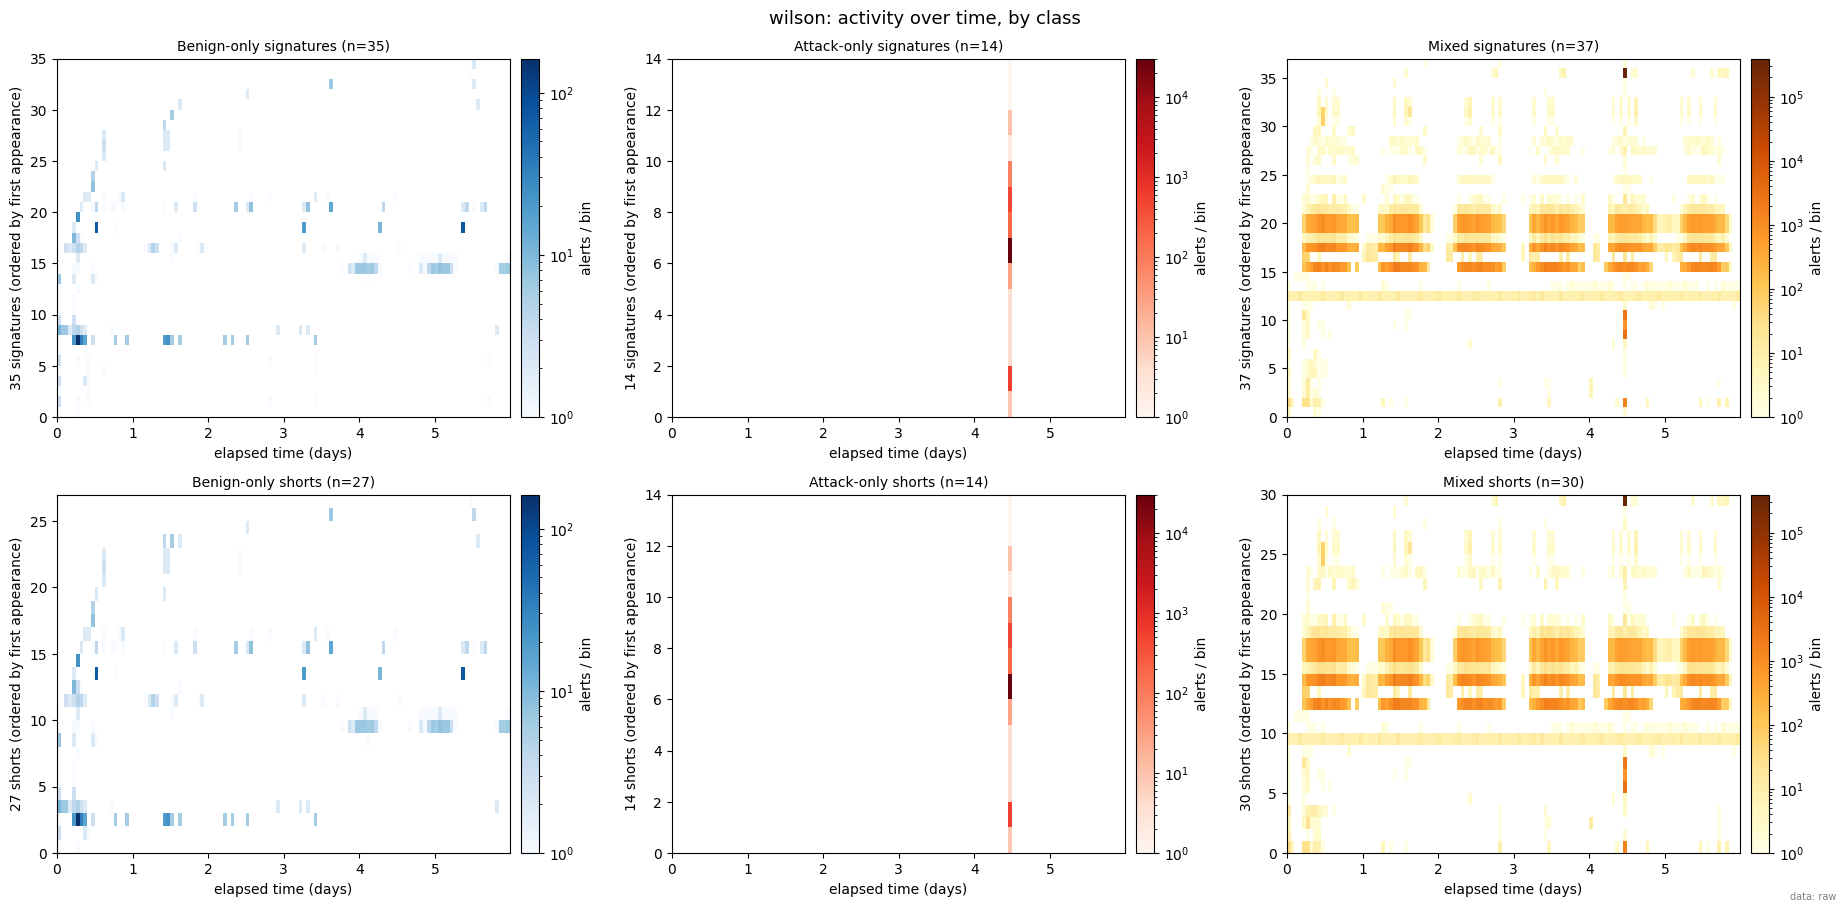

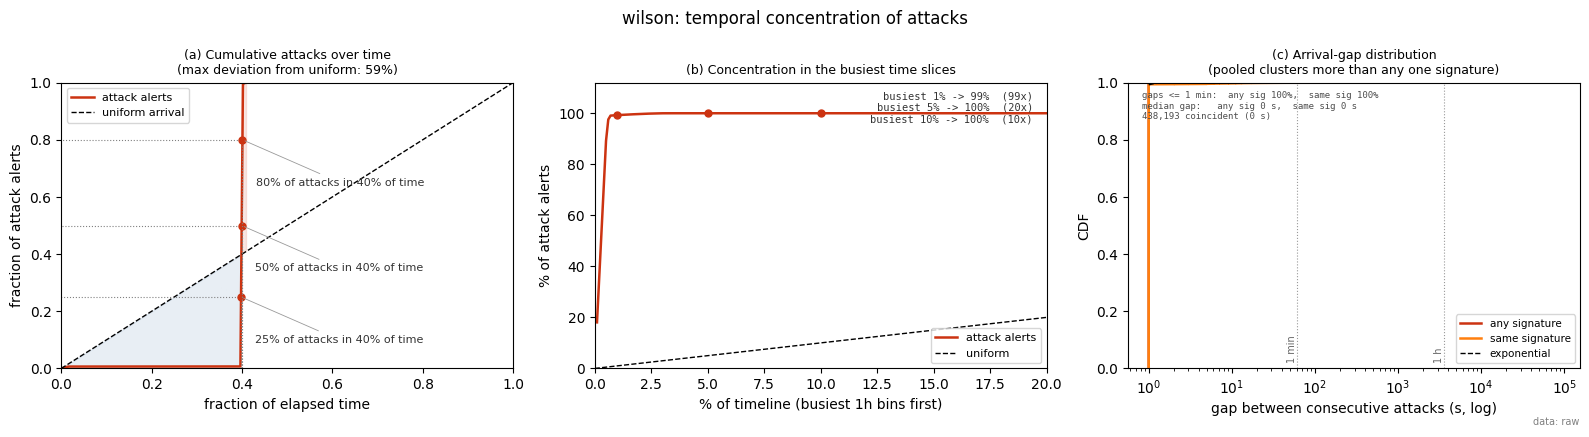

In [5]:
overview_csvs_dir = run_dir / 'overview_csvs'
for scenario in scenarios:
    scenario_df = all_df[all_df['scenario'] == scenario].copy()
    de.run_signature_behaviour_eda(
        scenario_df,
        scenario,
        out_path=run_dir / scenario,
        summary_path=summary_dir,
        overview_dir=overview_csvs_dir,
        bin_freq='1h',
    )

## Phase 1c: temporal concentration of attacks, cross-scenario

Combines Phase 1b's per-scenario `plot_attack_temporal_concentration` into one 3-panel figure with one line per scenario, so scenarios can be compared directly instead of eyeballed across 8 separate figures. Panels (b) and (c) use log axes (and (c) a survival function rather than a CDF) -- with 8 scenarios overlapping, linear axes collapse almost everything onto one curve near the origin since every scenario saturates within the first 1-2% of its timeline and has a near-zero median attack gap; log/survival views spread out the region where scenarios actually differ. In-plot annotations are dropped (8 overlapping scenario labels would be unreadable) -- `compute_attack_temporal_concentration_summary` gives the same numbers as a table instead.

,scenario,n_attack,max_deviation_from_uniform_pct,busiest_1pct_share_pct,busiest_5pct_share_pct,busiest_10pct_share_pct,pct_gaps_over_1s,pct_gaps_over_1min,p99_gap_s
0,fox,421653,56.0,99.8,100.0,100.0,0.05,0.006,1.0
1,harrison,431492,93.9,38.5,99.2,99.7,0.18,0.004,1.0
2,russellmitchell,12015,91.0,96.5,99.9,100.0,1.25,0.175,5.0
3,santos,13004,62.6,92.8,100.0,100.0,2.01,0.154,12.0
4,shaw,6935,63.8,98.0,100.0,100.0,1.83,0.404,15.0
5,wardbeck,7040,83.6,99.2,100.0,100.0,1.93,0.213,11.0
6,wheeler,432334,61.5,99.9,100.0,100.0,0.02,0.003,1.0
7,wilson,440108,59.5,99.3,100.0,100.0,0.12,0.000,1.0


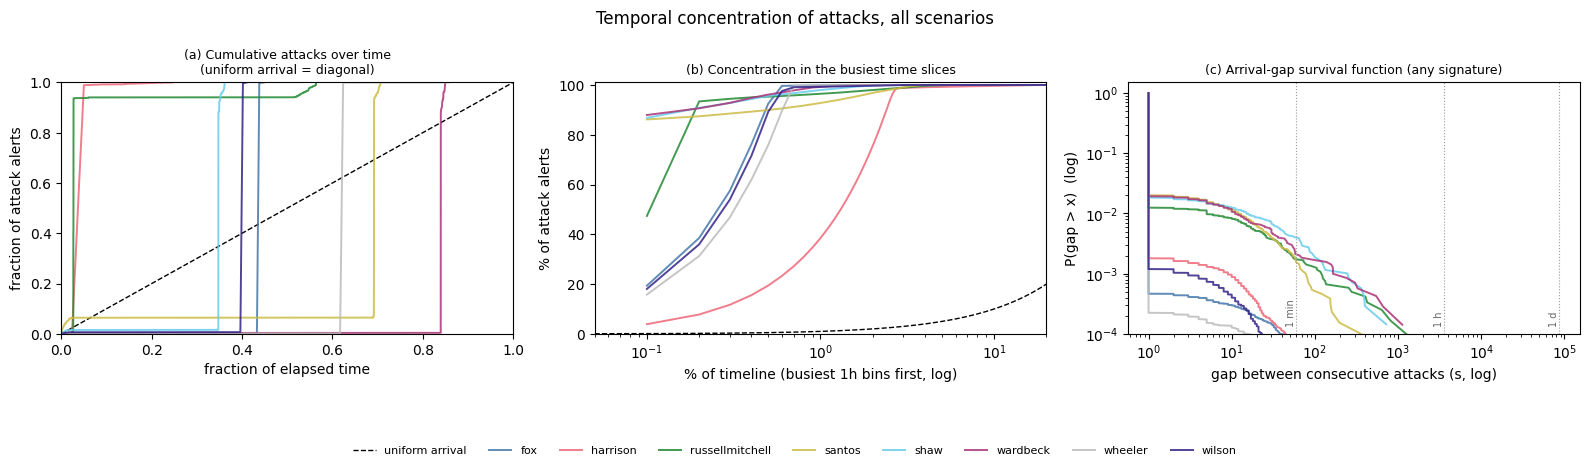

In [6]:
from thesis.visualization.eda import plot_attack_temporal_concentration_multi

concentration_summary = de.compute_attack_temporal_concentration_summary(all_df, scenarios=scenarios)
concentration_summary.to_csv(run_dir / 'attack_temporal_concentration_summary.csv', index=False)

fig, _ = plot_attack_temporal_concentration_multi(
    all_df, scenarios=scenarios,
    out_path=str(run_dir / 'plots' / 'attack_temporal_concentration_multi.png'),
)
concentration_summary

## Phase 1d: signature behaviour, cross-scenario table

One row per scenario, the numbers behind the "signature behaviour" EDA question -- (i) volume concentration, (ii) class purity (benign-only / attack-only / mixed), (iii) persistence across the collection window (by class), (iv) host spread. No new plots -- this is the numeric table every claim in the signature-behaviour write-up should be traceable to.

In [7]:
signature_behaviour_summary = de.compute_signature_behaviour_summary_multi(all_df, scenarios=scenarios)
signature_behaviour_summary.to_csv(run_dir / 'signature_behaviour_summary_multi.csv', index=False)
signature_behaviour_summary

,scenario,n_signatures,top5_share_pct,top10_share_pct,n_sigs_for_90pct_volume,n_benign_only,n_attack_only,n_mixed,pct_mixed,median_days_active_frac_benign,median_days_active_frac_attack,median_days_active_frac_mixed,n_active_every_day_benign,n_active_every_day_attack,n_active_every_day_mixed,n_hosts,pct_sigs_exclusive_1_host,median_hosts_per_sig
0,fox,77,95.8,99.1,3,30,11,36,46.8,0.20,0.20,1.00,3,0,19,13,26.0,2.0
1,harrison,78,93.8,98.8,5,25,17,36,46.2,0.20,0.20,0.80,1,0,17,11,35.9,2.0
2,russellmitchell,72,86.3,97.9,6,25,16,31,43.1,0.25,0.25,0.75,5,0,10,11,25.0,2.0
3,santos,84,88.0,98.1,6,30,14,40,47.6,0.25,0.25,0.75,1,0,17,11,32.1,2.0
4,shaw,73,92.2,97.2,5,31,11,31,42.5,0.50,0.17,0.67,8,0,9,12,38.4,2.0
5,wardbeck,80,93.4,97.2,5,29,14,37,46.2,0.40,0.20,0.80,4,0,17,12,32.5,2.0
6,wheeler,78,90.1,98.9,5,29,16,33,42.3,0.20,0.20,0.60,6,0,13,13,32.1,2.0
7,wilson,86,92.8,98.9,5,35,14,37,43.0,0.33,0.17,0.83,1,0,18,12,20.9,2.0


## Phase 2: overview plots

Attack-type heatmap, plus per-scenario alert volume timeline and attack-phase zoom (raw alerts).


[plots] Saving to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/run_eda/ait-ads/run_20260905_160546_raw/plots
  Saving alert volume (concatenated timeline)... done
  Saving alert volume (attack phase zoom)... done
  Saving attack type heatmap... done


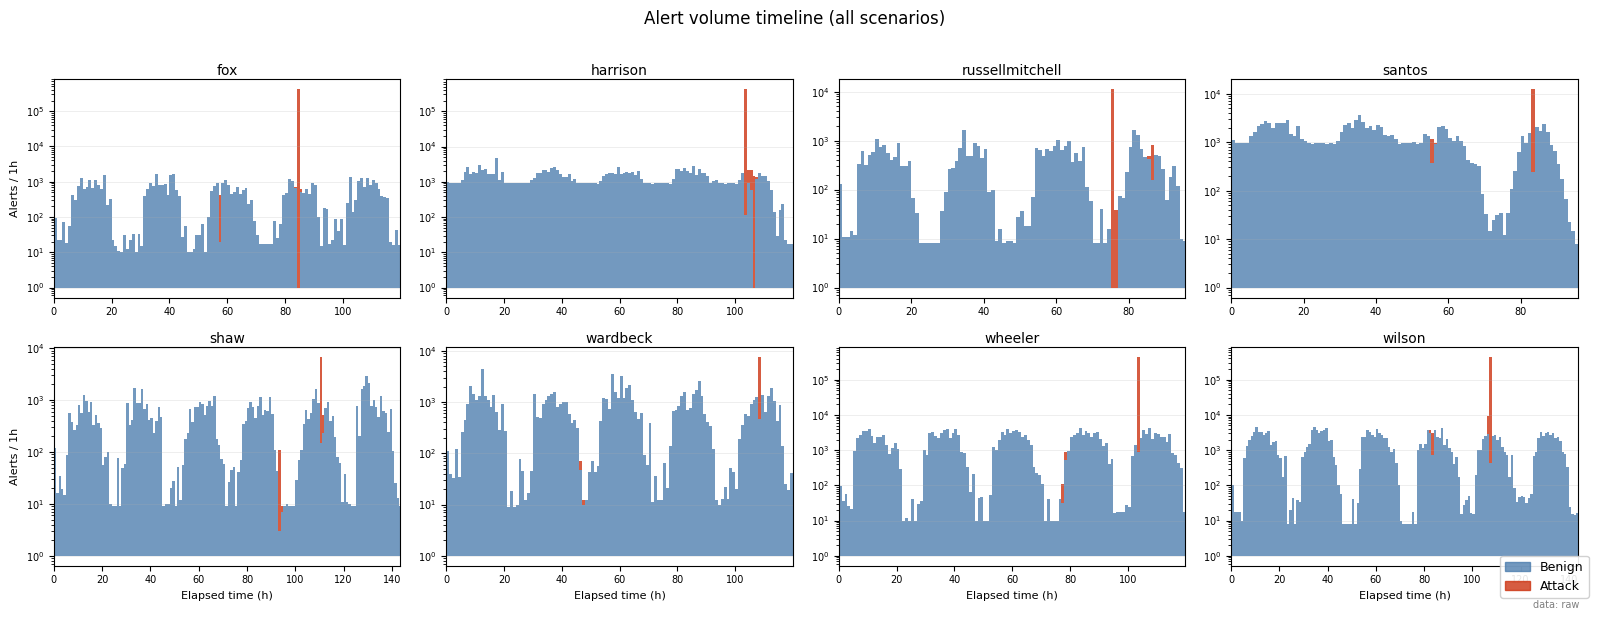

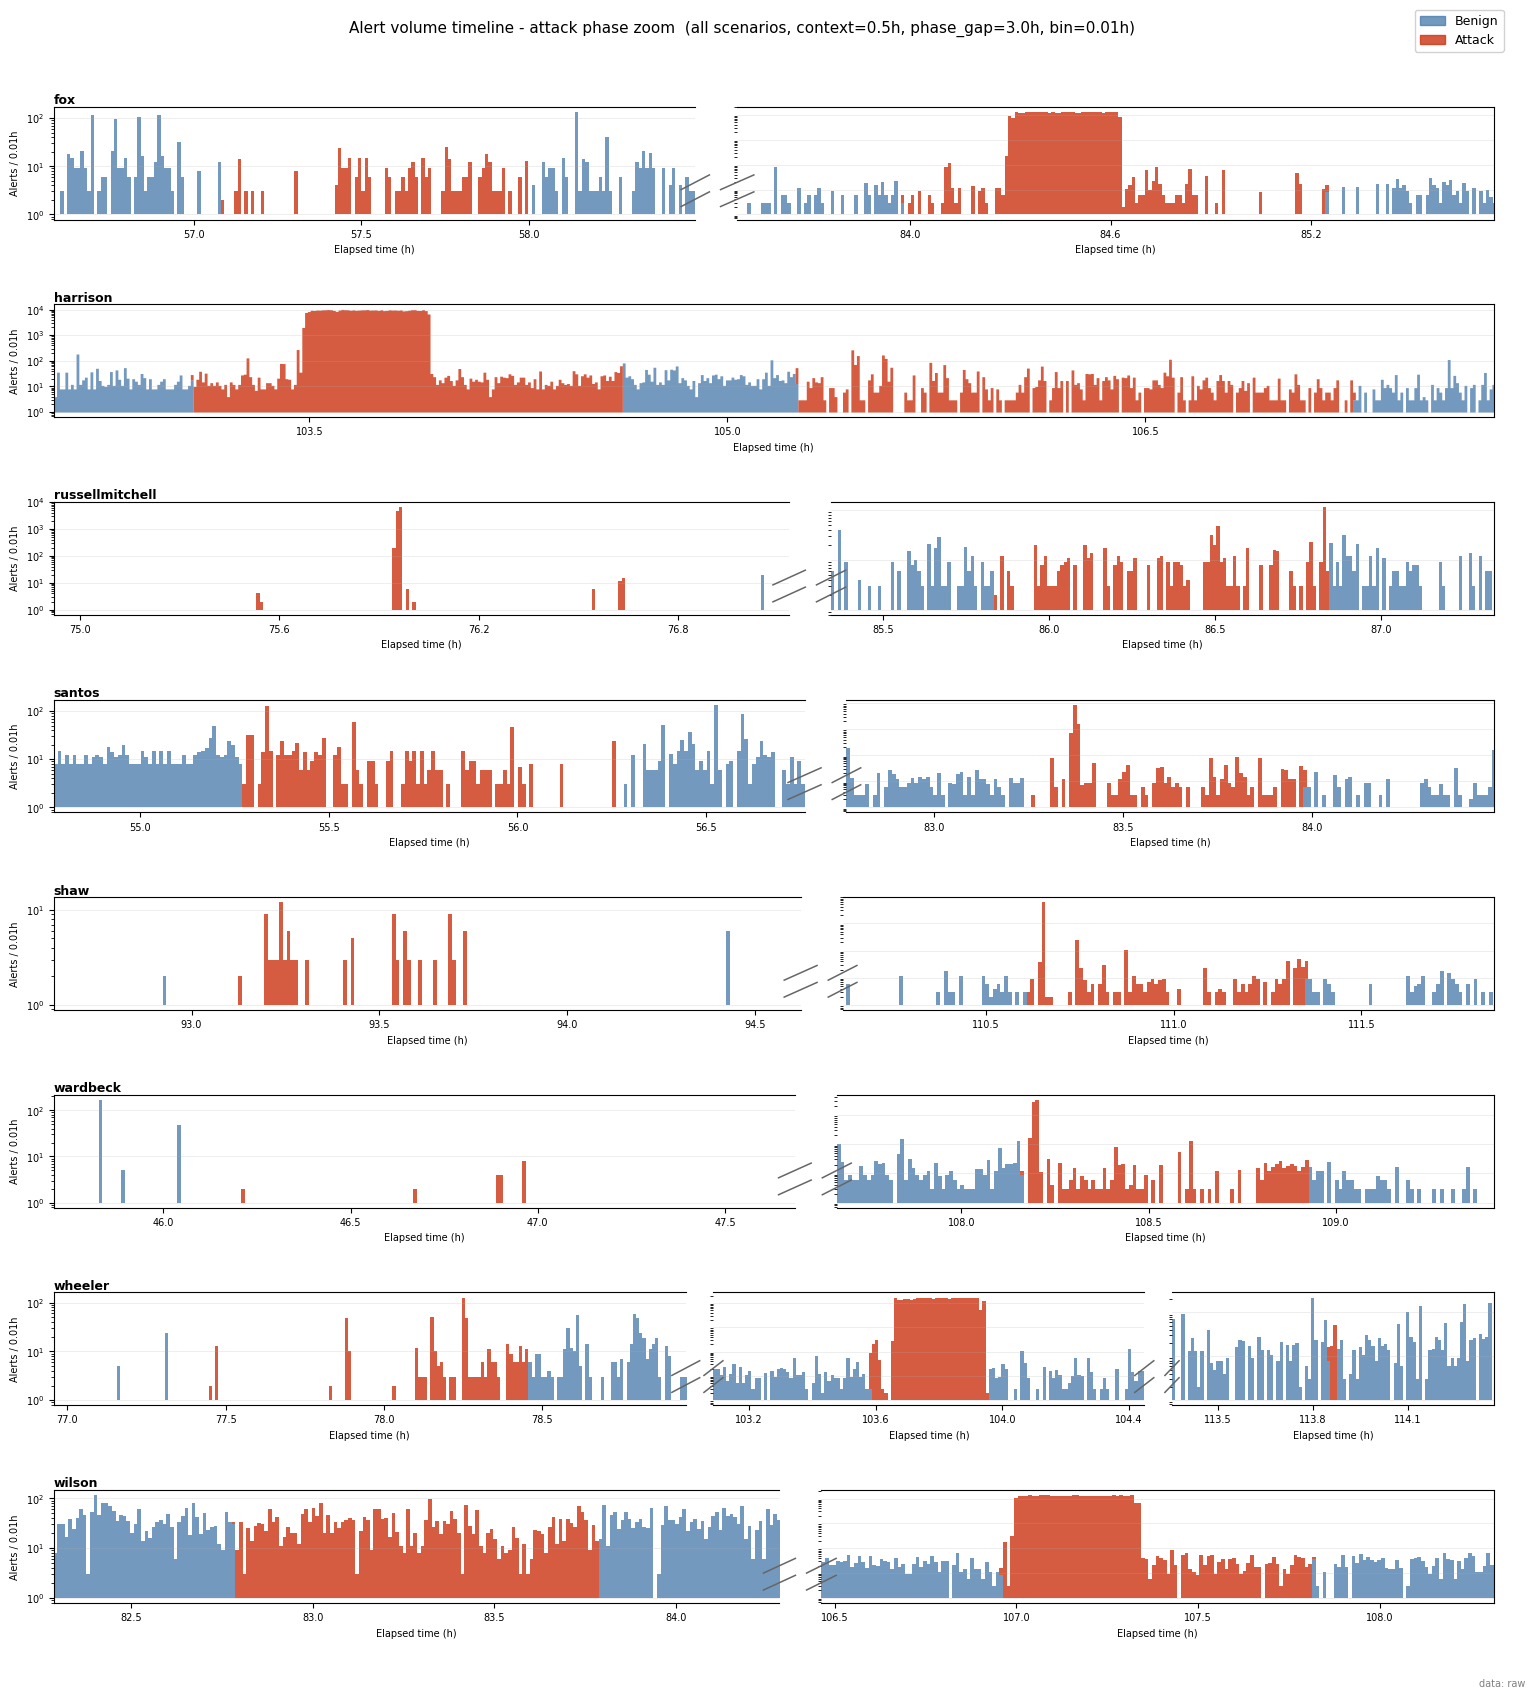

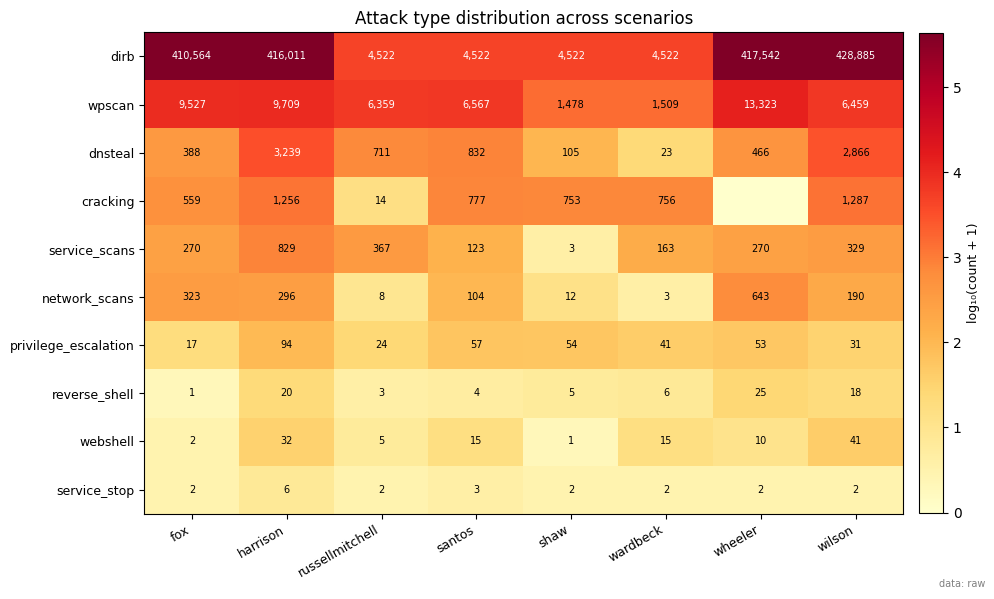

In [10]:
plots = de.build_overview_plots(scenarios, all_df, dataset=DATASET)
de.save_overview_plots(plots, run_dir / 'plots', de.data_label(), close=False)

## Per-host analysis (AIT-ADS only)

Per-host alert-type vocabulary, burst/stream profile, and cross-host overlap -- answers whether per-host grouping keeps alert streams semantically pure. Reads from `artifacts/processed-data/<scenario>/alerts.json` (the tokenised/ingested alerts, not the raw CSV).


[fox] Loading alerts...
  473,104 alerts, 13 hosts, 66 alert types
  Plotting heatmap...
  Plotting timelines...
  Plotting inter-arrival CDFs...
  Plotting burst profile...
  Plotting type overlap...
  Plotting exclusivity...
  → /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/run_eda_host/run_20260905_160546/fox

[harrison] Loading alerts...
  593,948 alerts, 11 hosts, 66 alert types
  Plotting heatmap...
  Plotting timelines...
  Plotting inter-arrival CDFs...
  Plotting burst profile...
  Plotting type overlap...
  Plotting exclusivity...
  → /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/run_eda_host/run_20260905_160546/harrison

[russellmitchell] Loading alerts...
  45,544 alerts, 11 hosts, 62 alert types
  Plotting heatmap...
  Plotting timelines...
  Plotting inter-arrival CDFs...
  Plotting burst profile...
  Plotting type overlap...
  Plotting exclusivity...
  → /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/exper

/Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/visualization/eda.py:1869: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=figsize)


  Plotting burst profile...
  Plotting type overlap...
  Plotting exclusivity...
  → /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/run_eda_host/run_20260905_160546/santos

[shaw] Loading alerts...
  70,782 alerts, 12 hosts, 61 alert types
  Plotting heatmap...
  Plotting timelines...
  Plotting inter-arrival CDFs...
  Plotting burst profile...
  Plotting type overlap...
  Plotting exclusivity...
  → /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/run_eda_host/run_20260905_160546/shaw

[wardbeck] Loading alerts...
  91,257 alerts, 12 hosts, 68 alert types
  Plotting heatmap...
  Plotting timelines...
  Plotting inter-arrival CDFs...
  Plotting burst profile...
  Plotting type overlap...
  Plotting exclusivity...
  → /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/run_eda_host/run_20260905_160546/wardbeck

[wheeler] Loading alerts...
  616,161 alerts, 13 hosts, 65 alert types
  Plotting heatmap...
  Plotting timeli

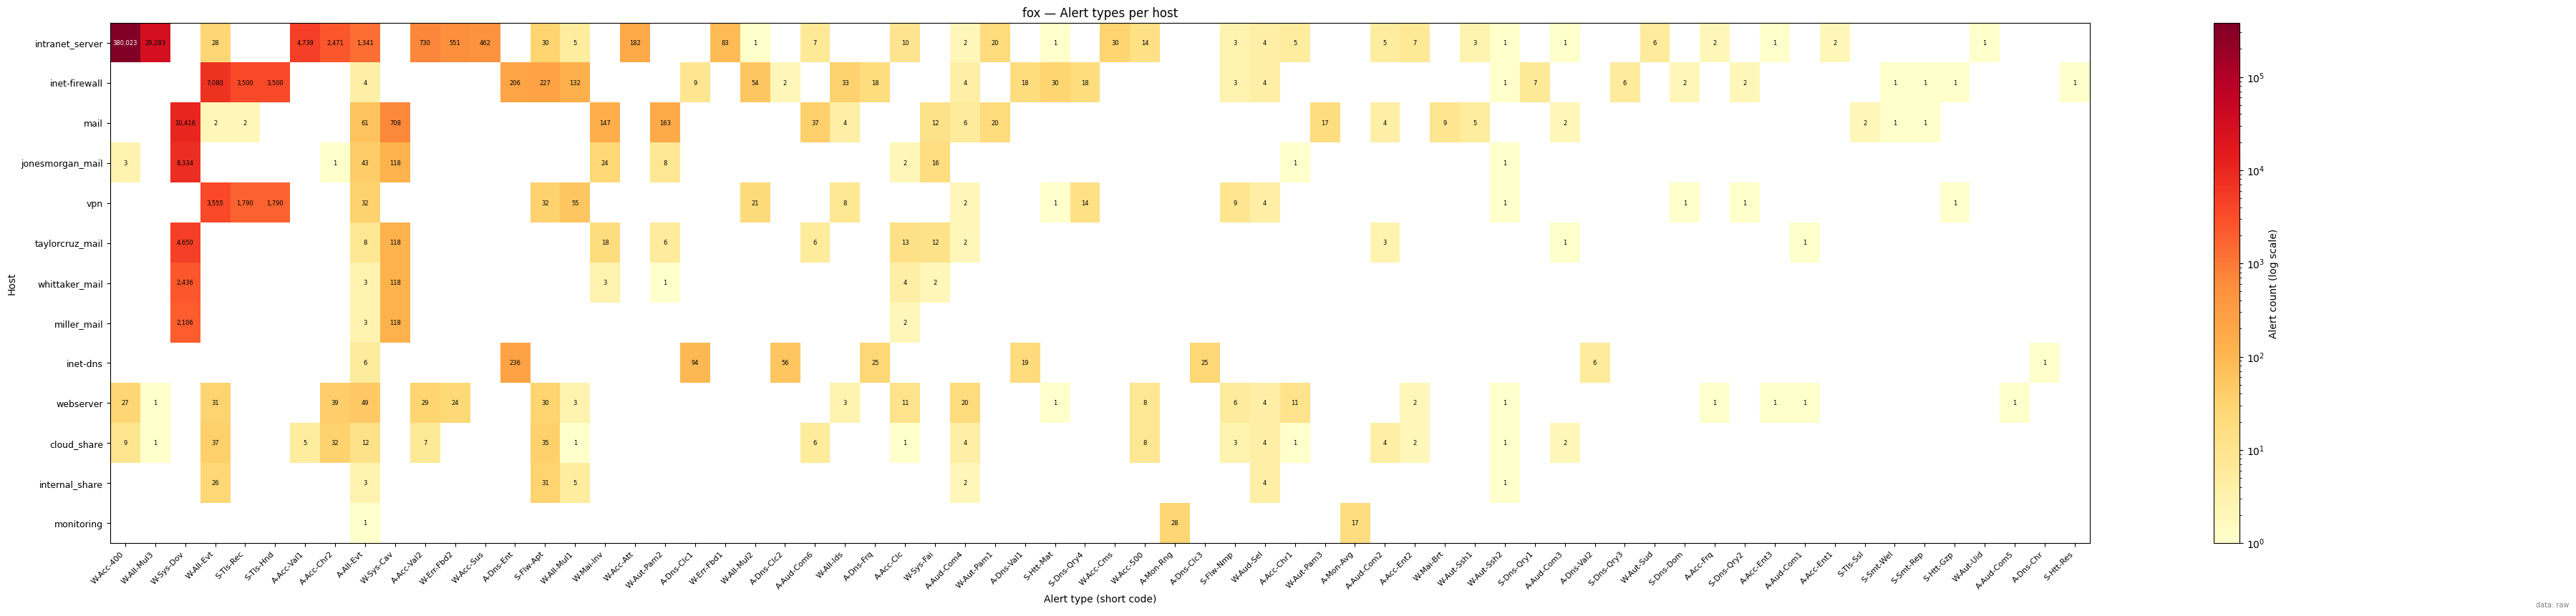

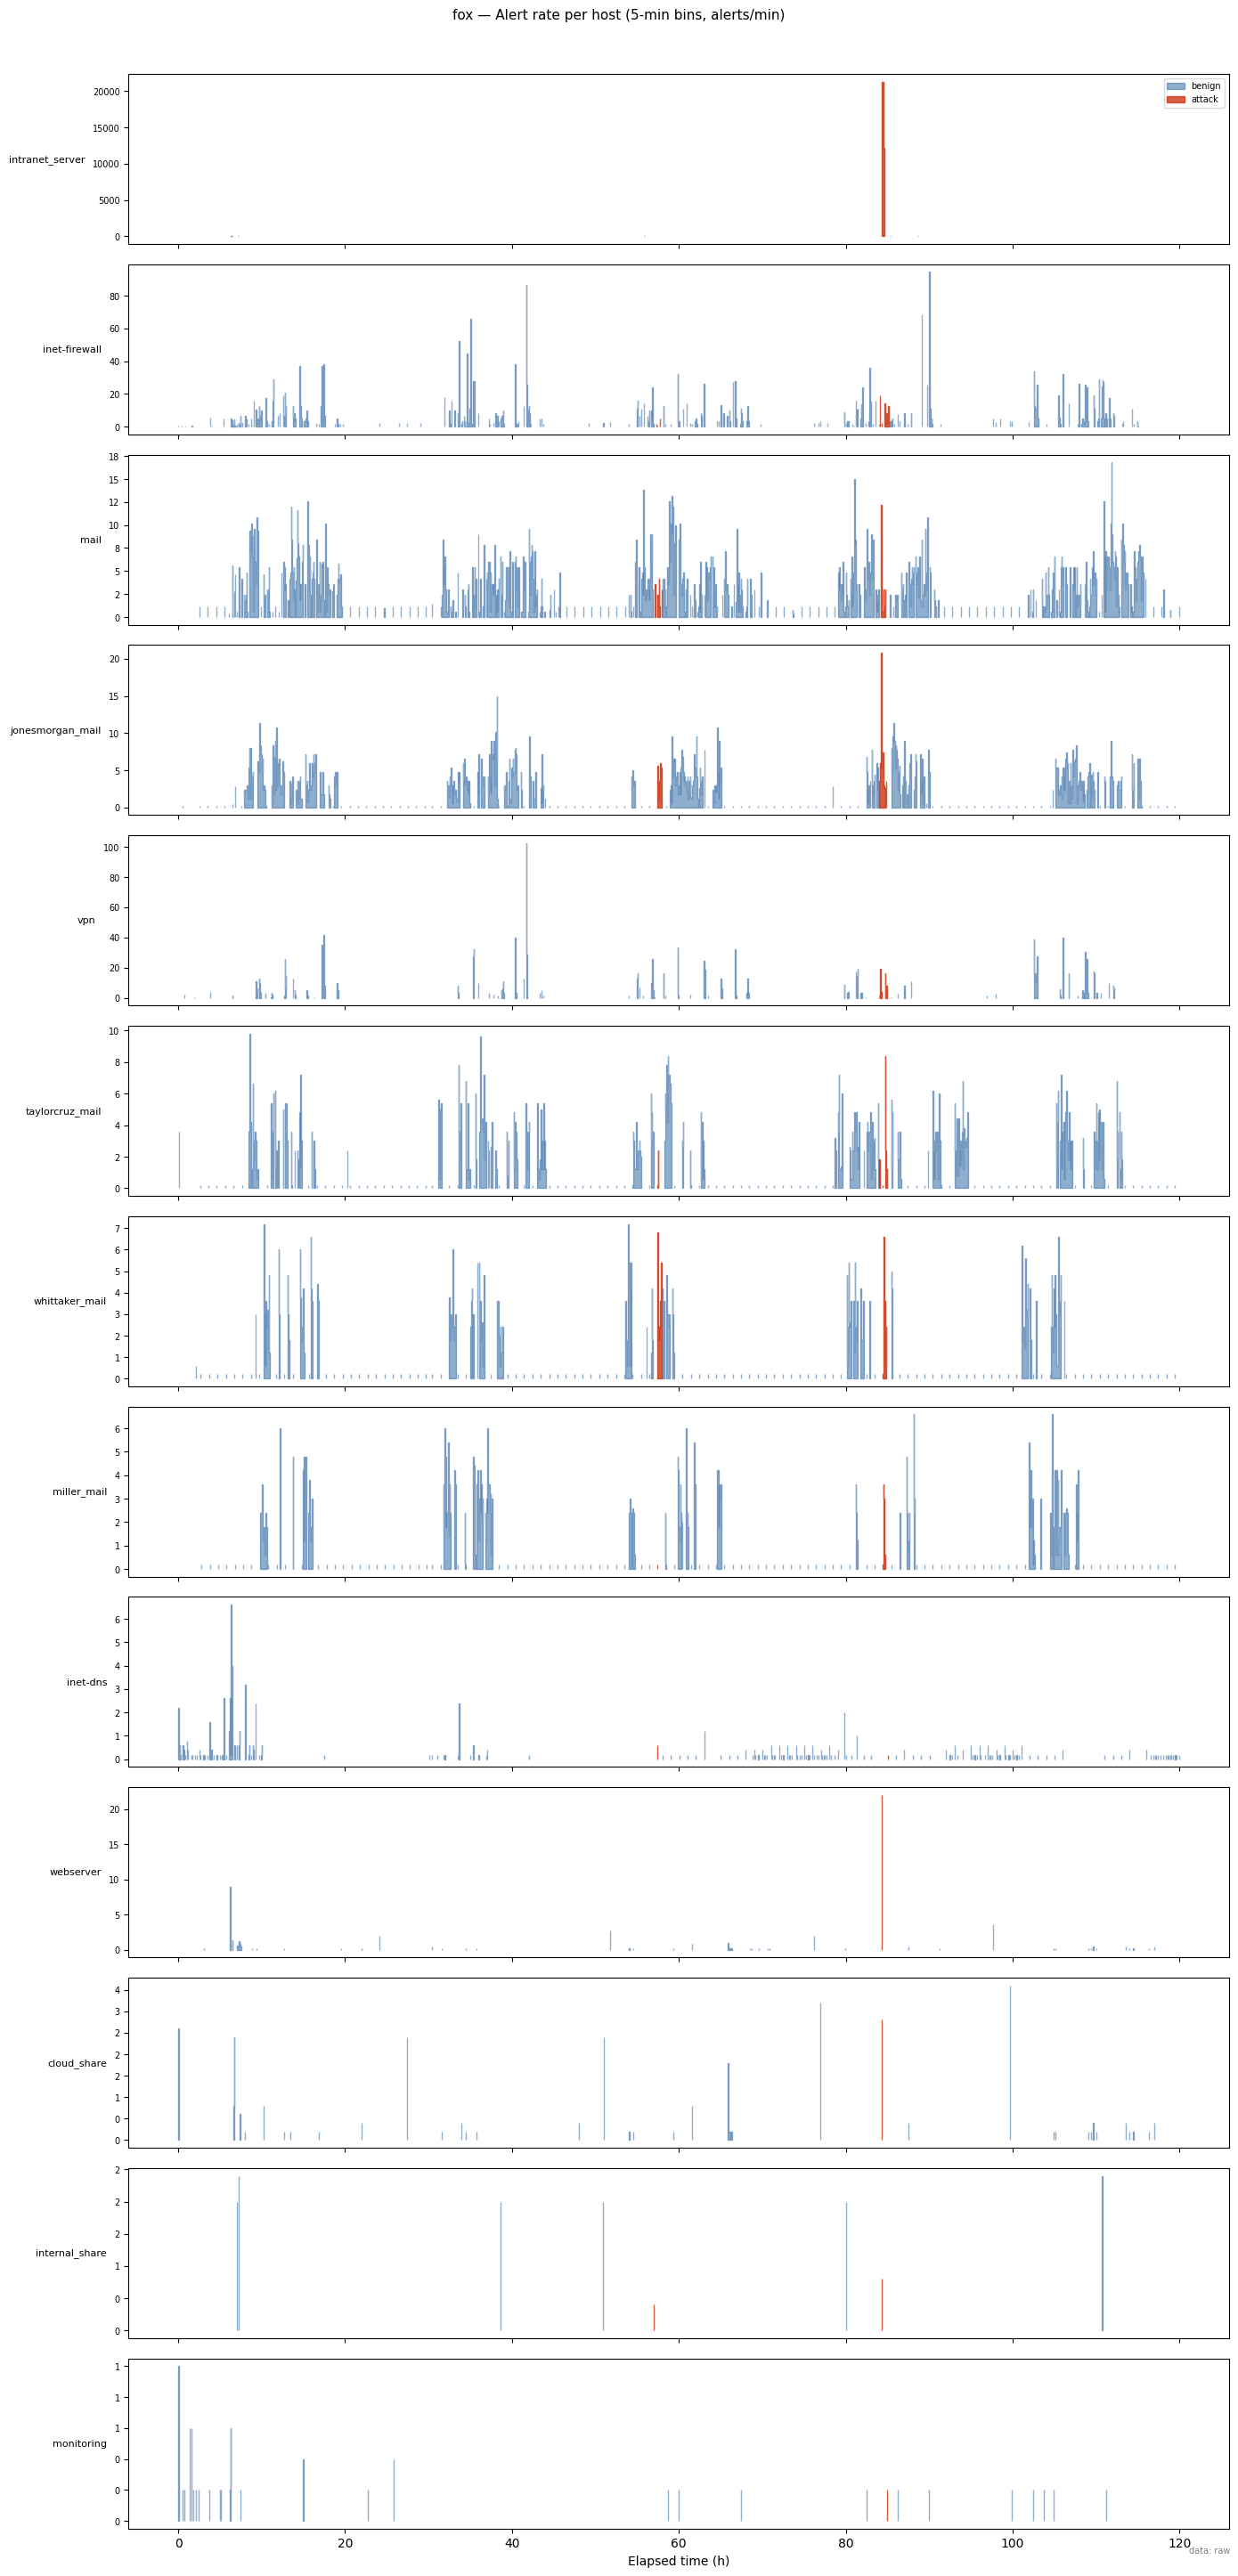

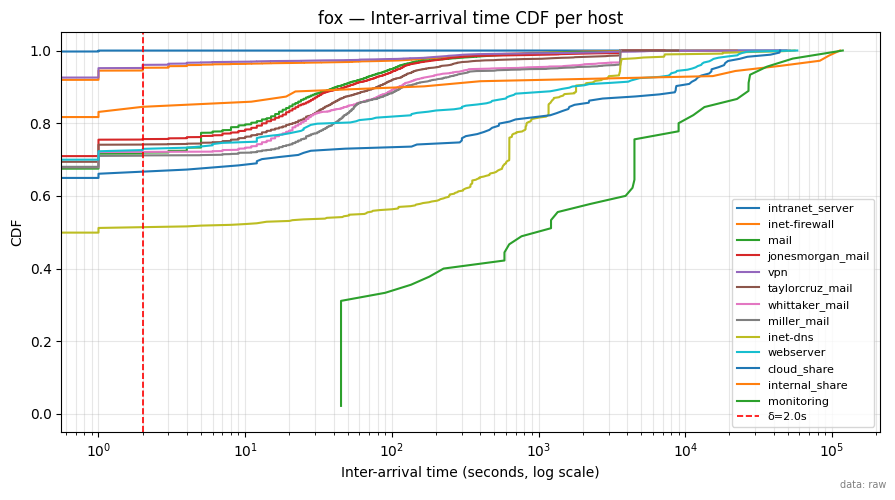

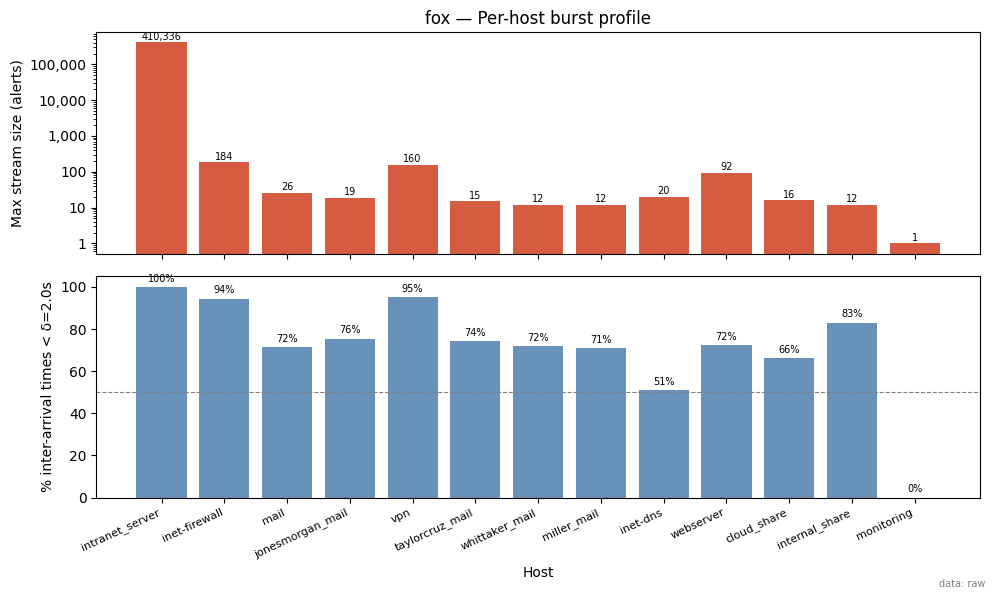

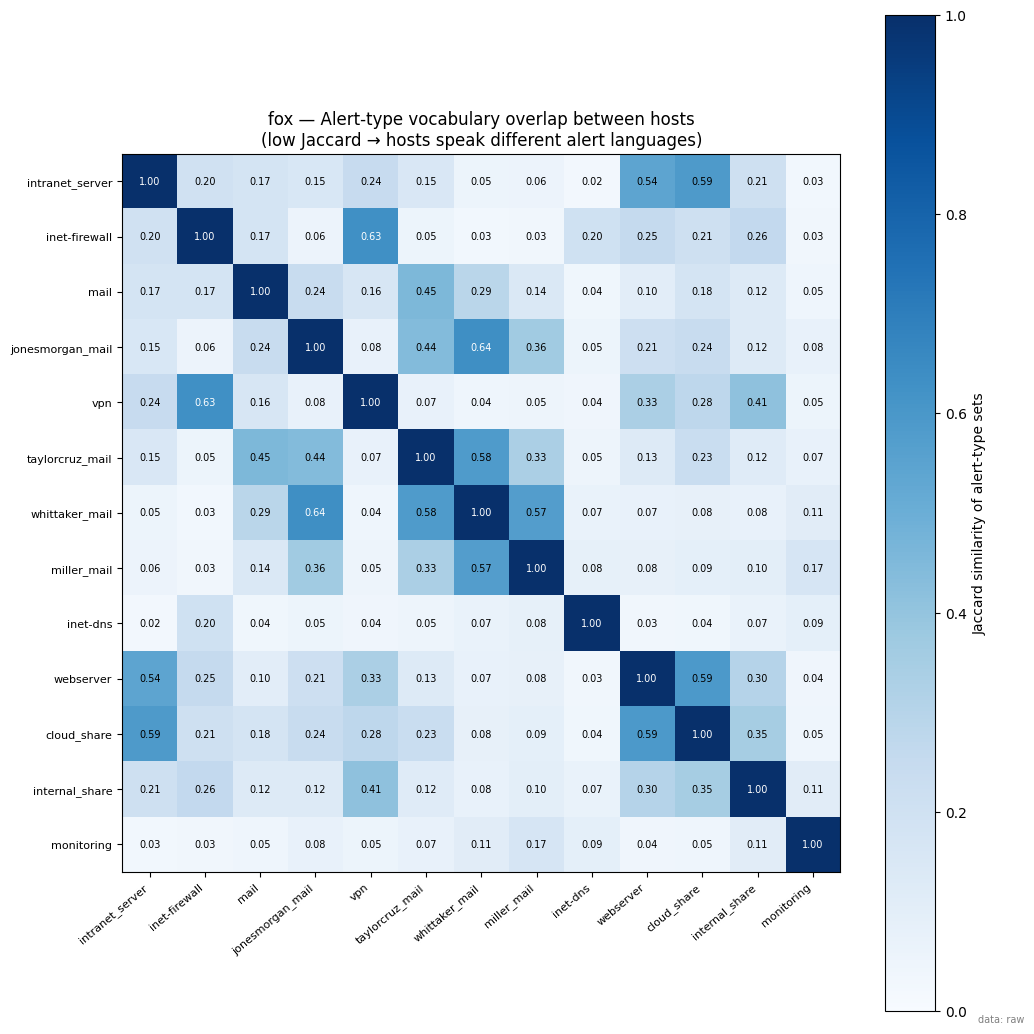

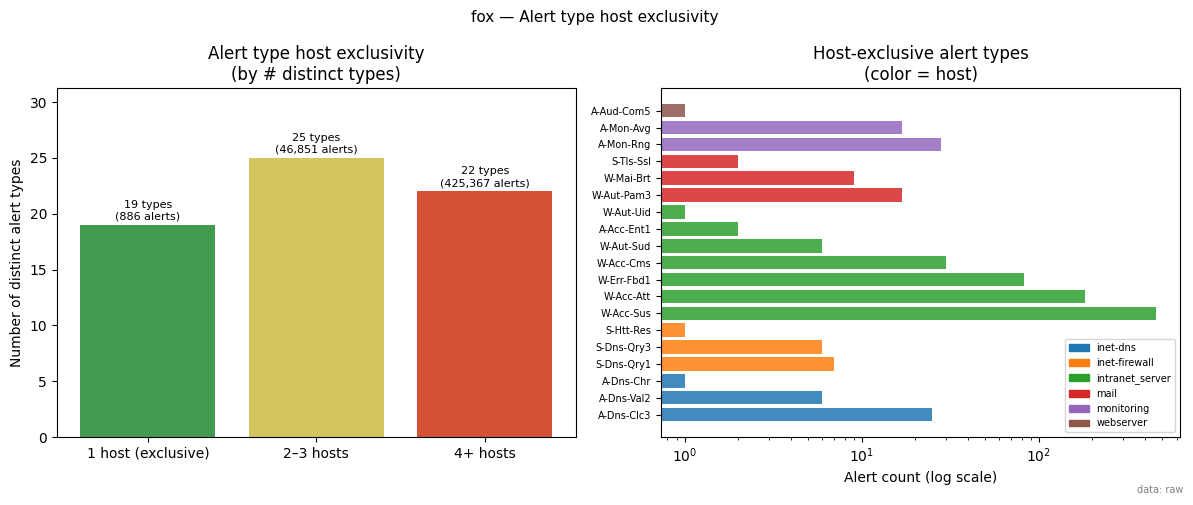

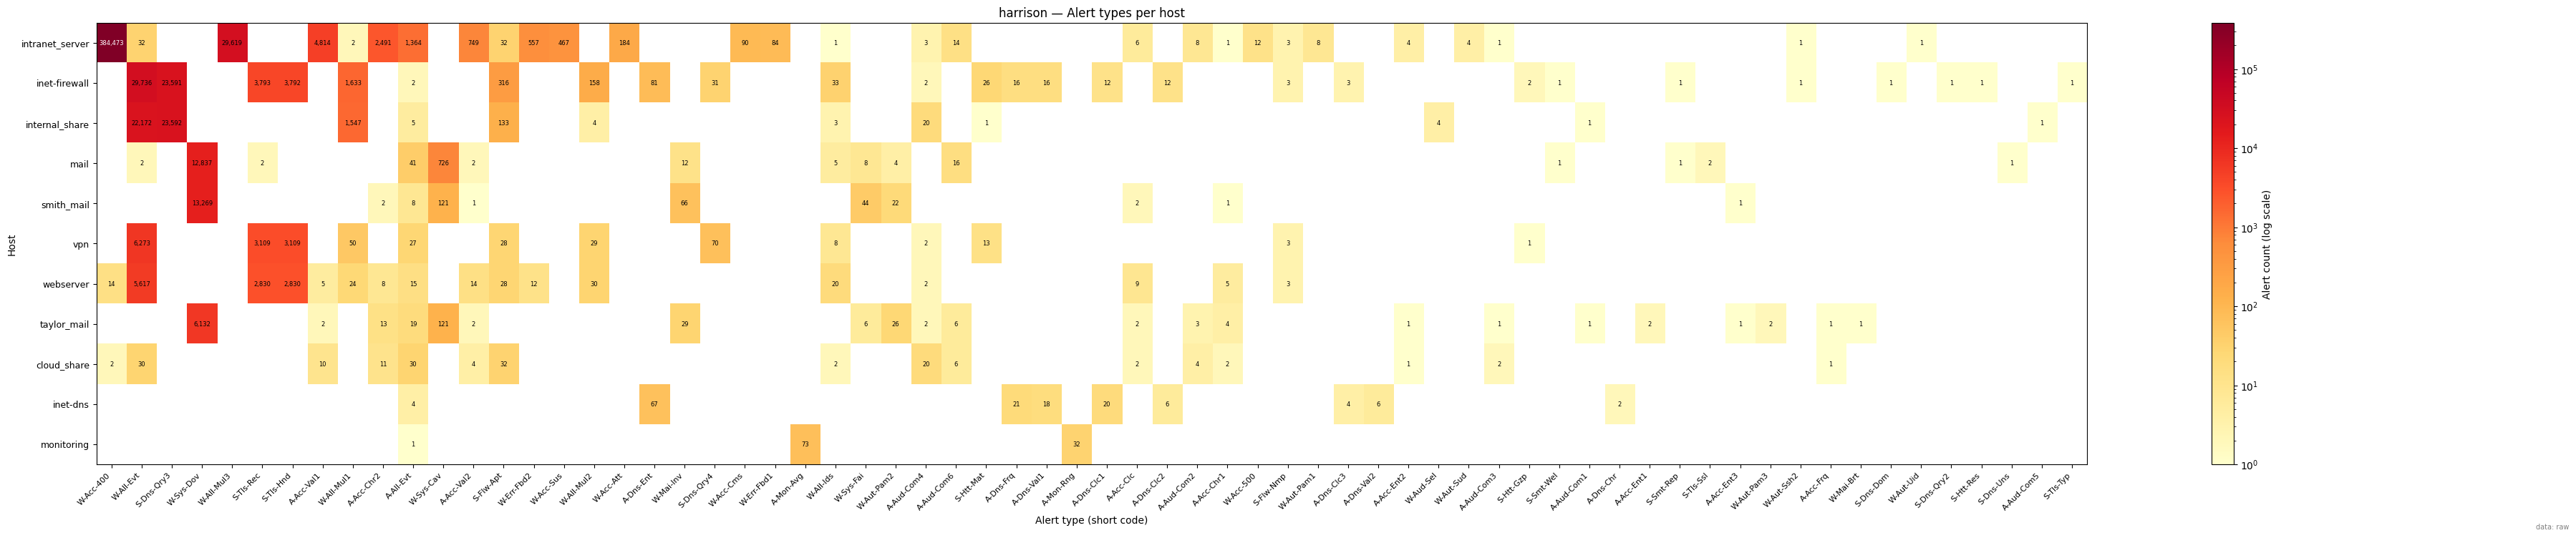

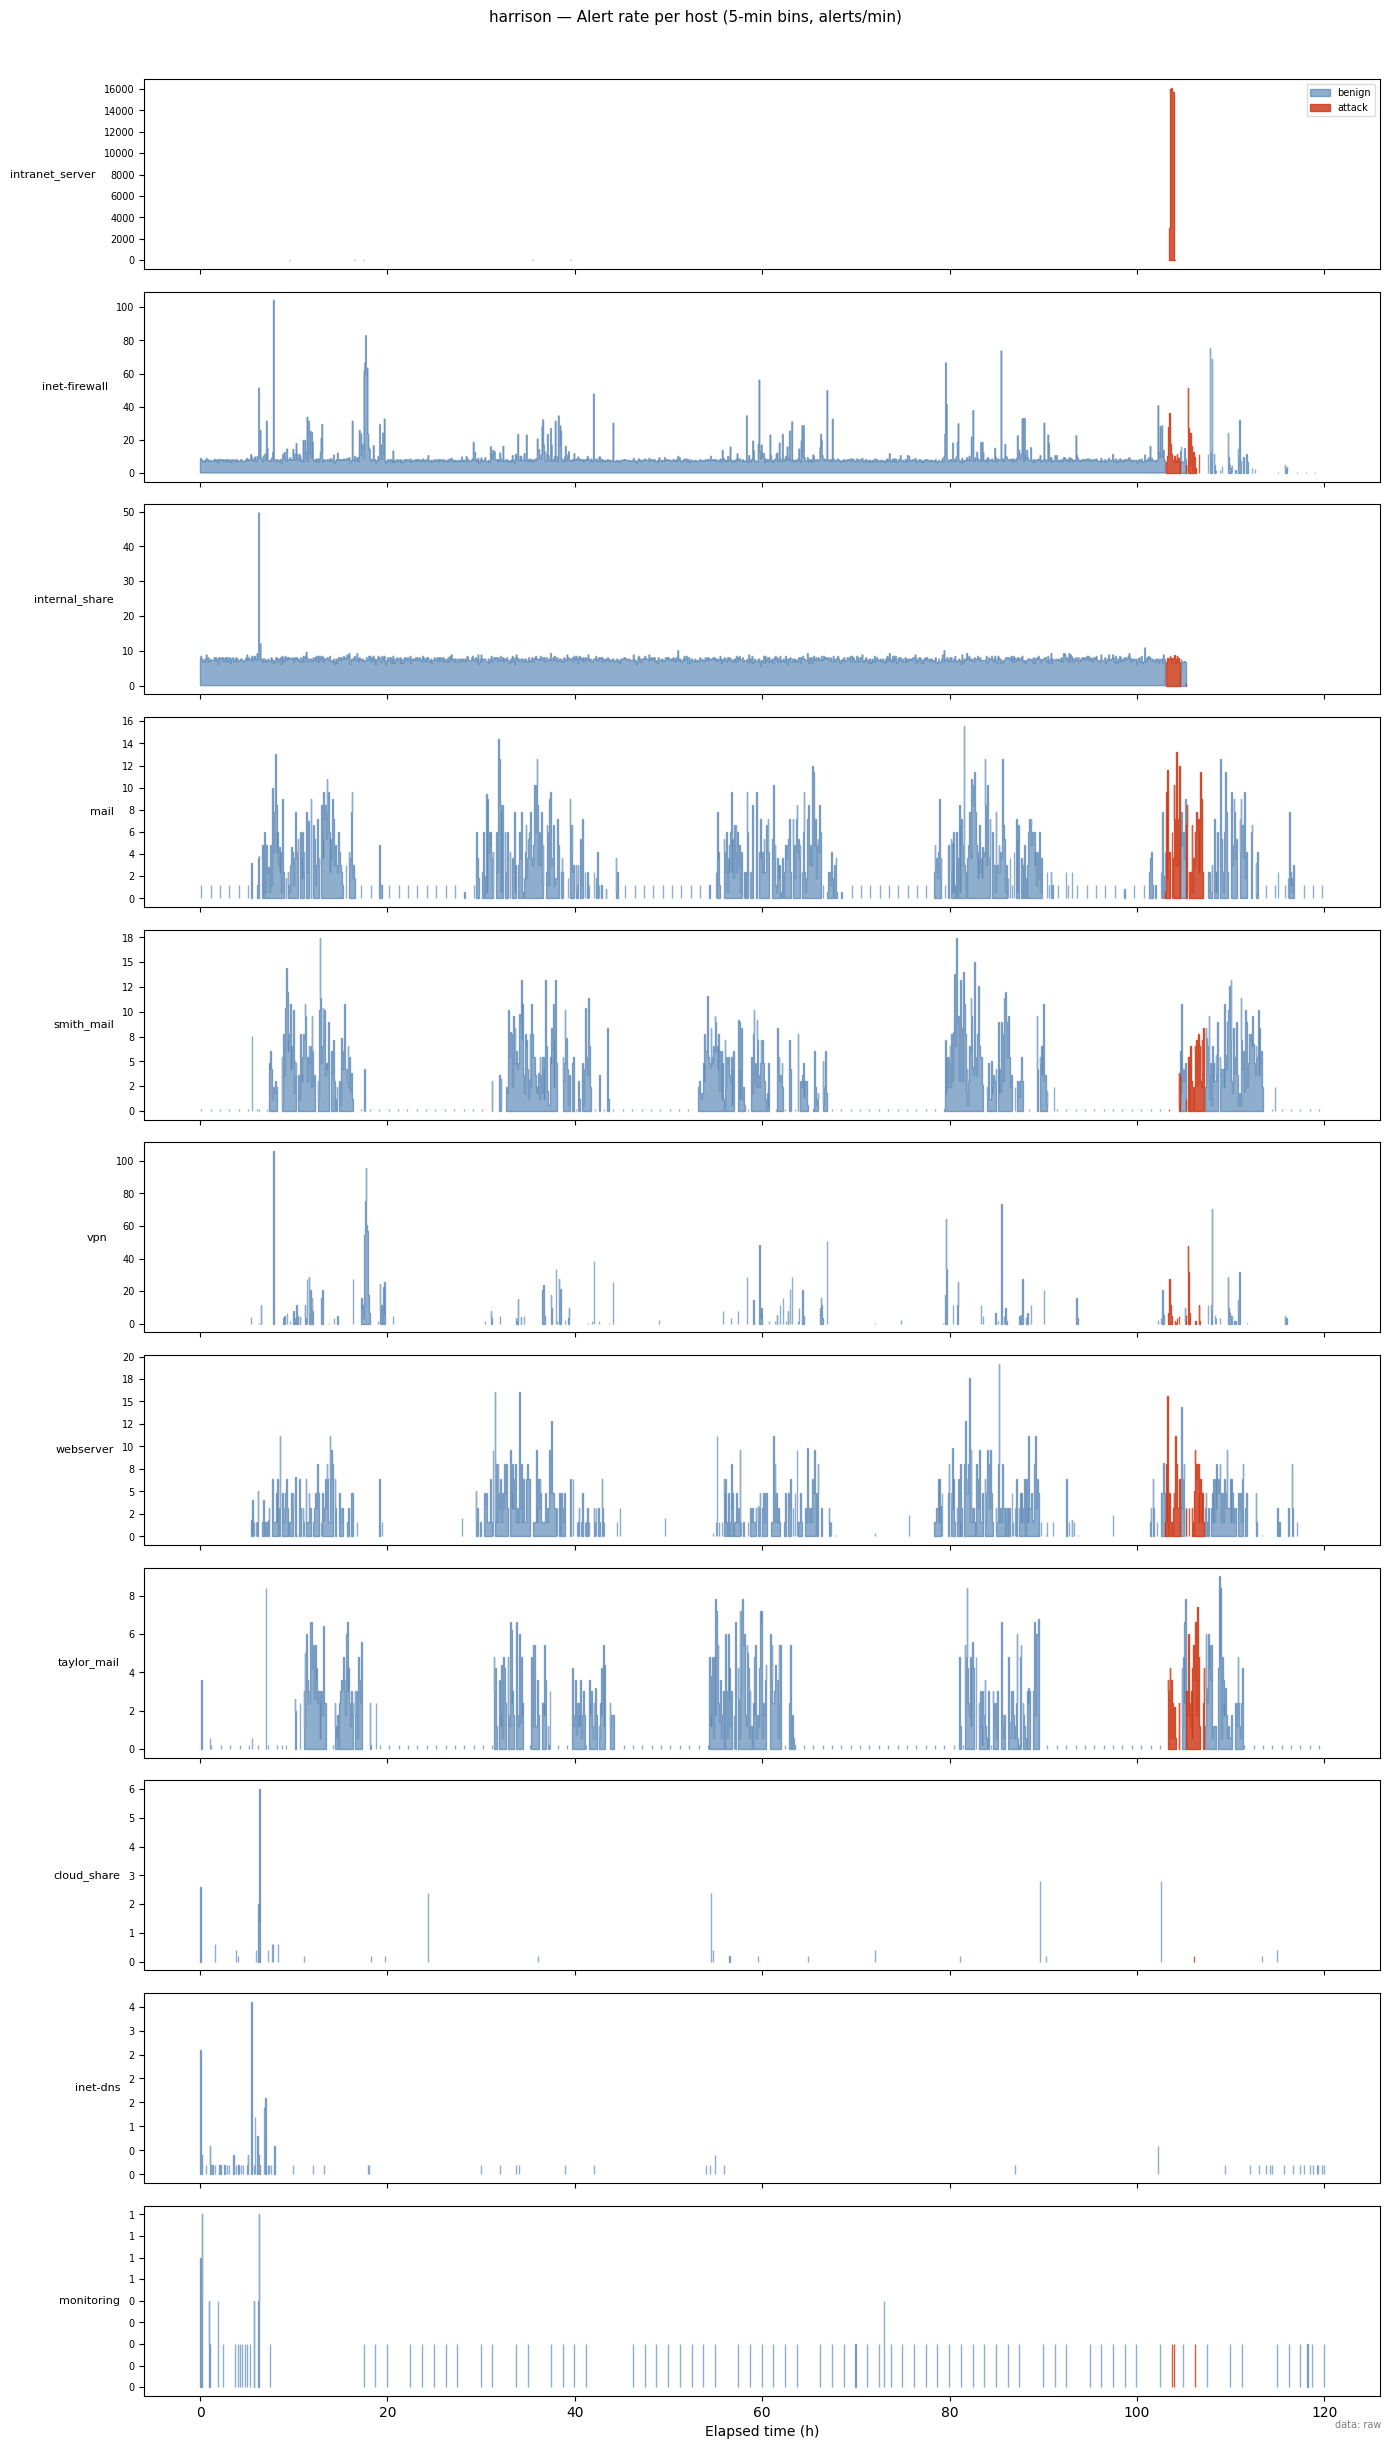

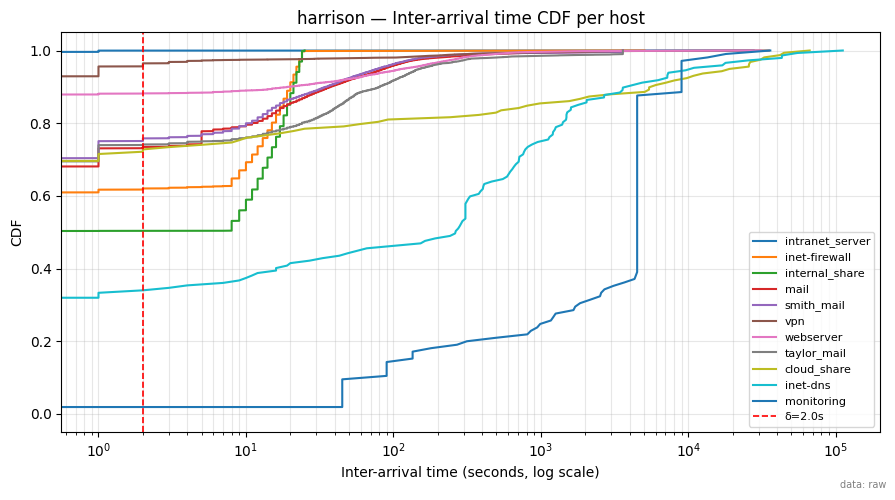

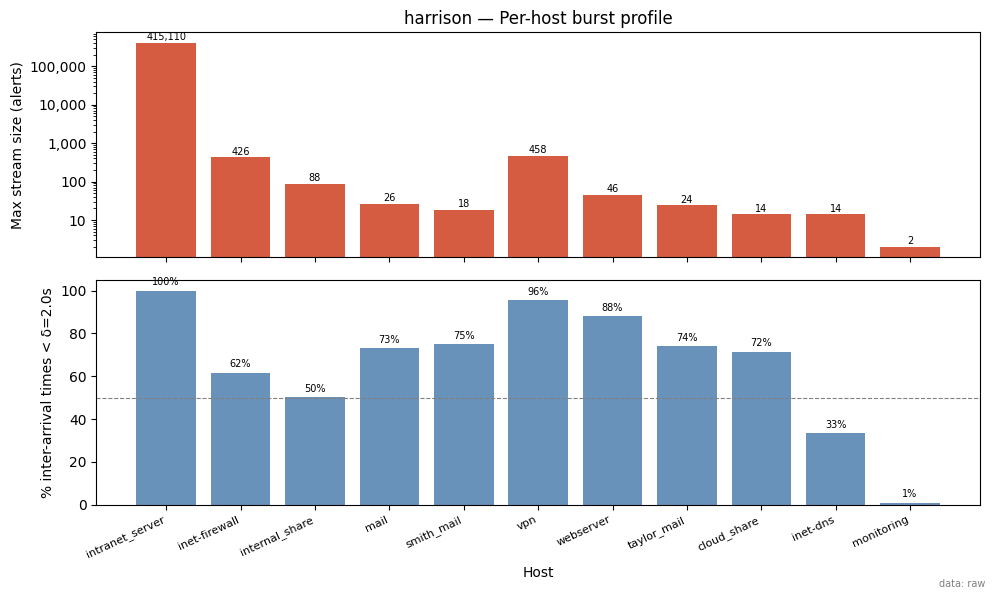

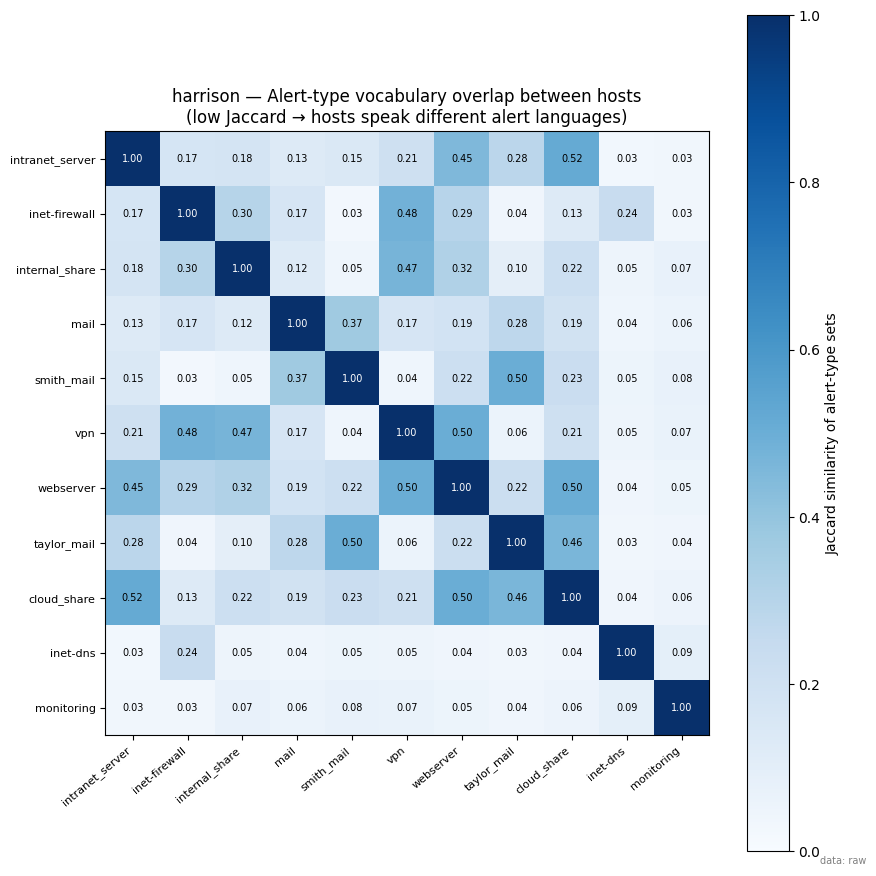

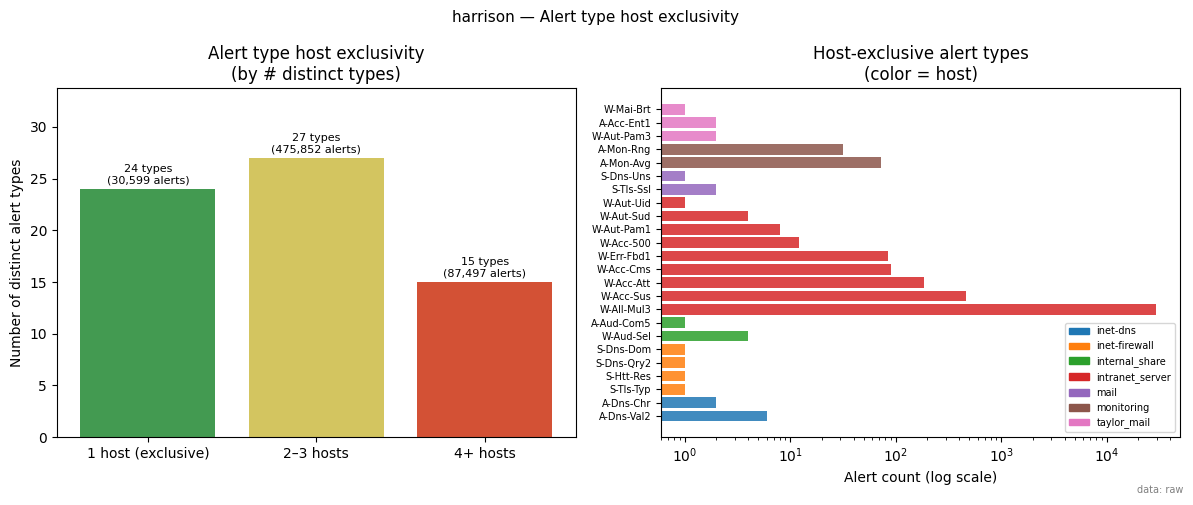

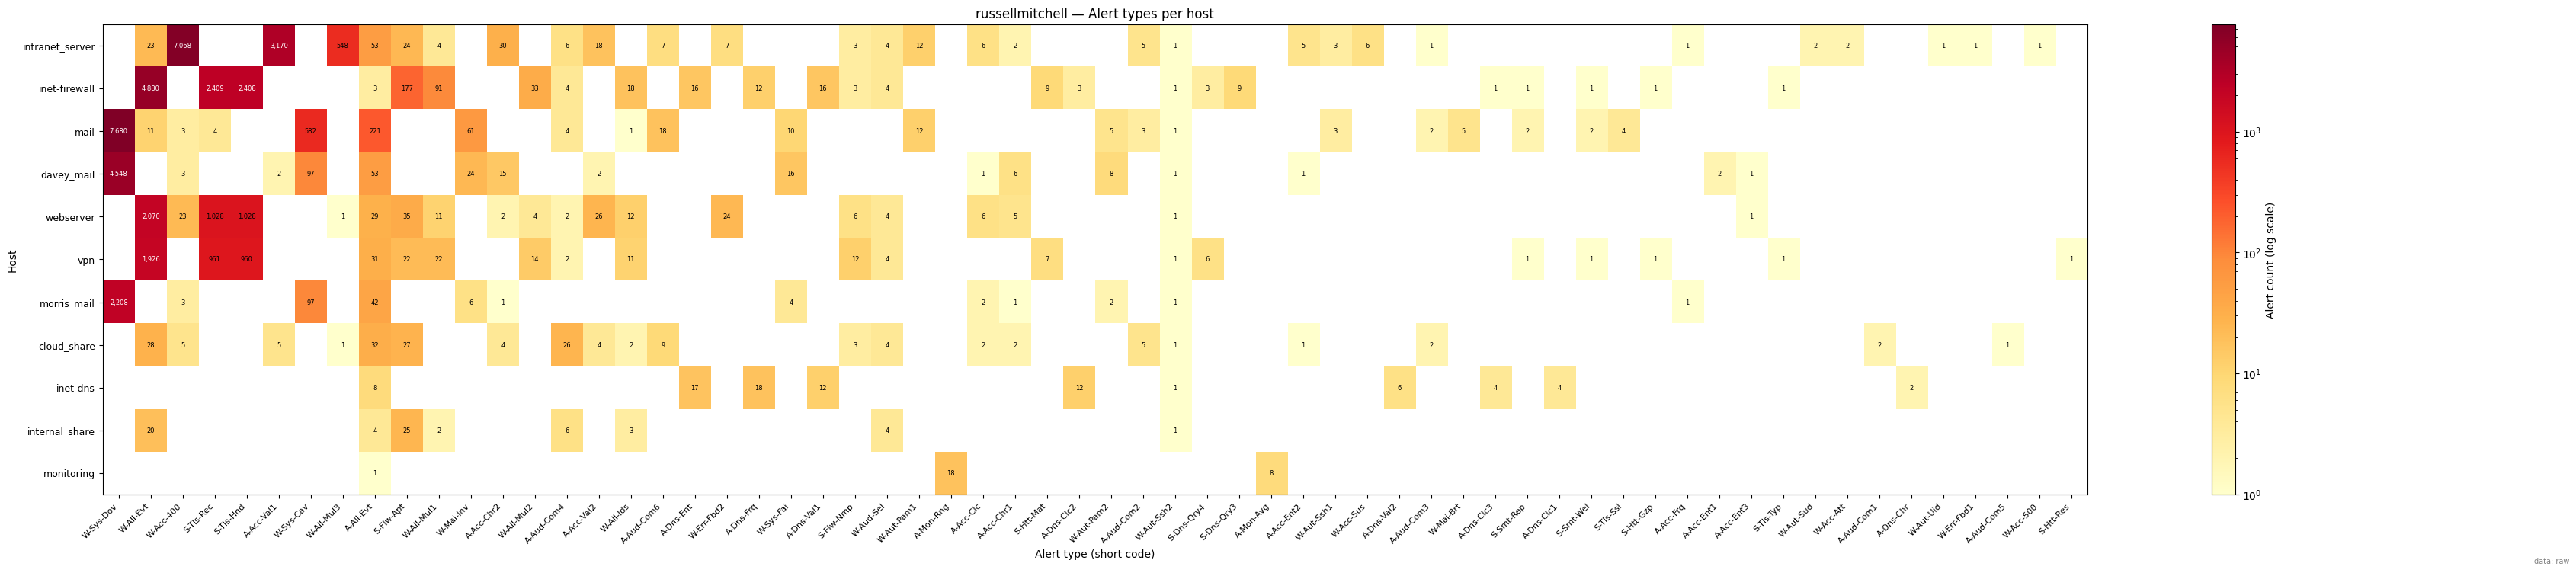

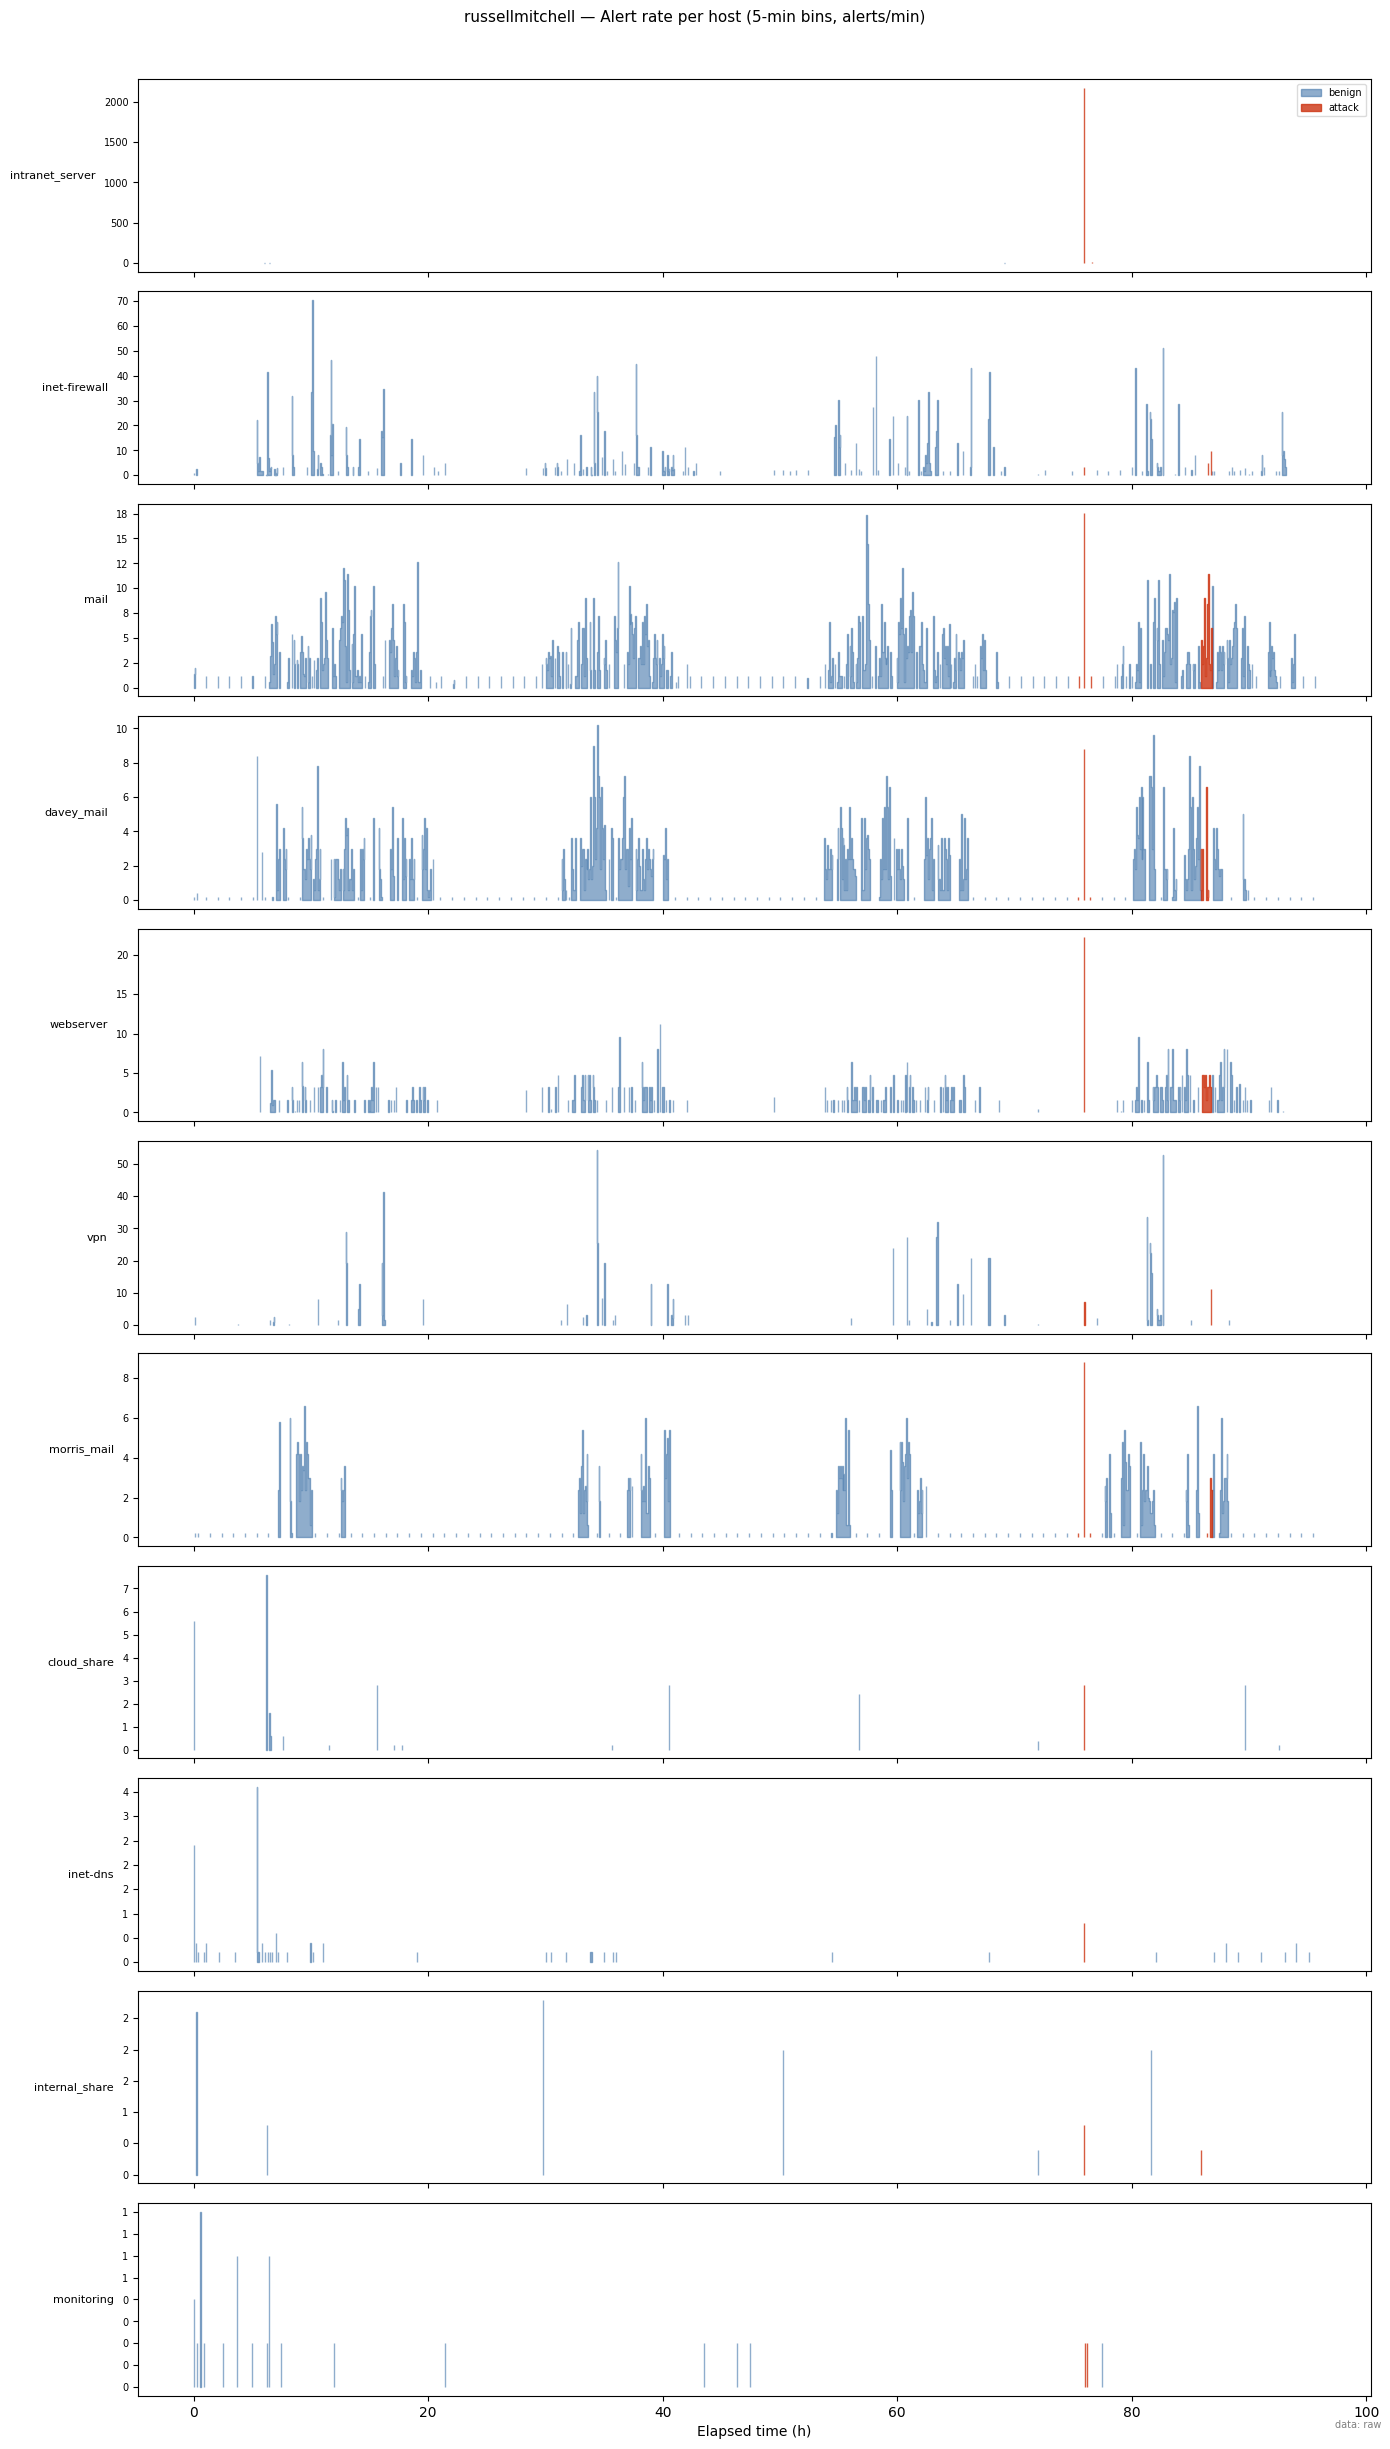

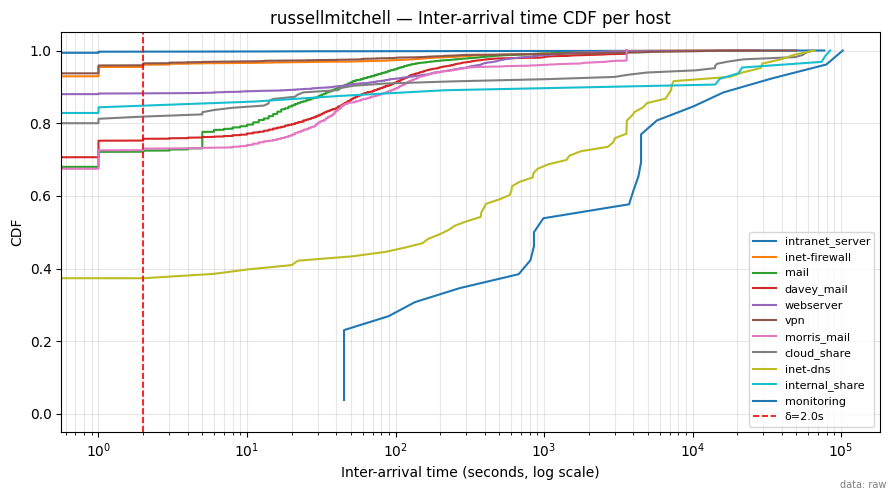

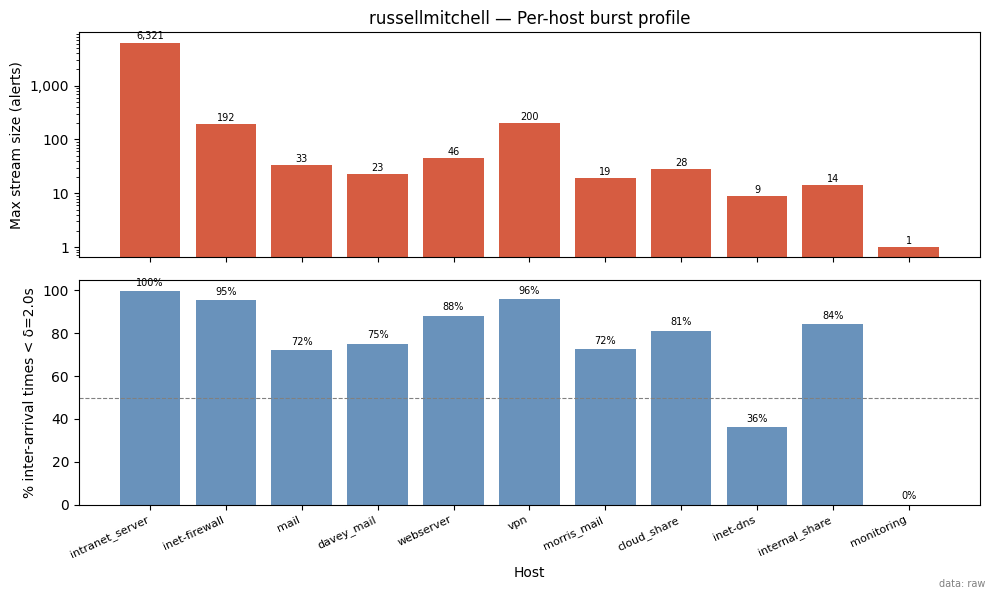

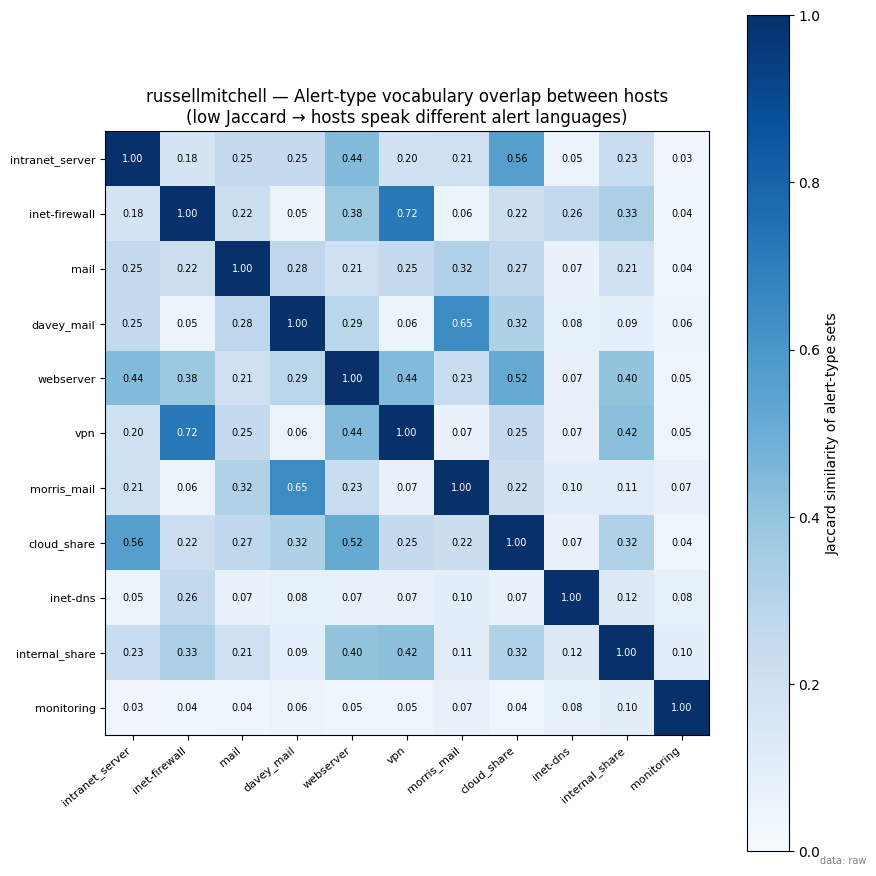

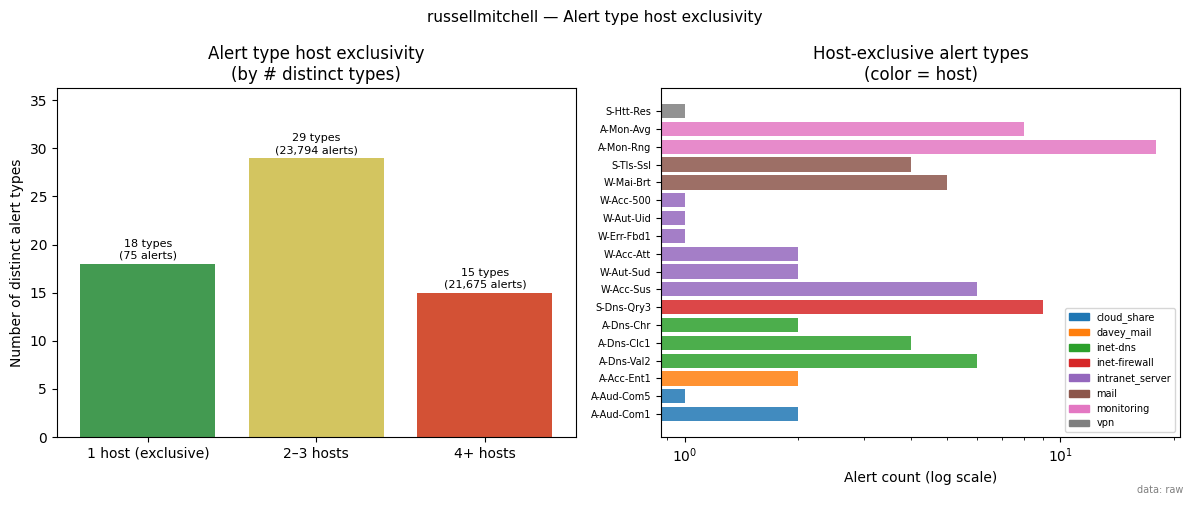

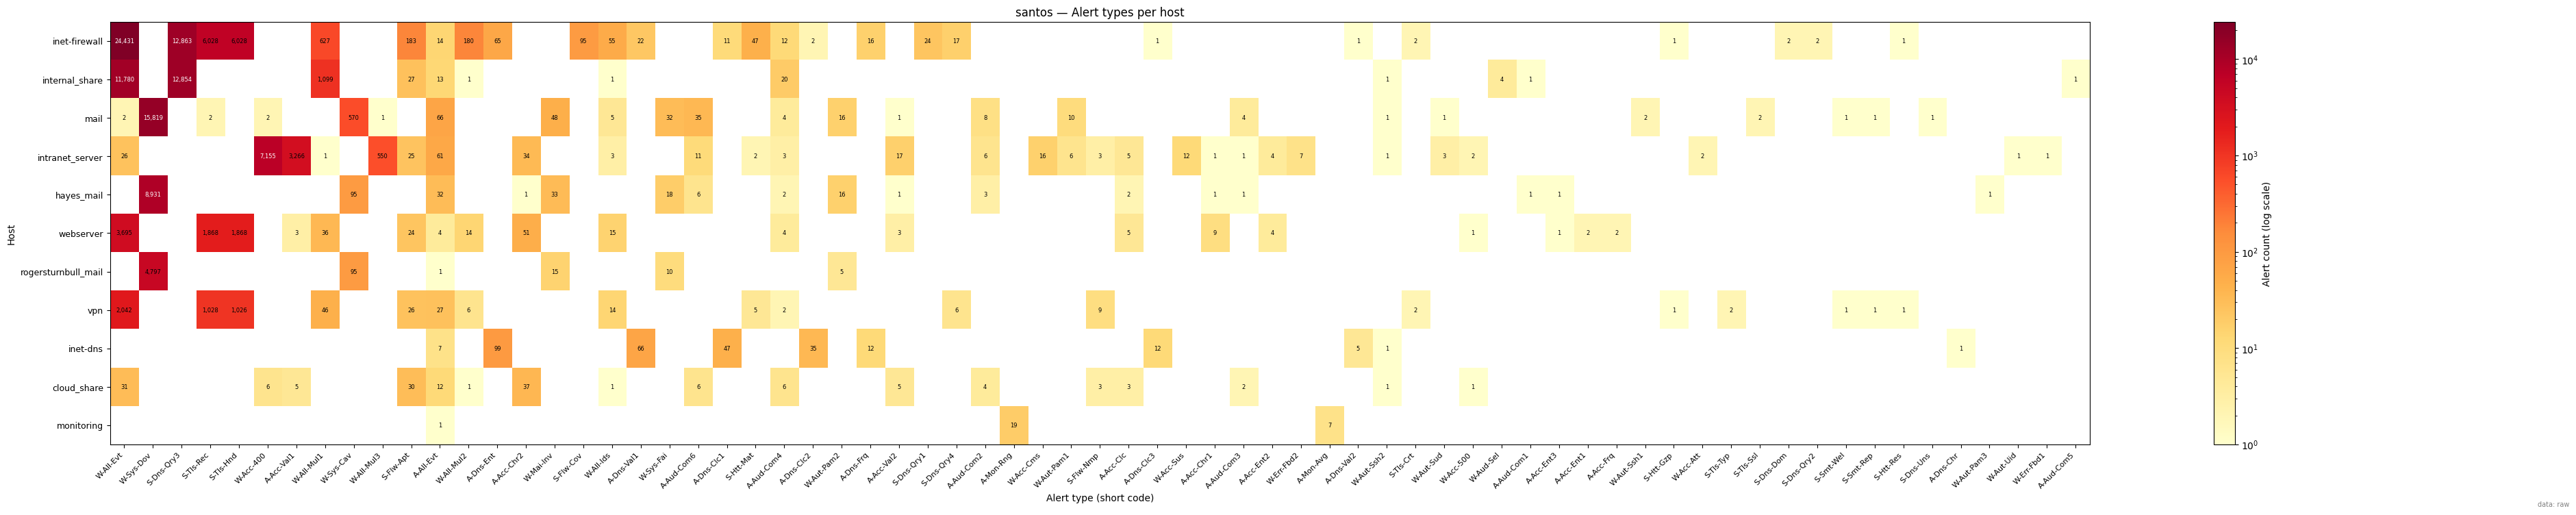

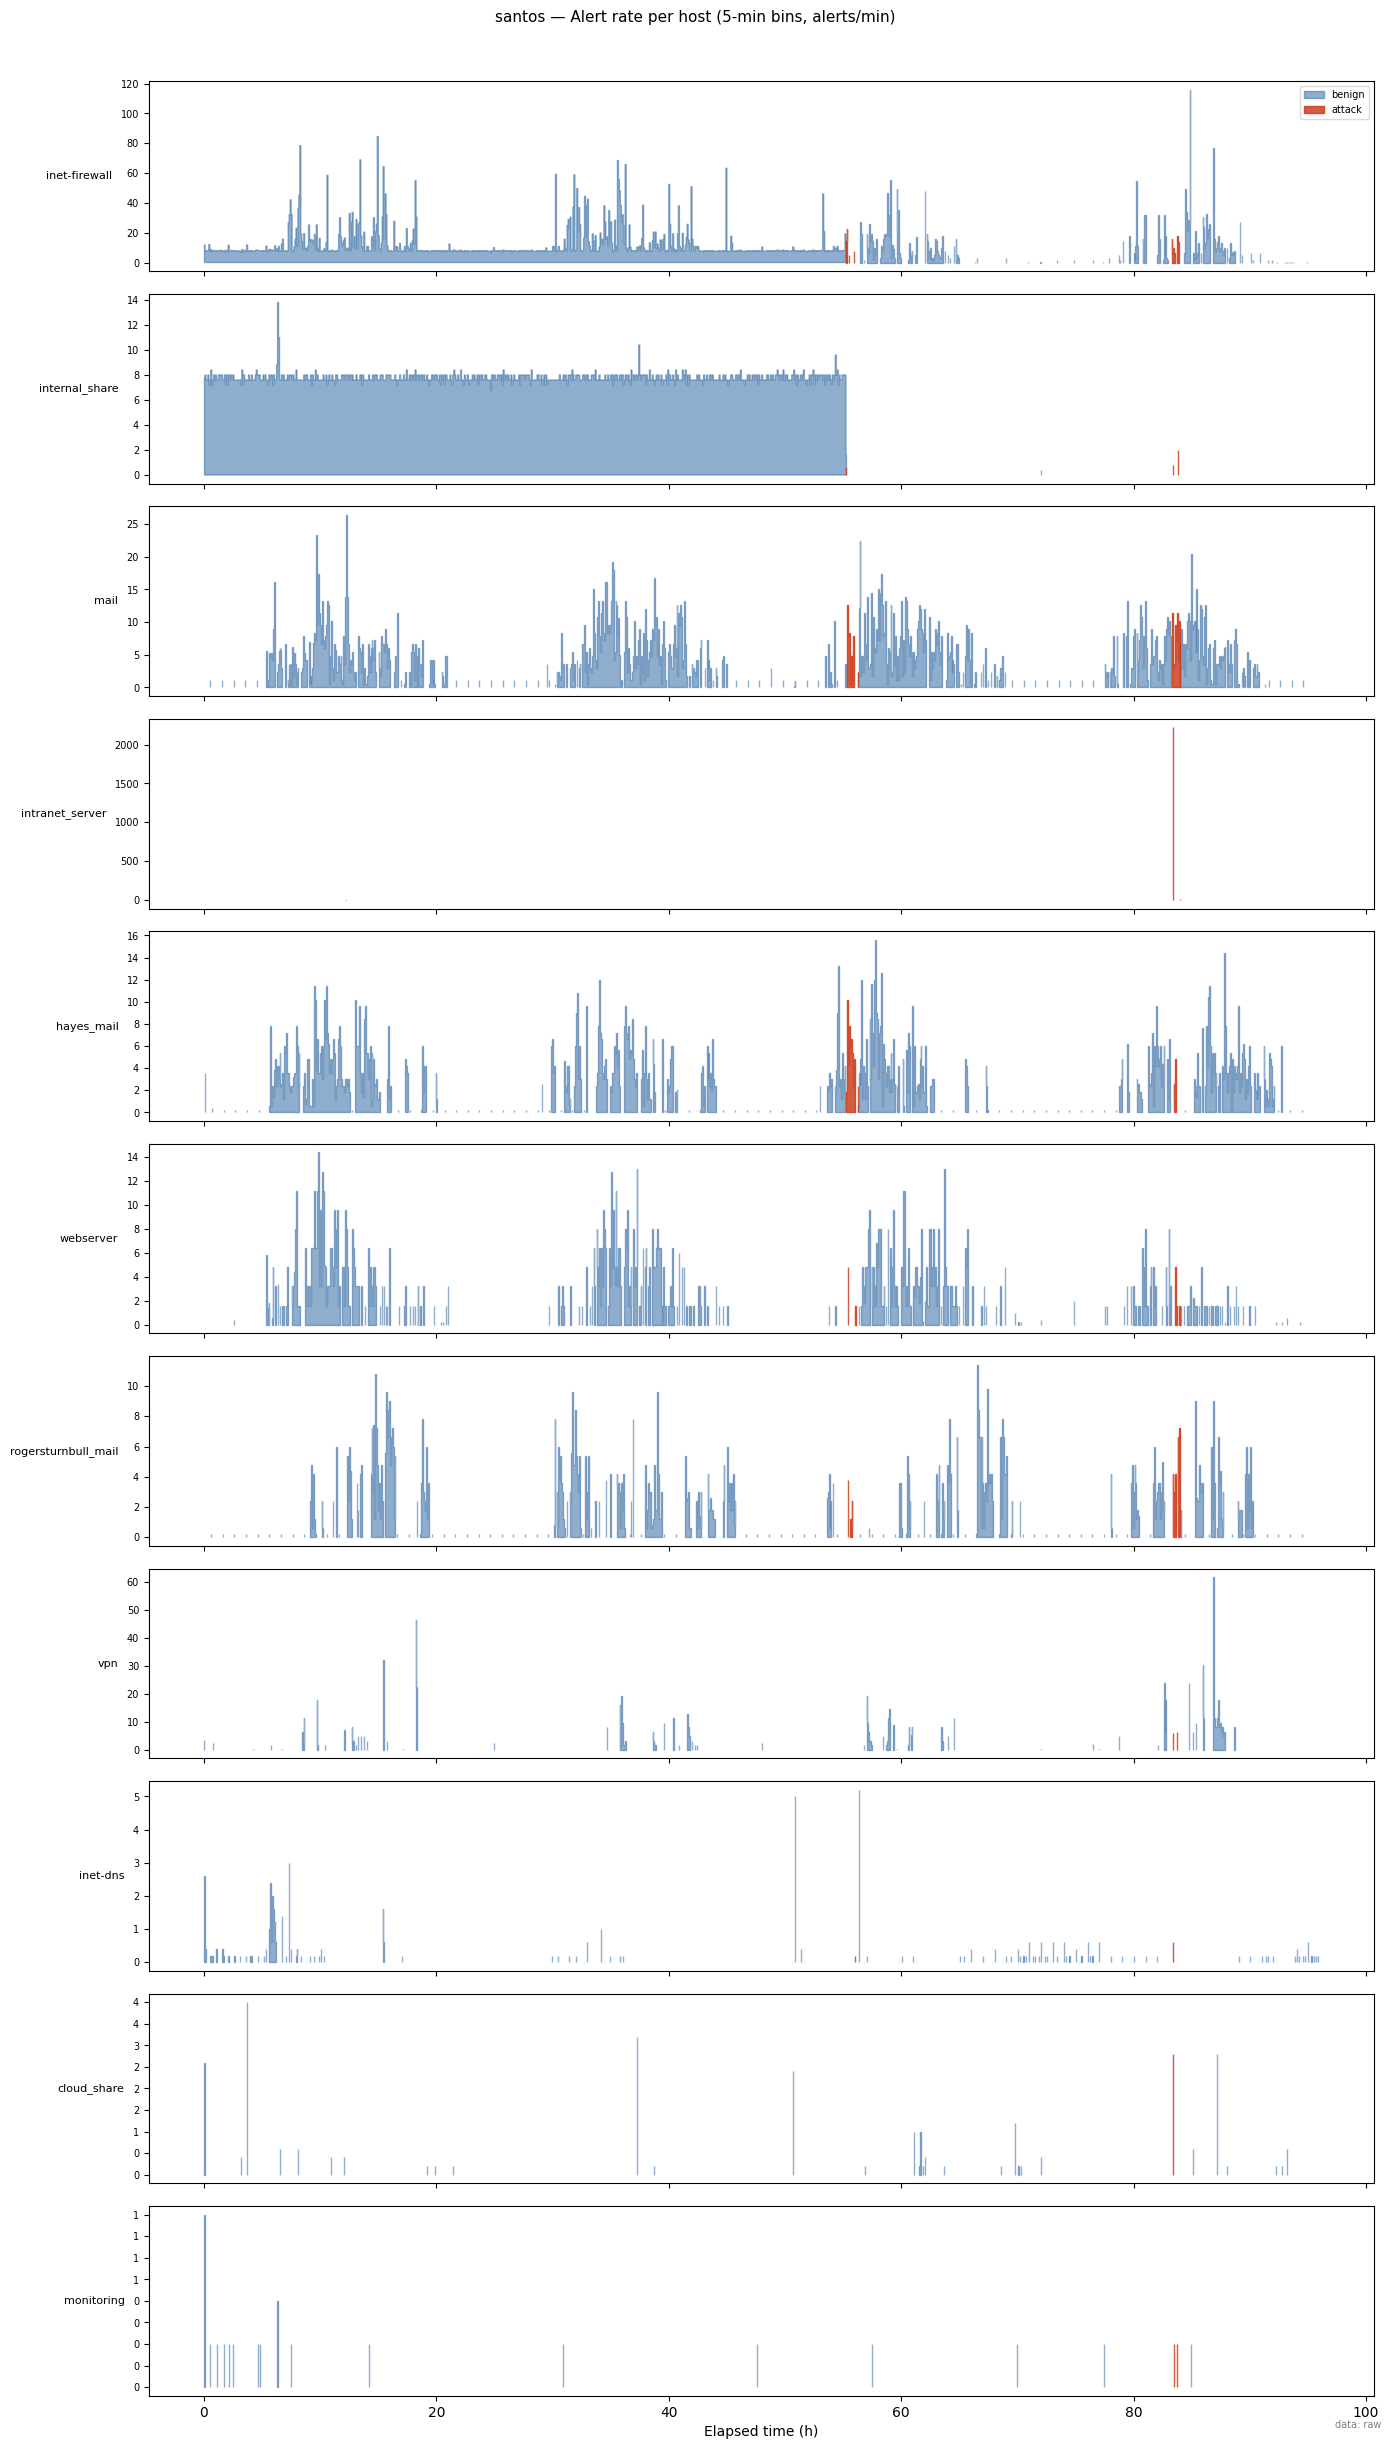

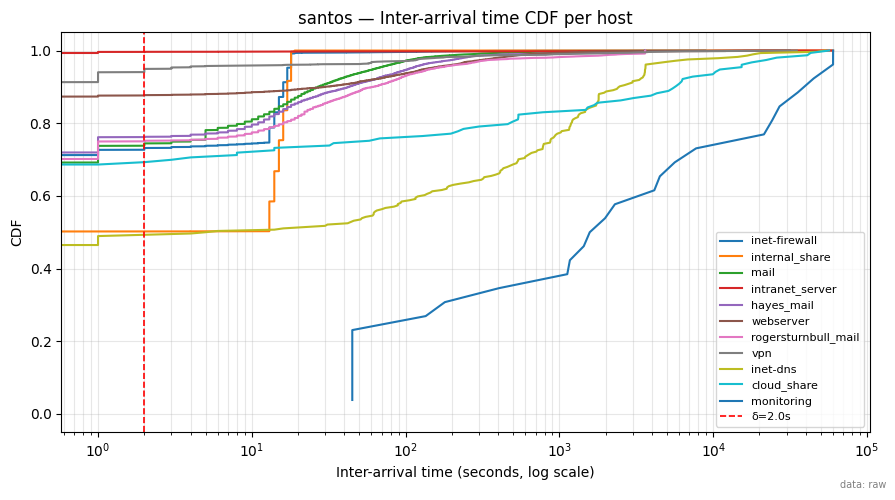

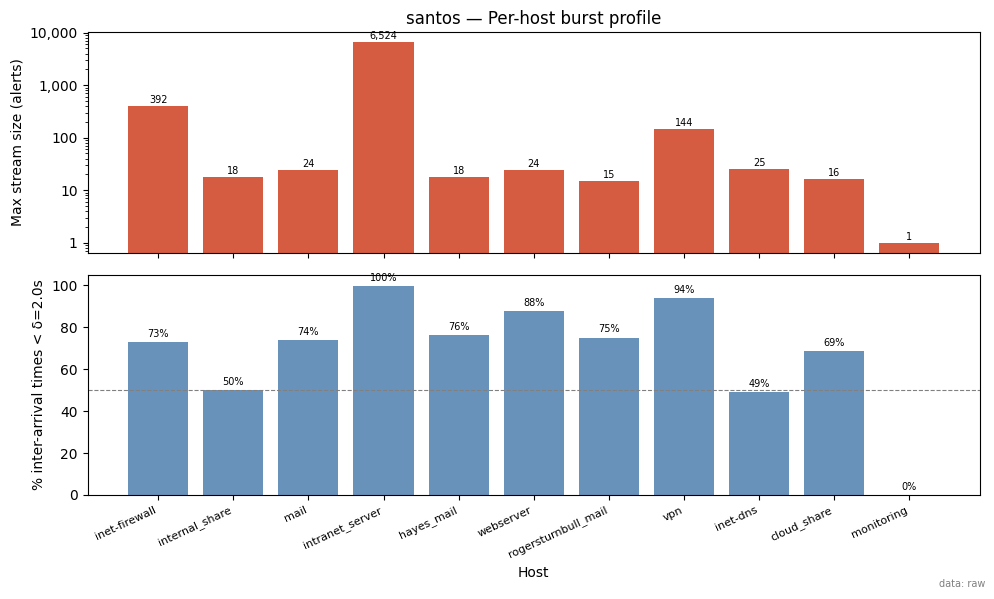

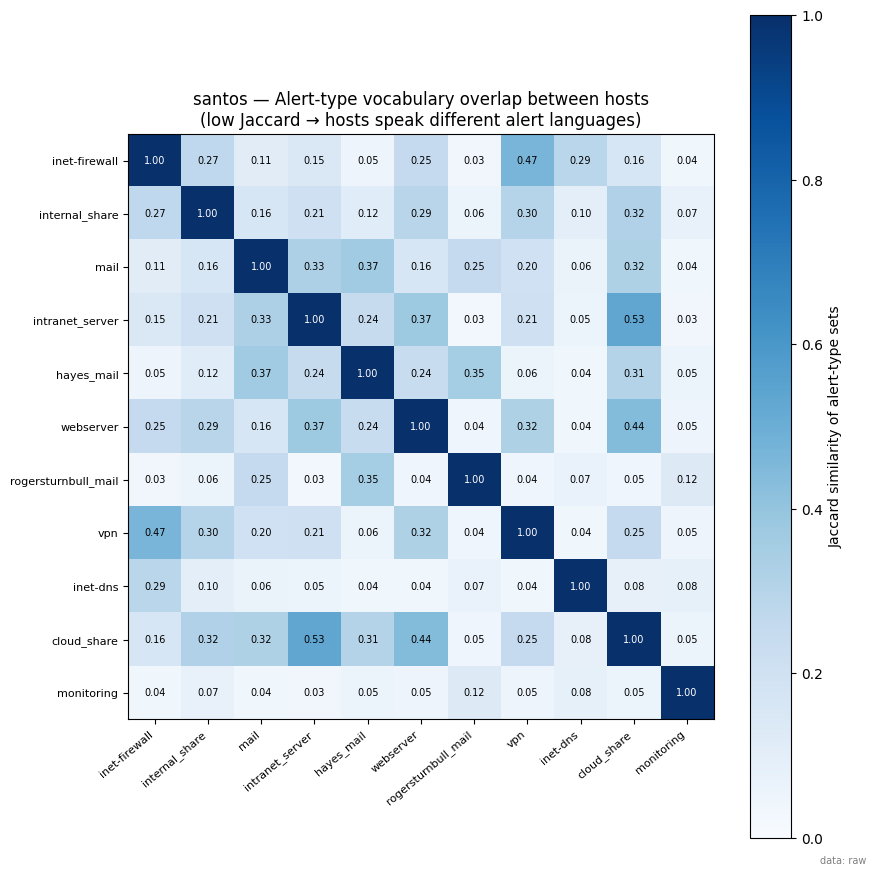

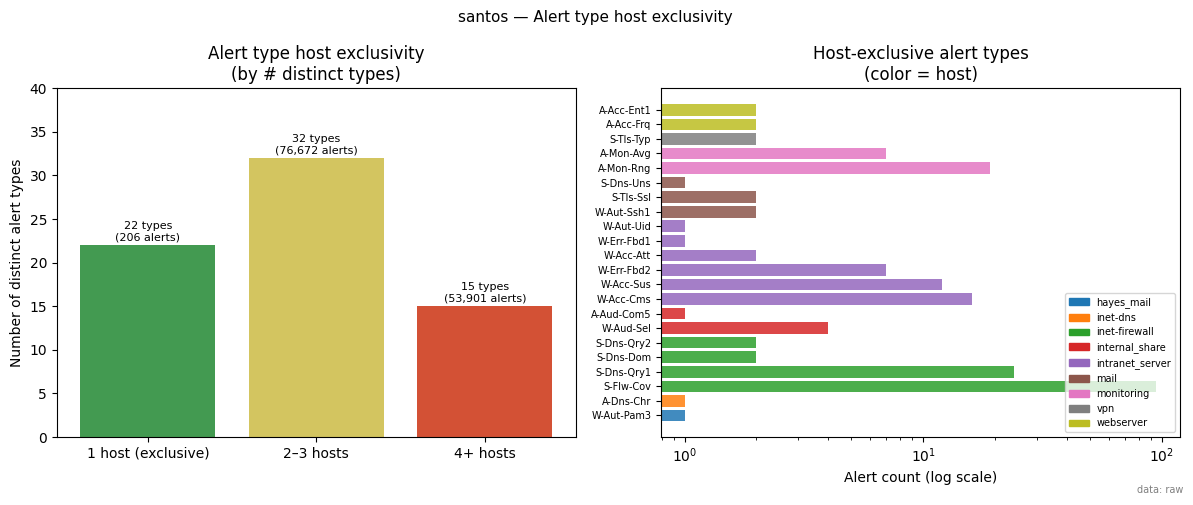

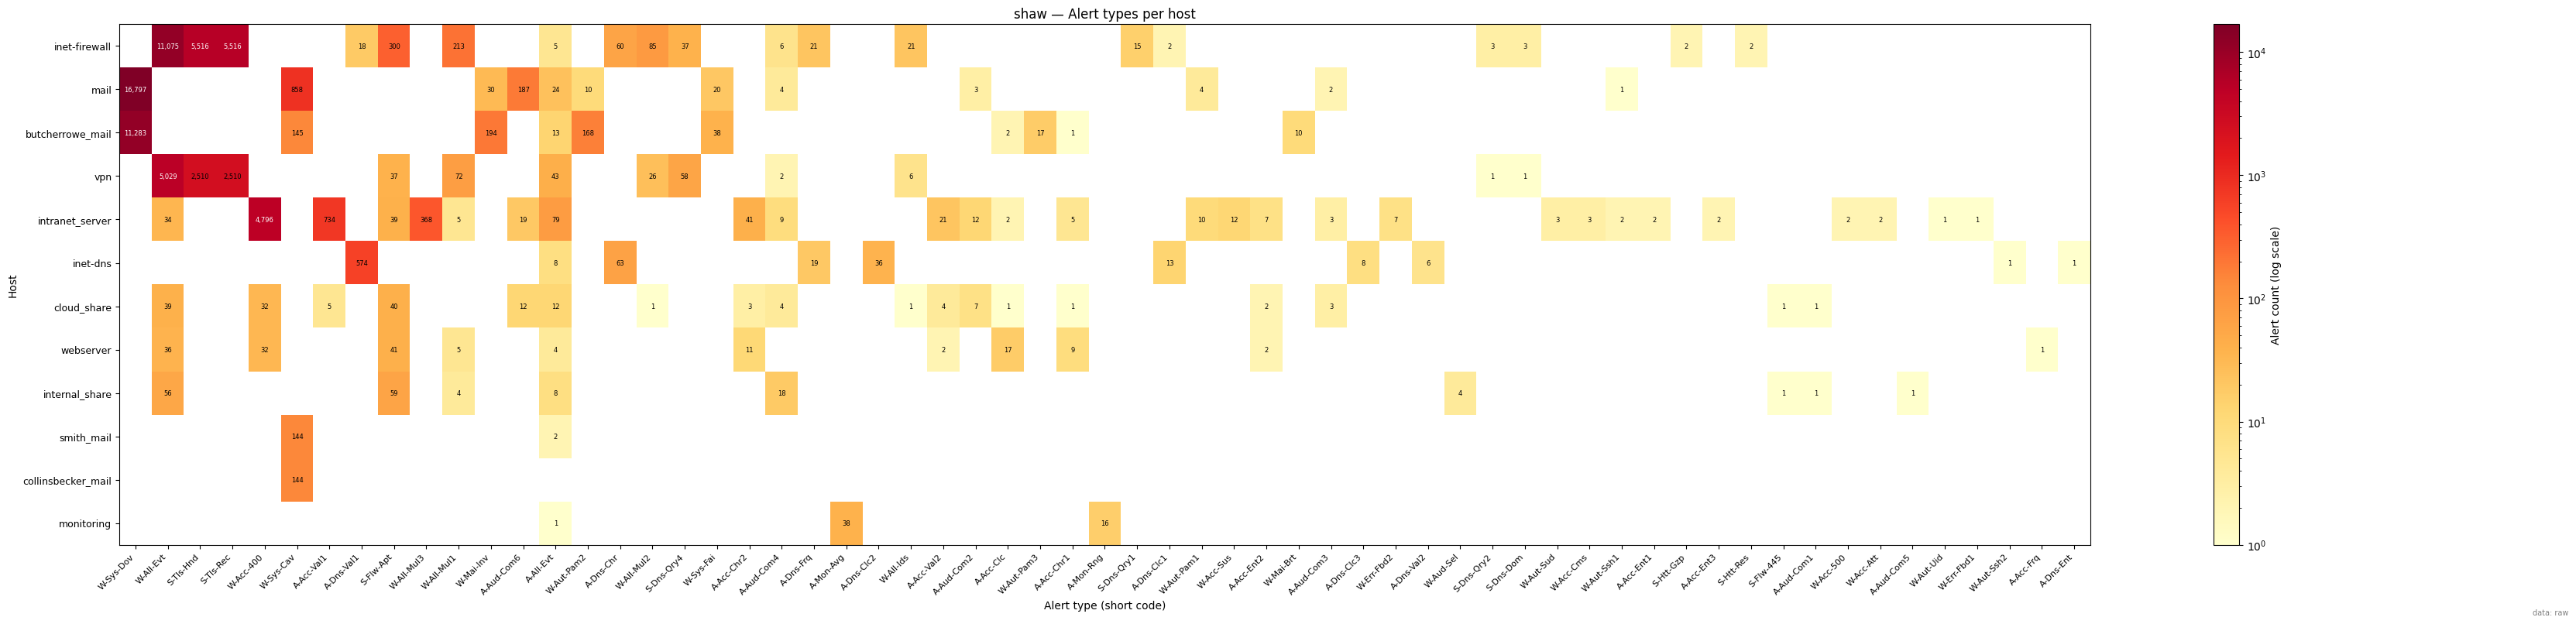

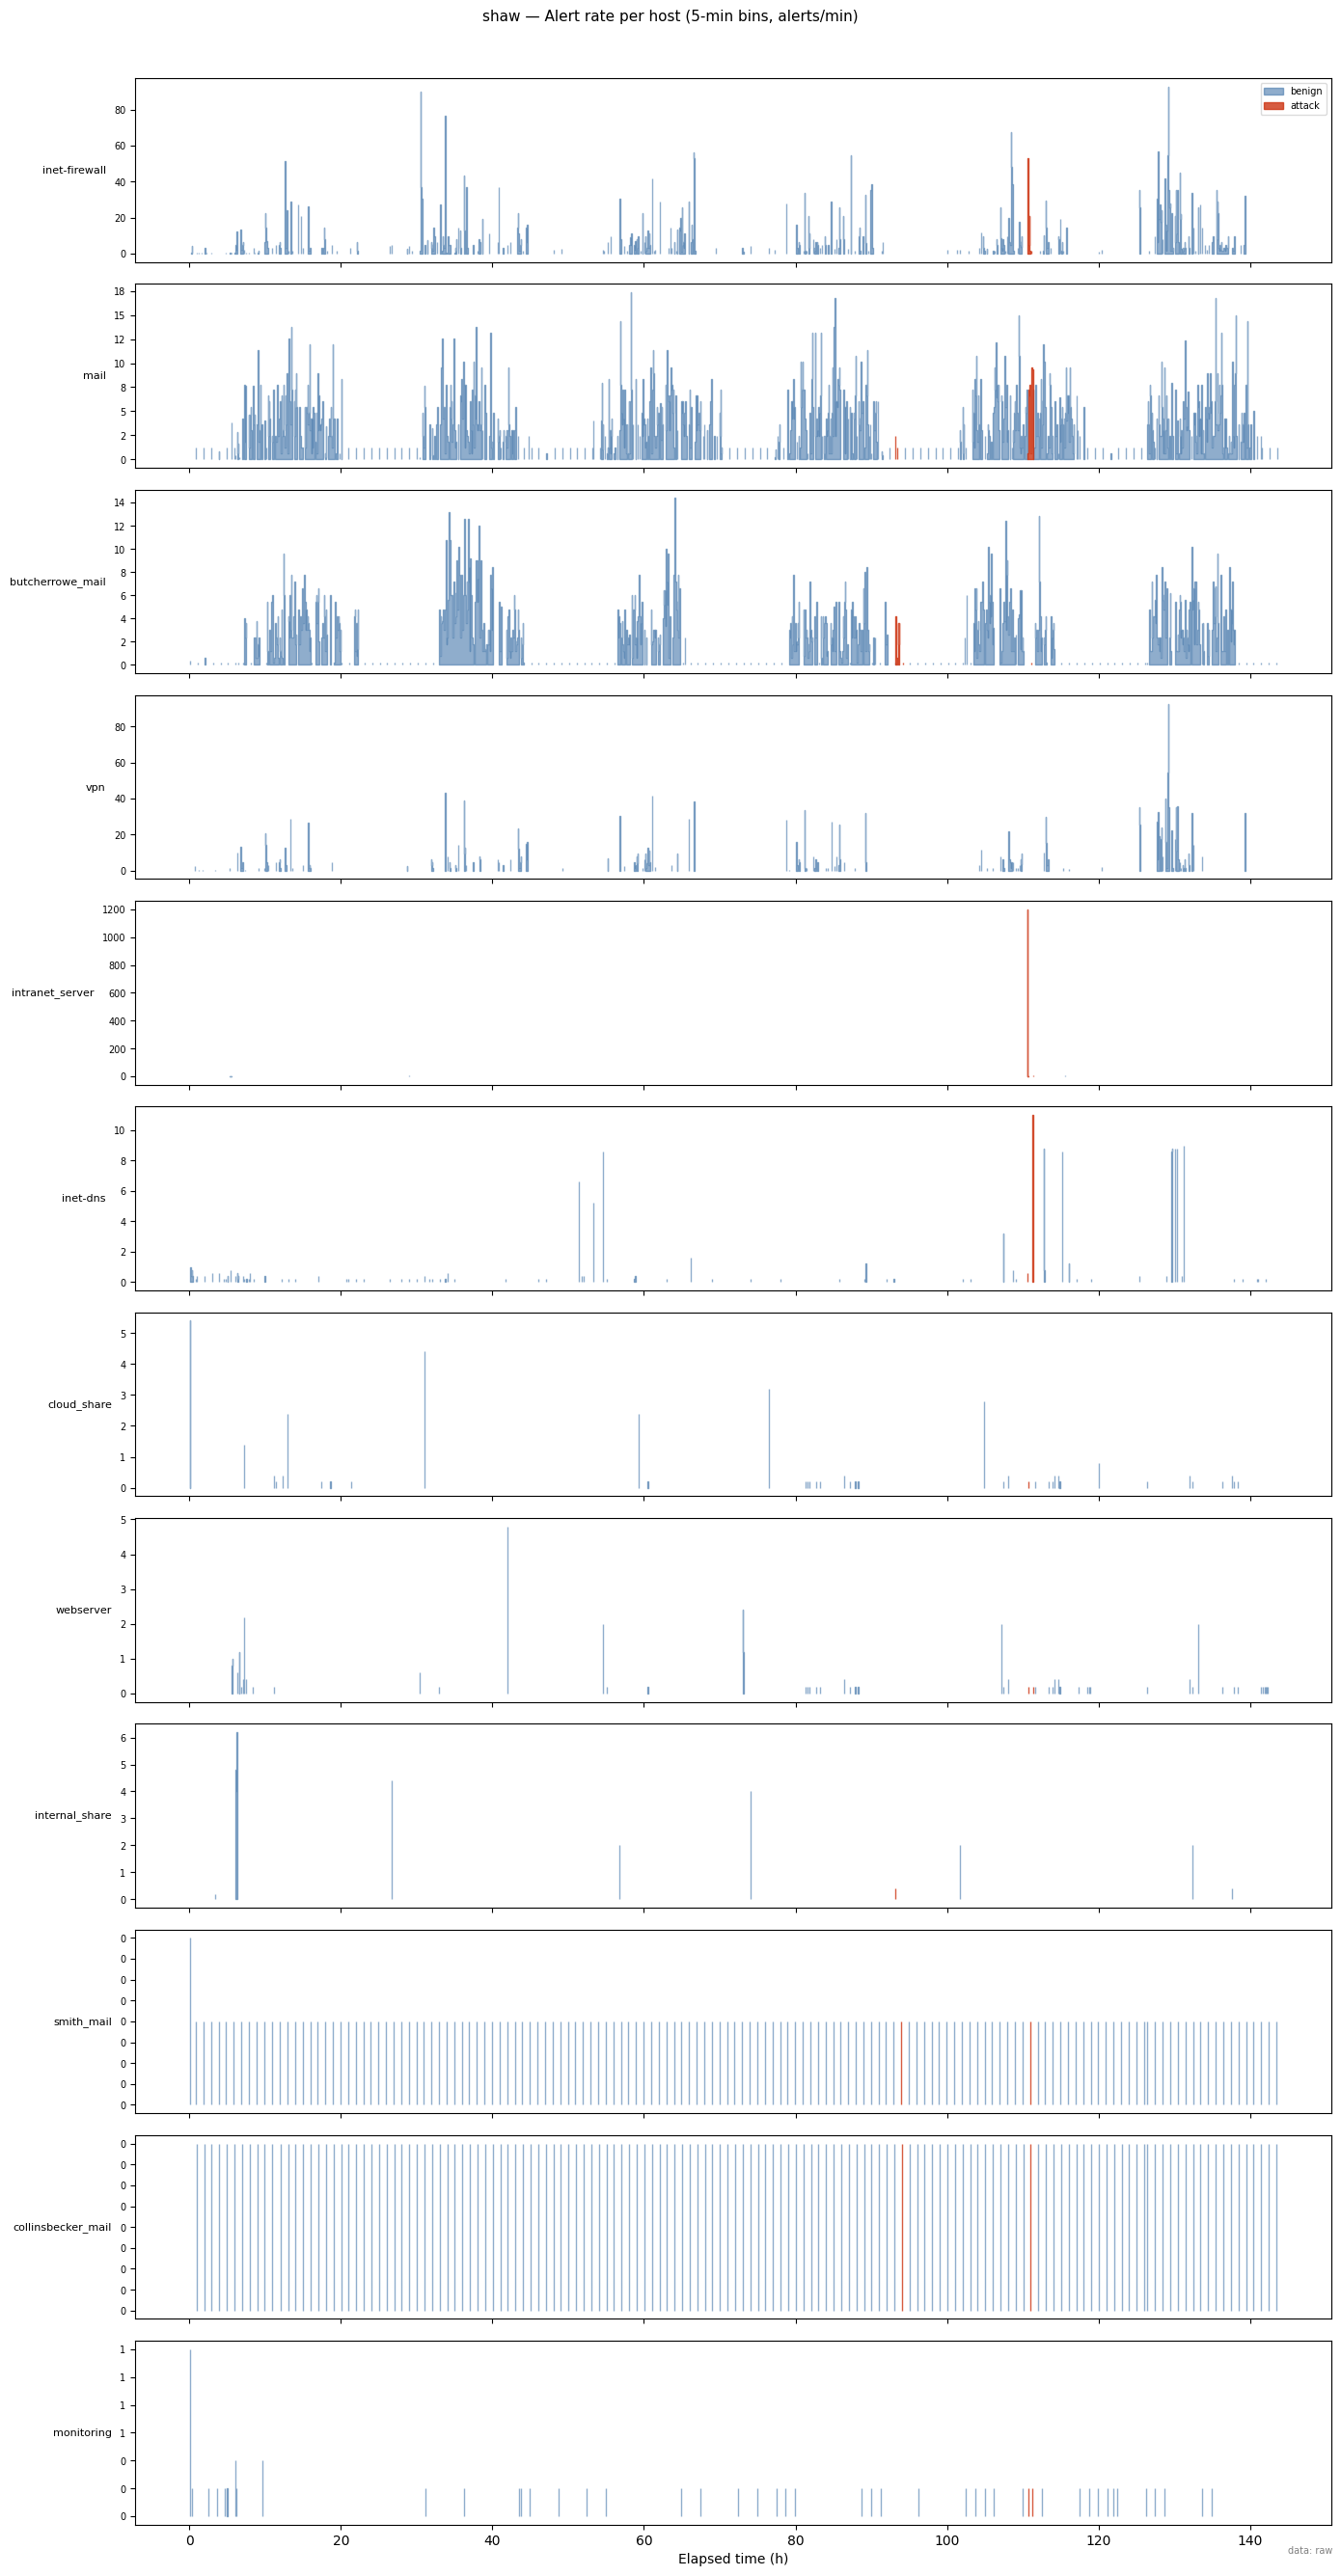

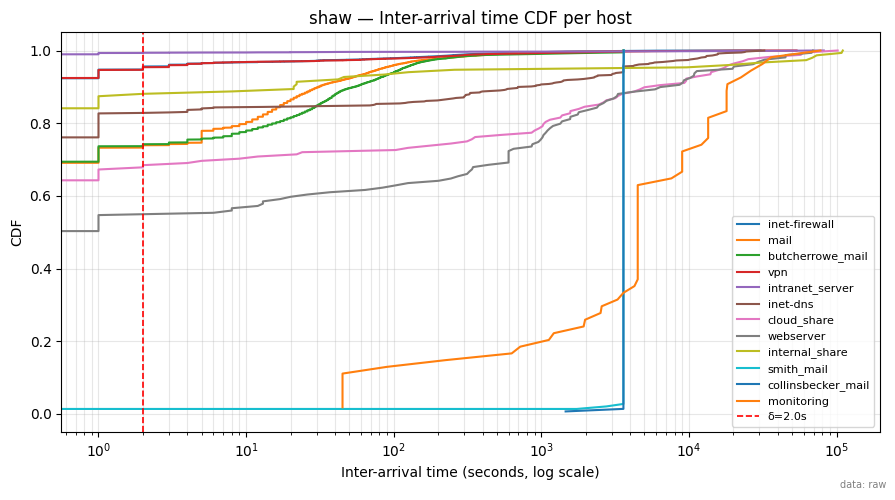

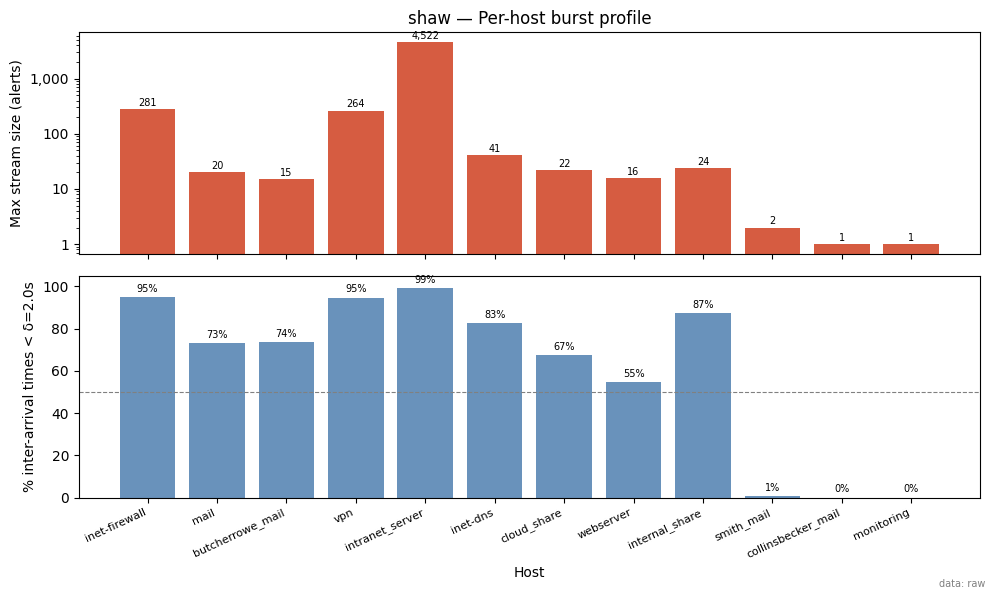

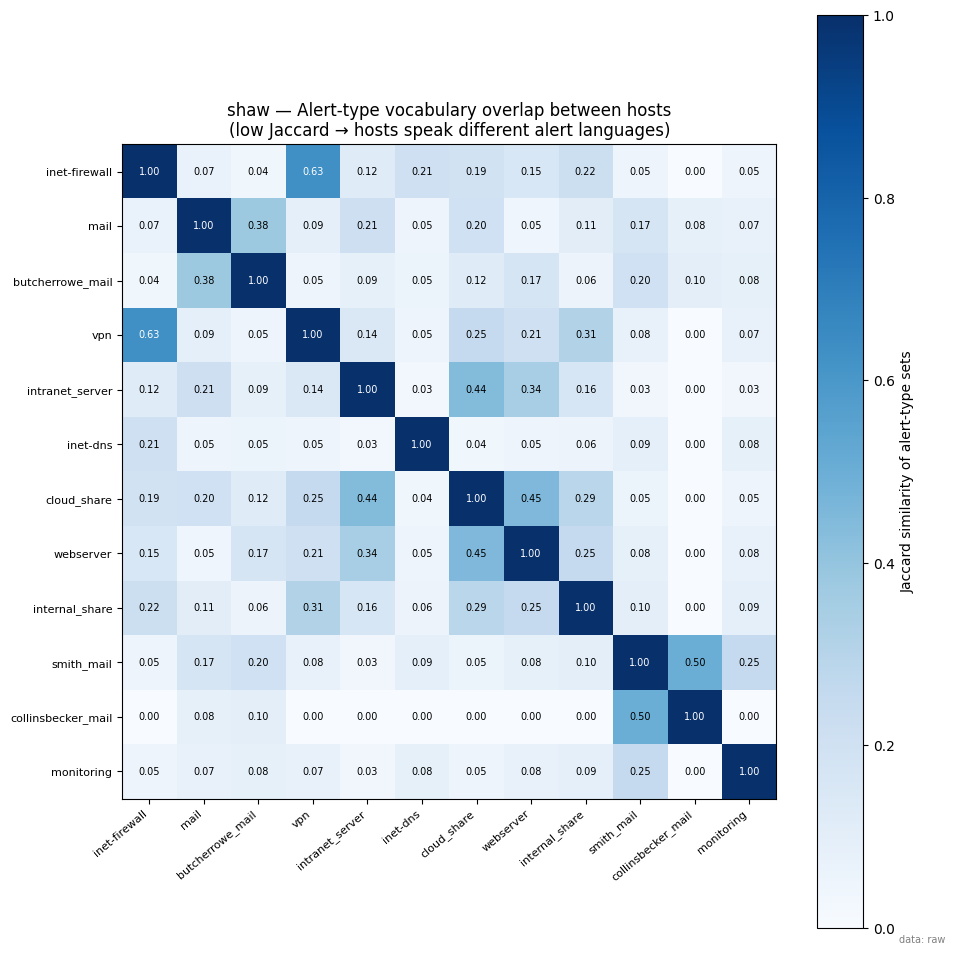

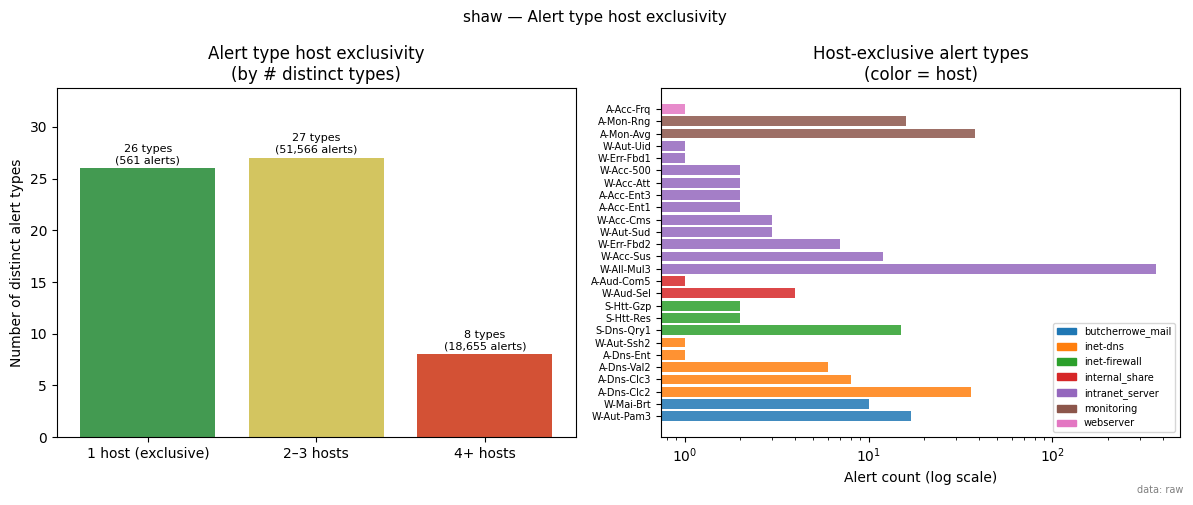

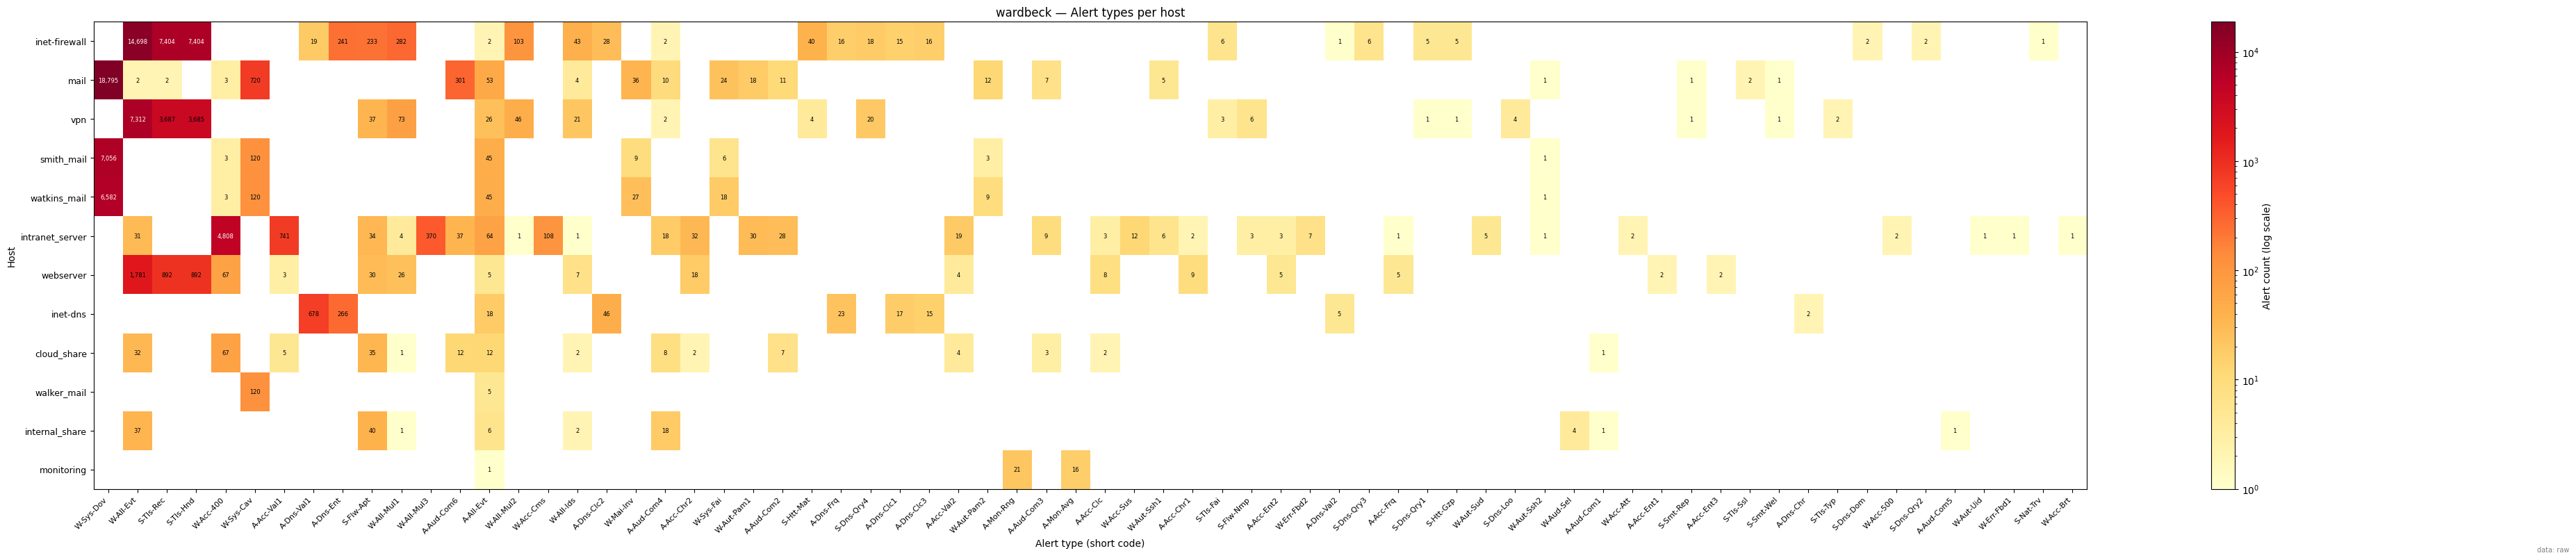

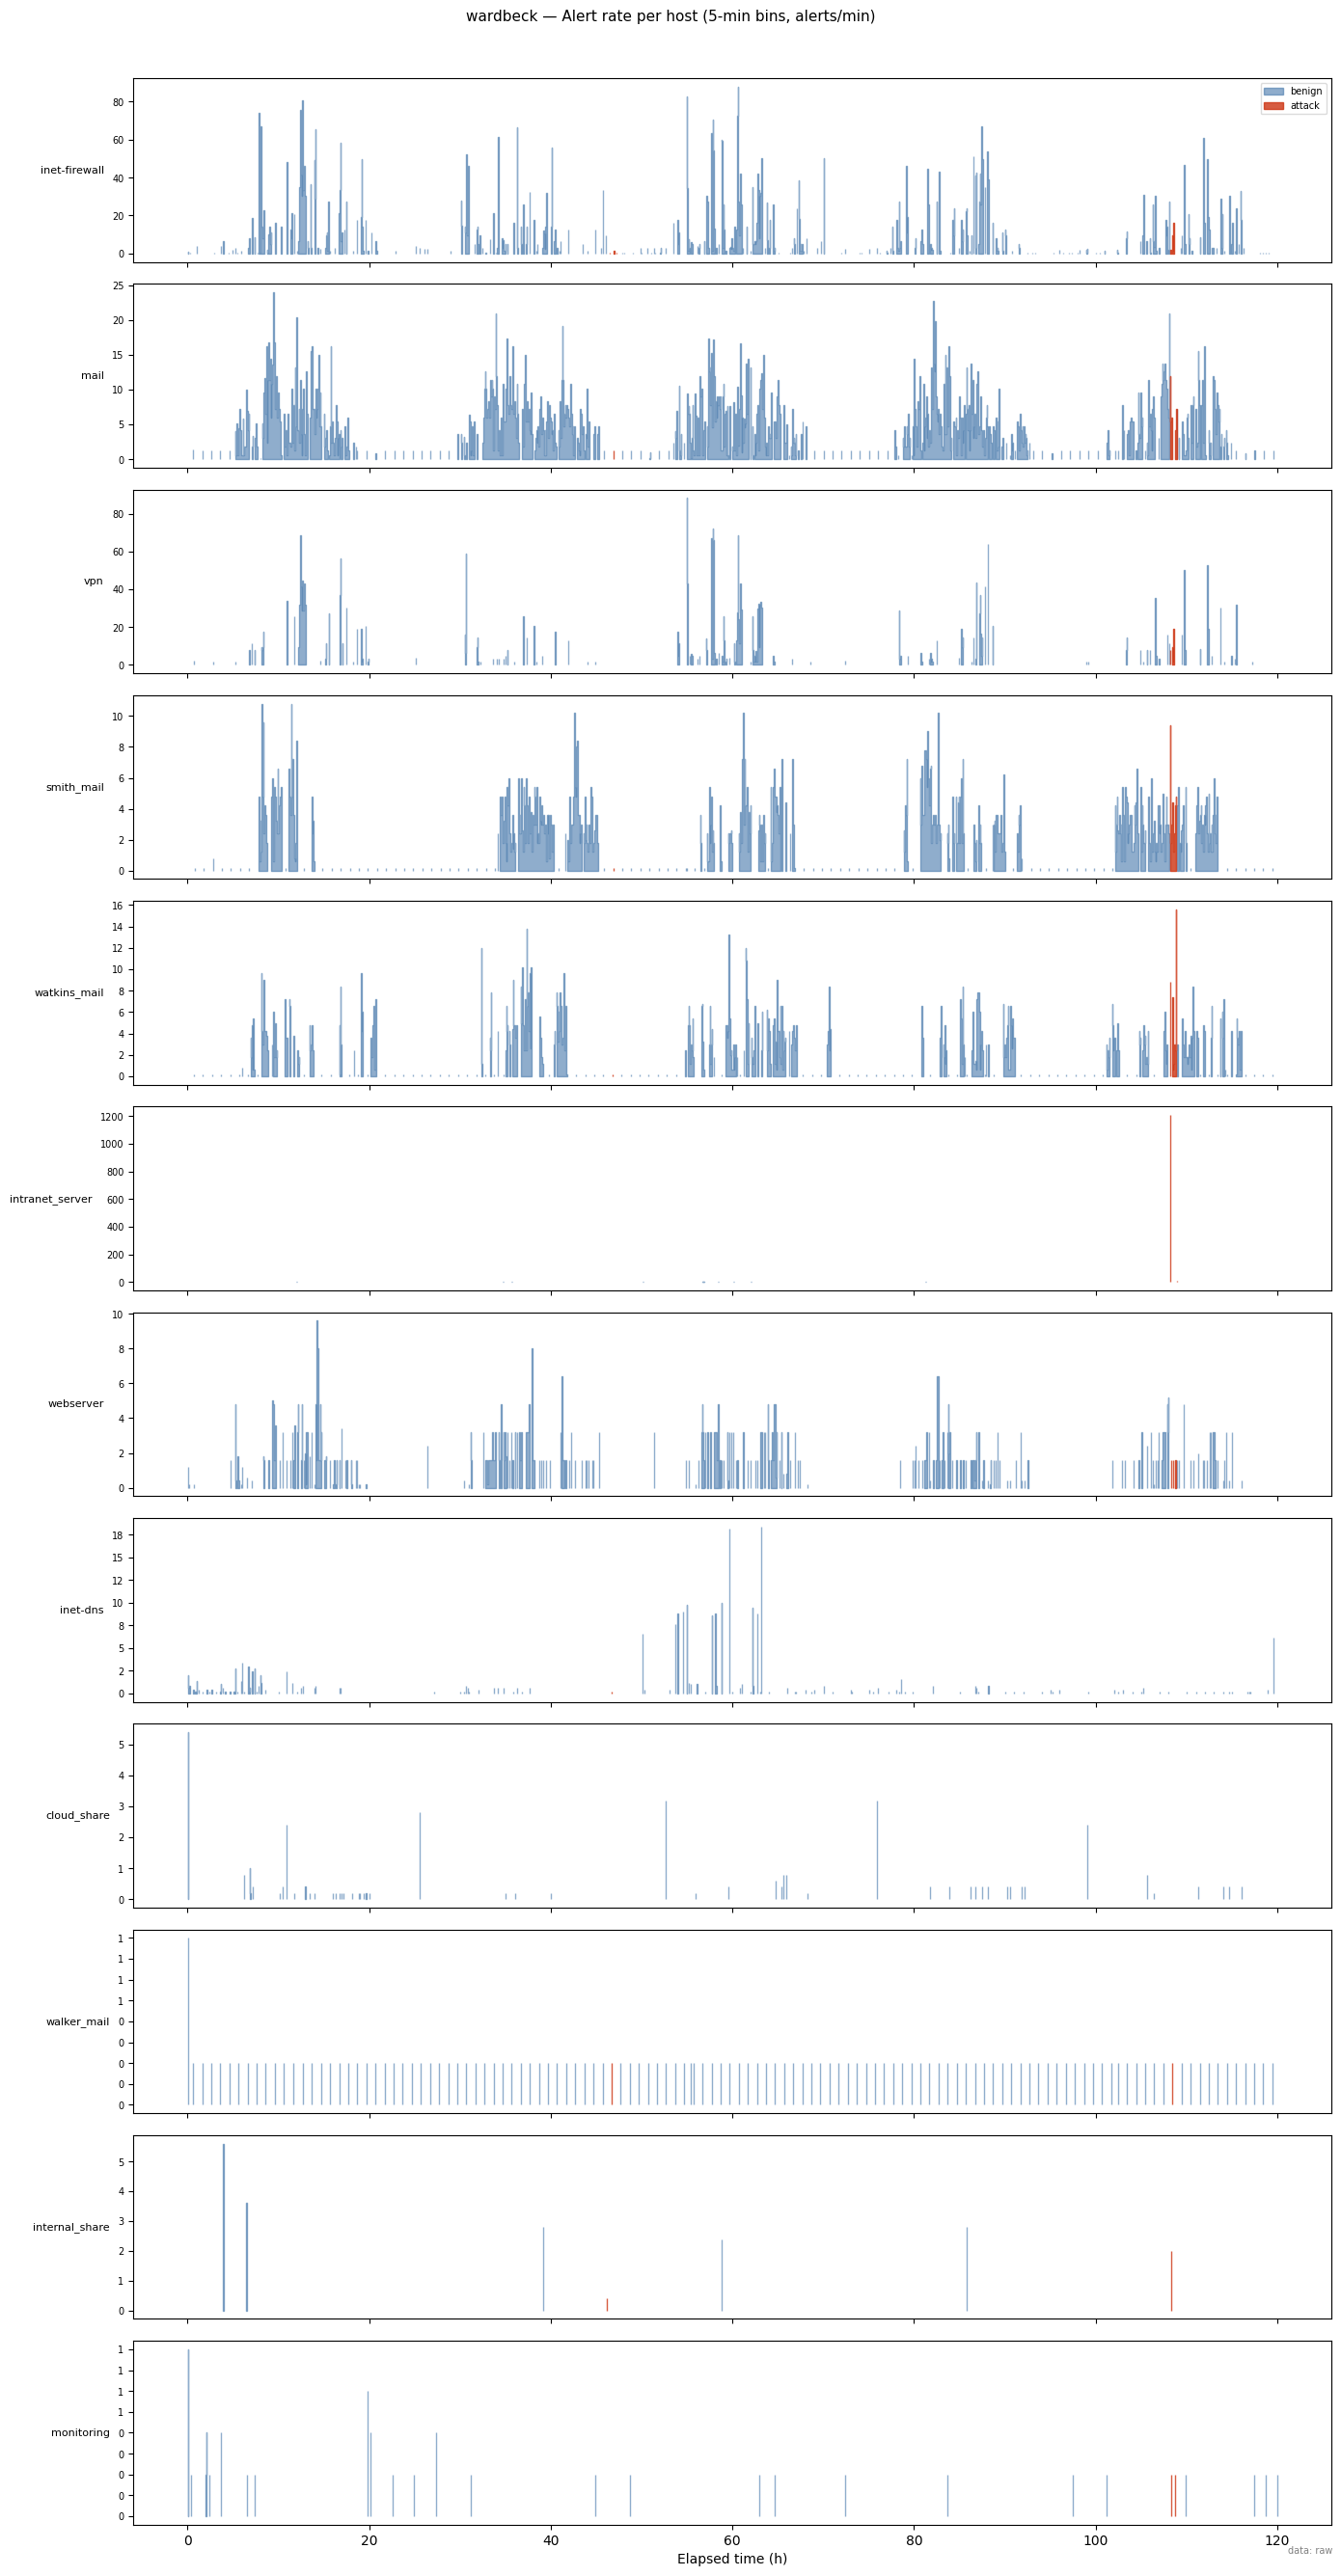

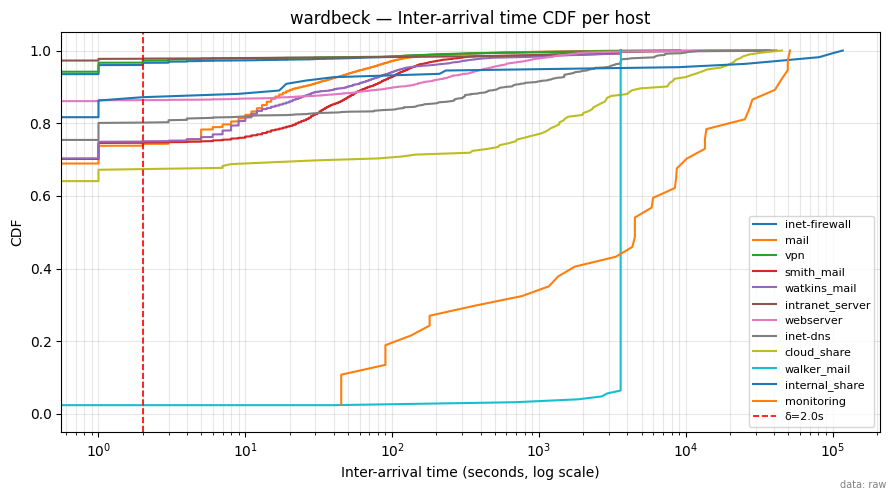

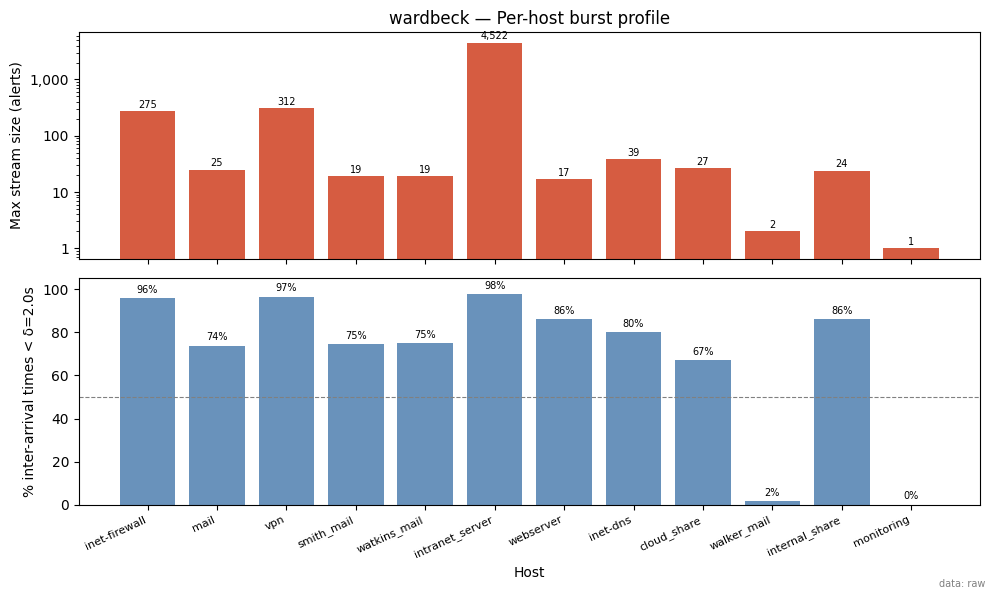

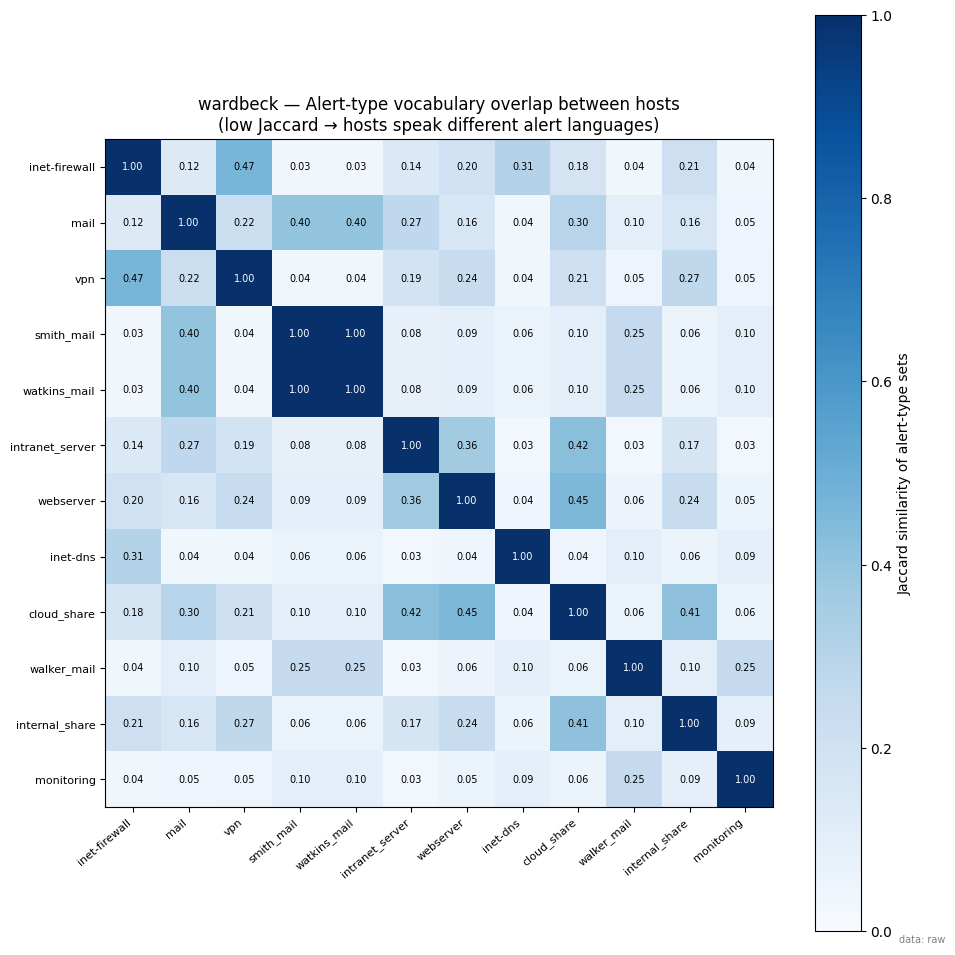

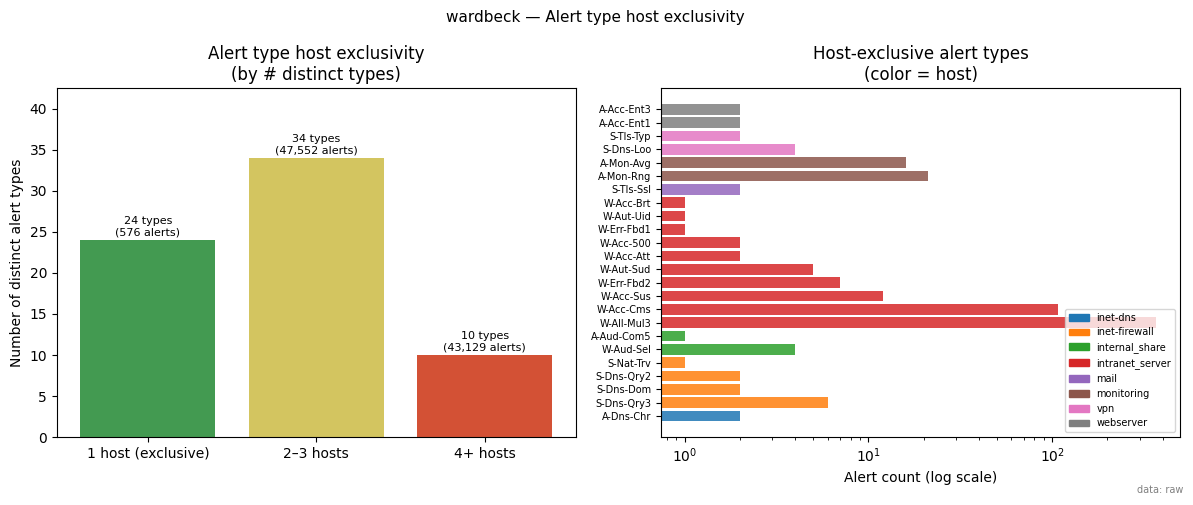

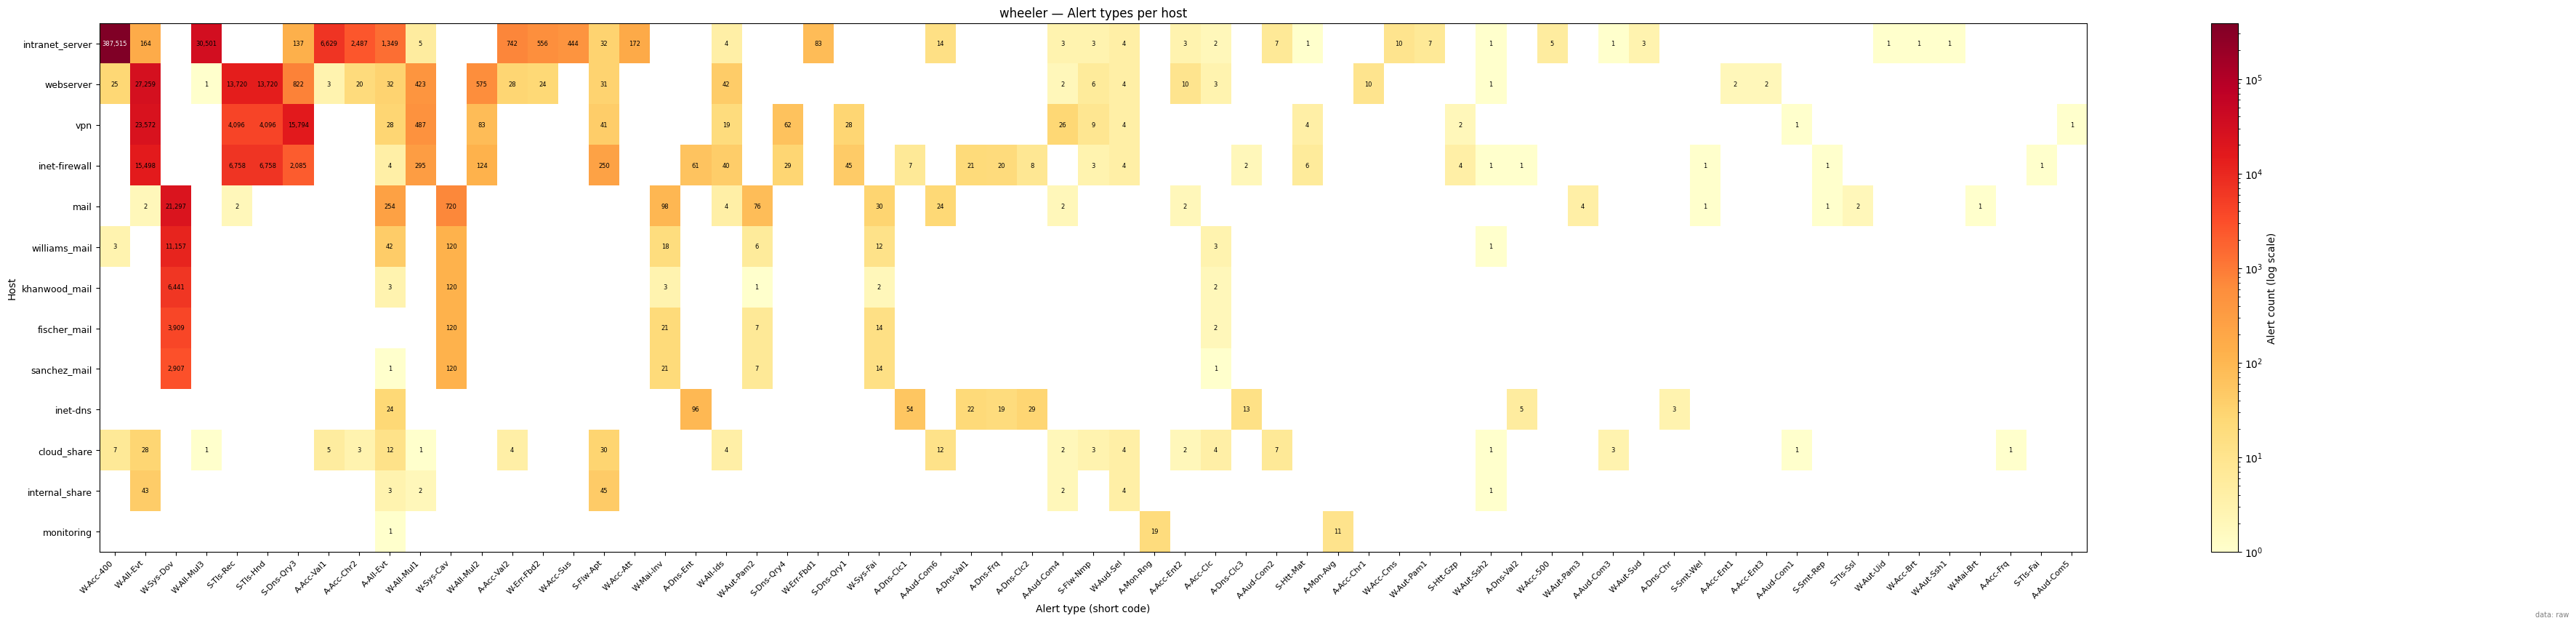

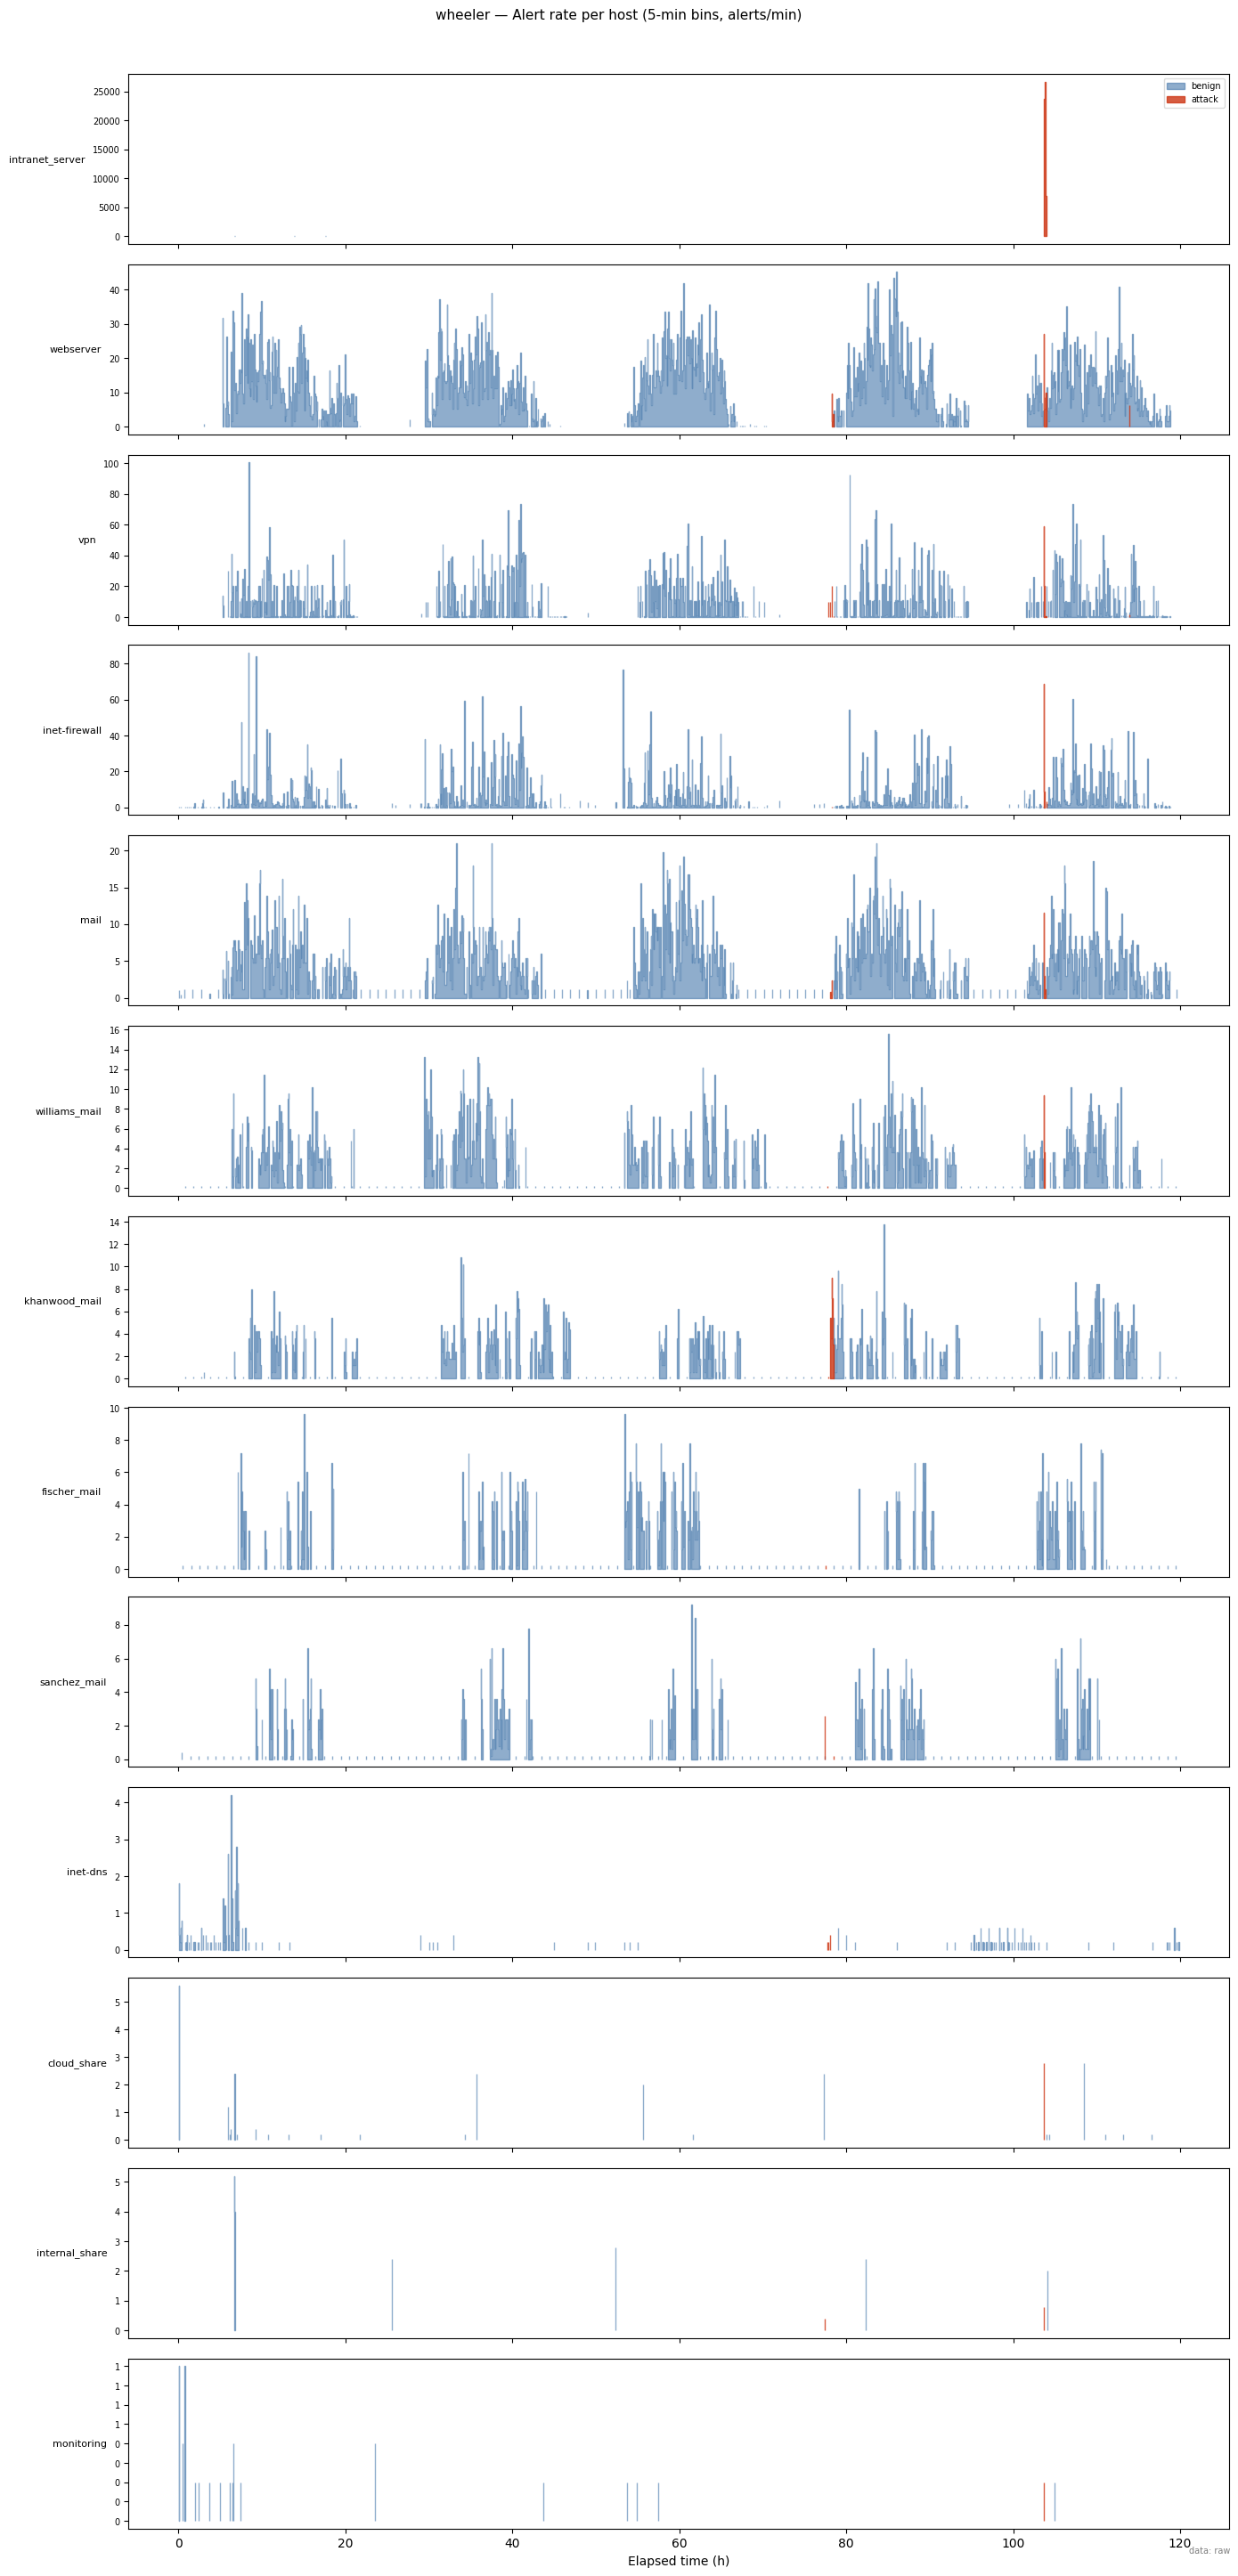

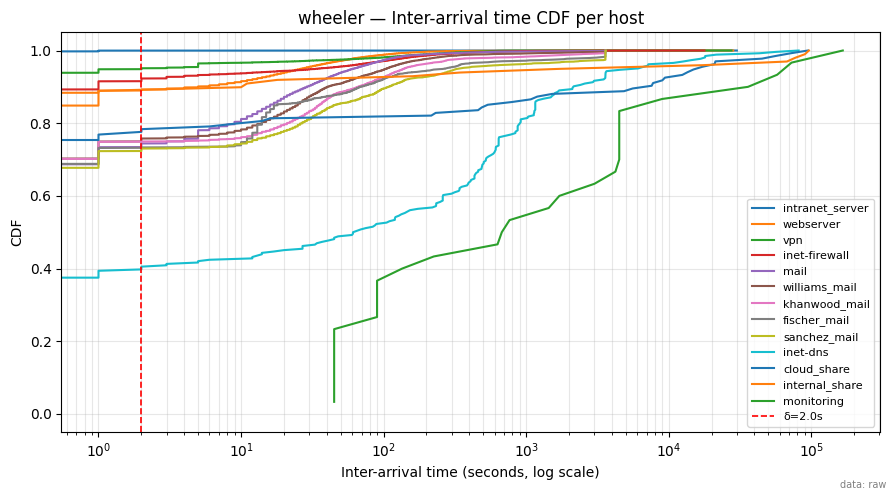

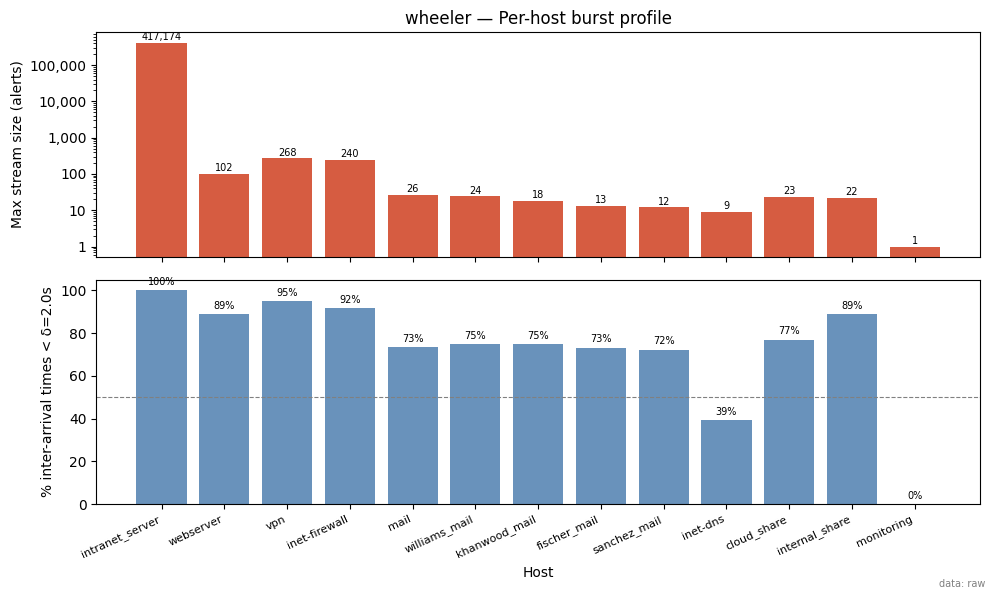

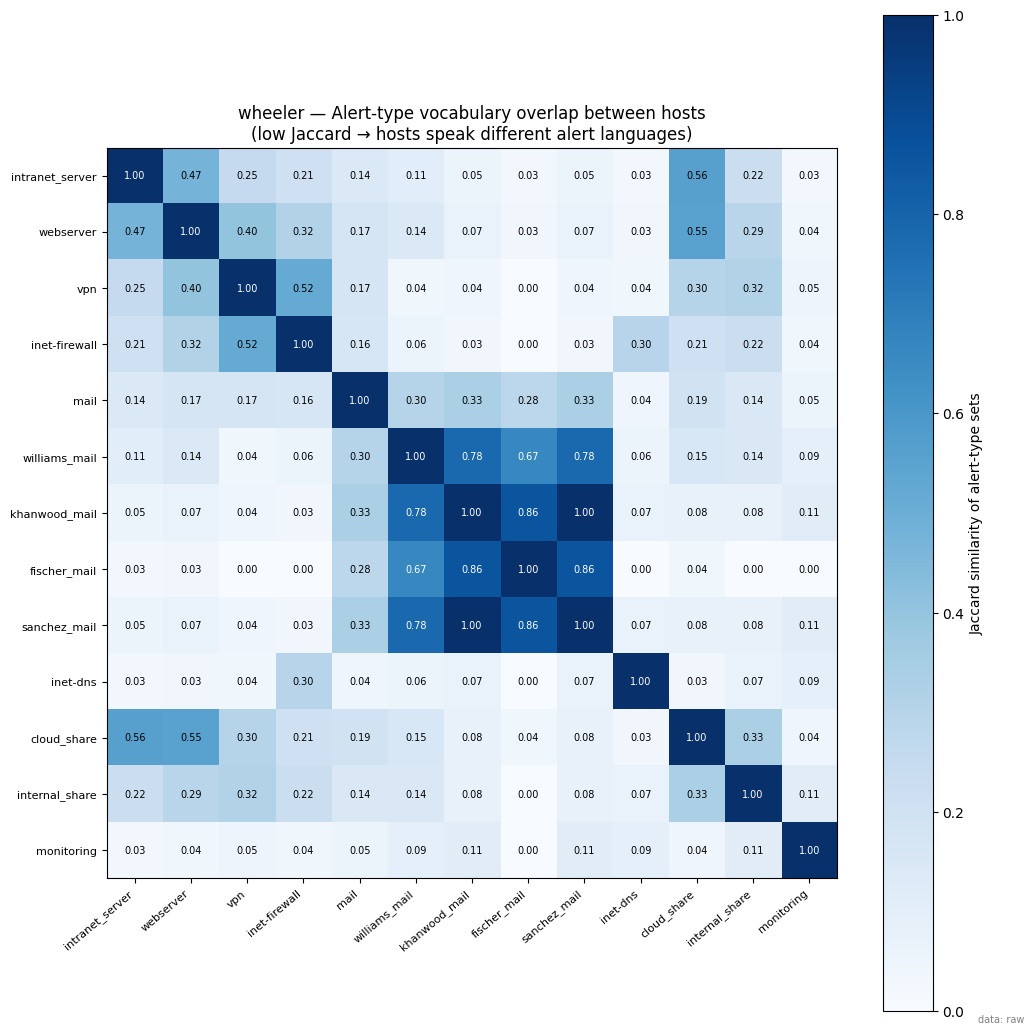

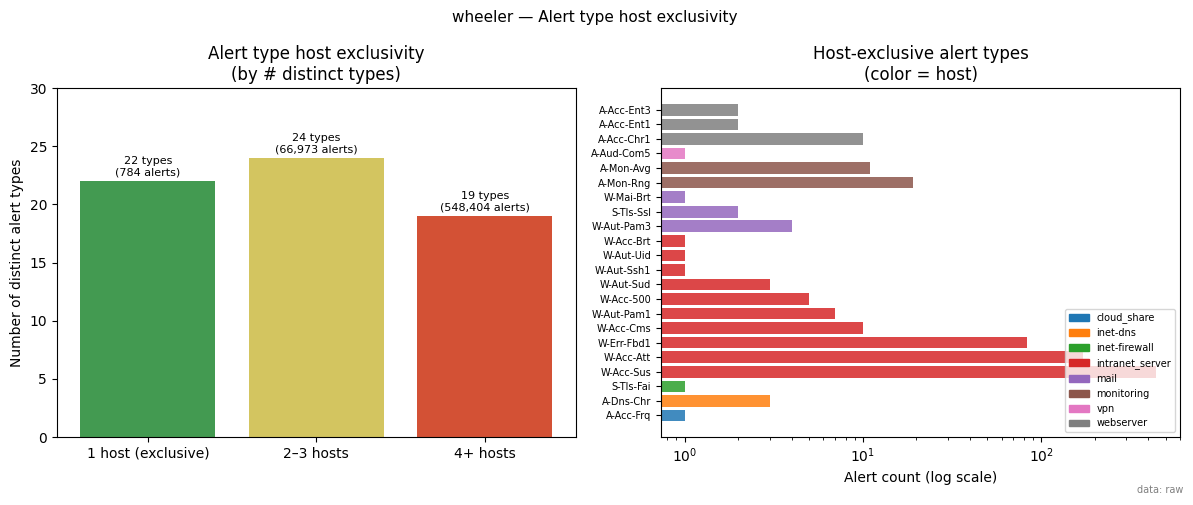

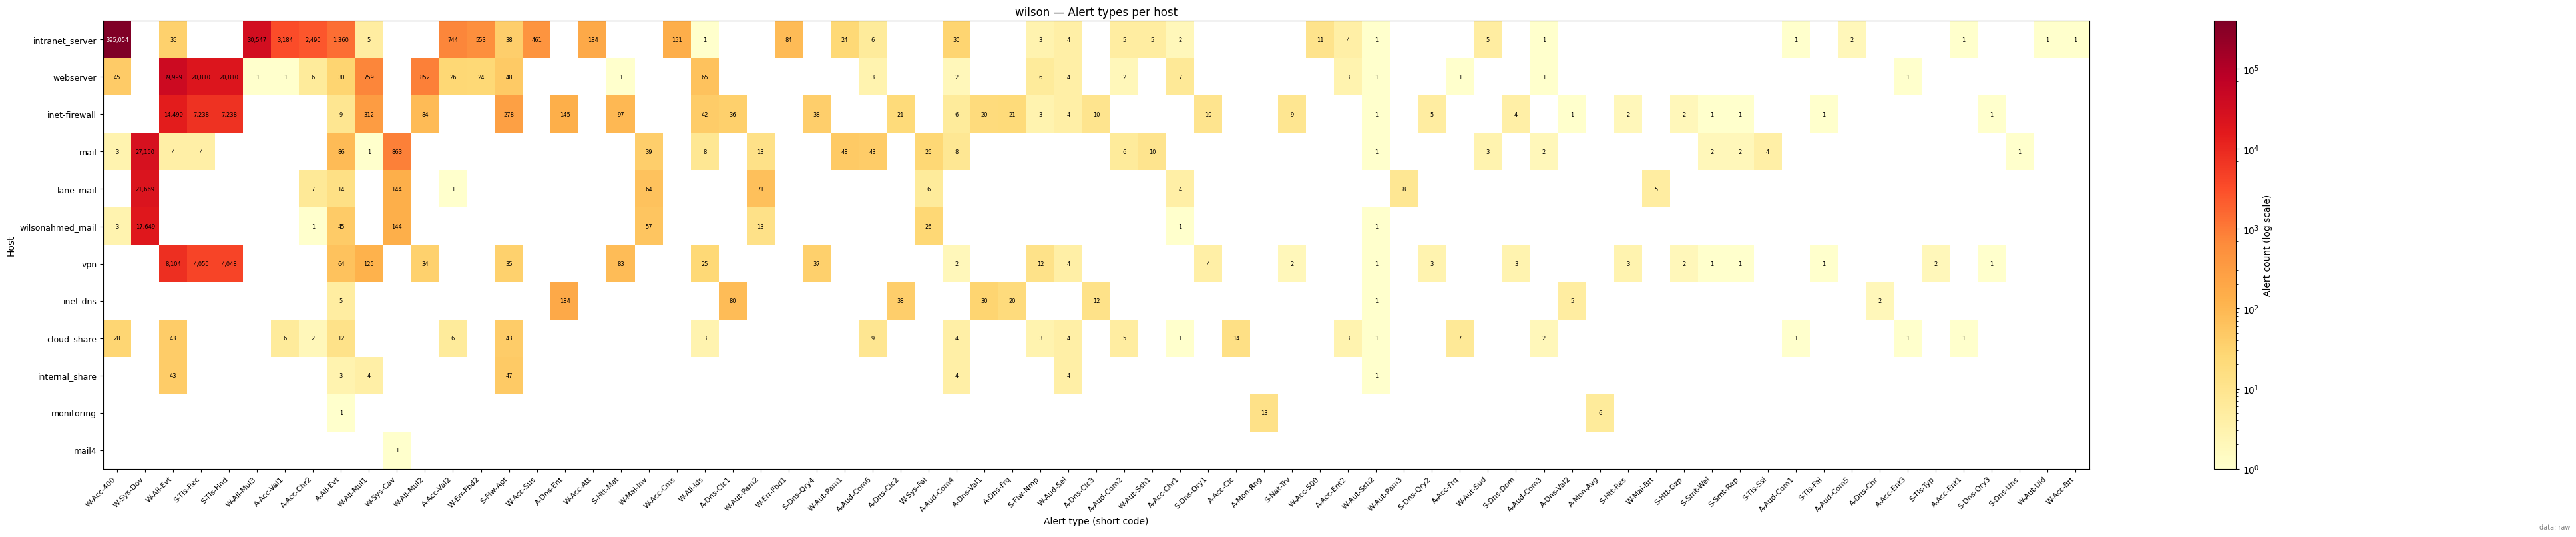

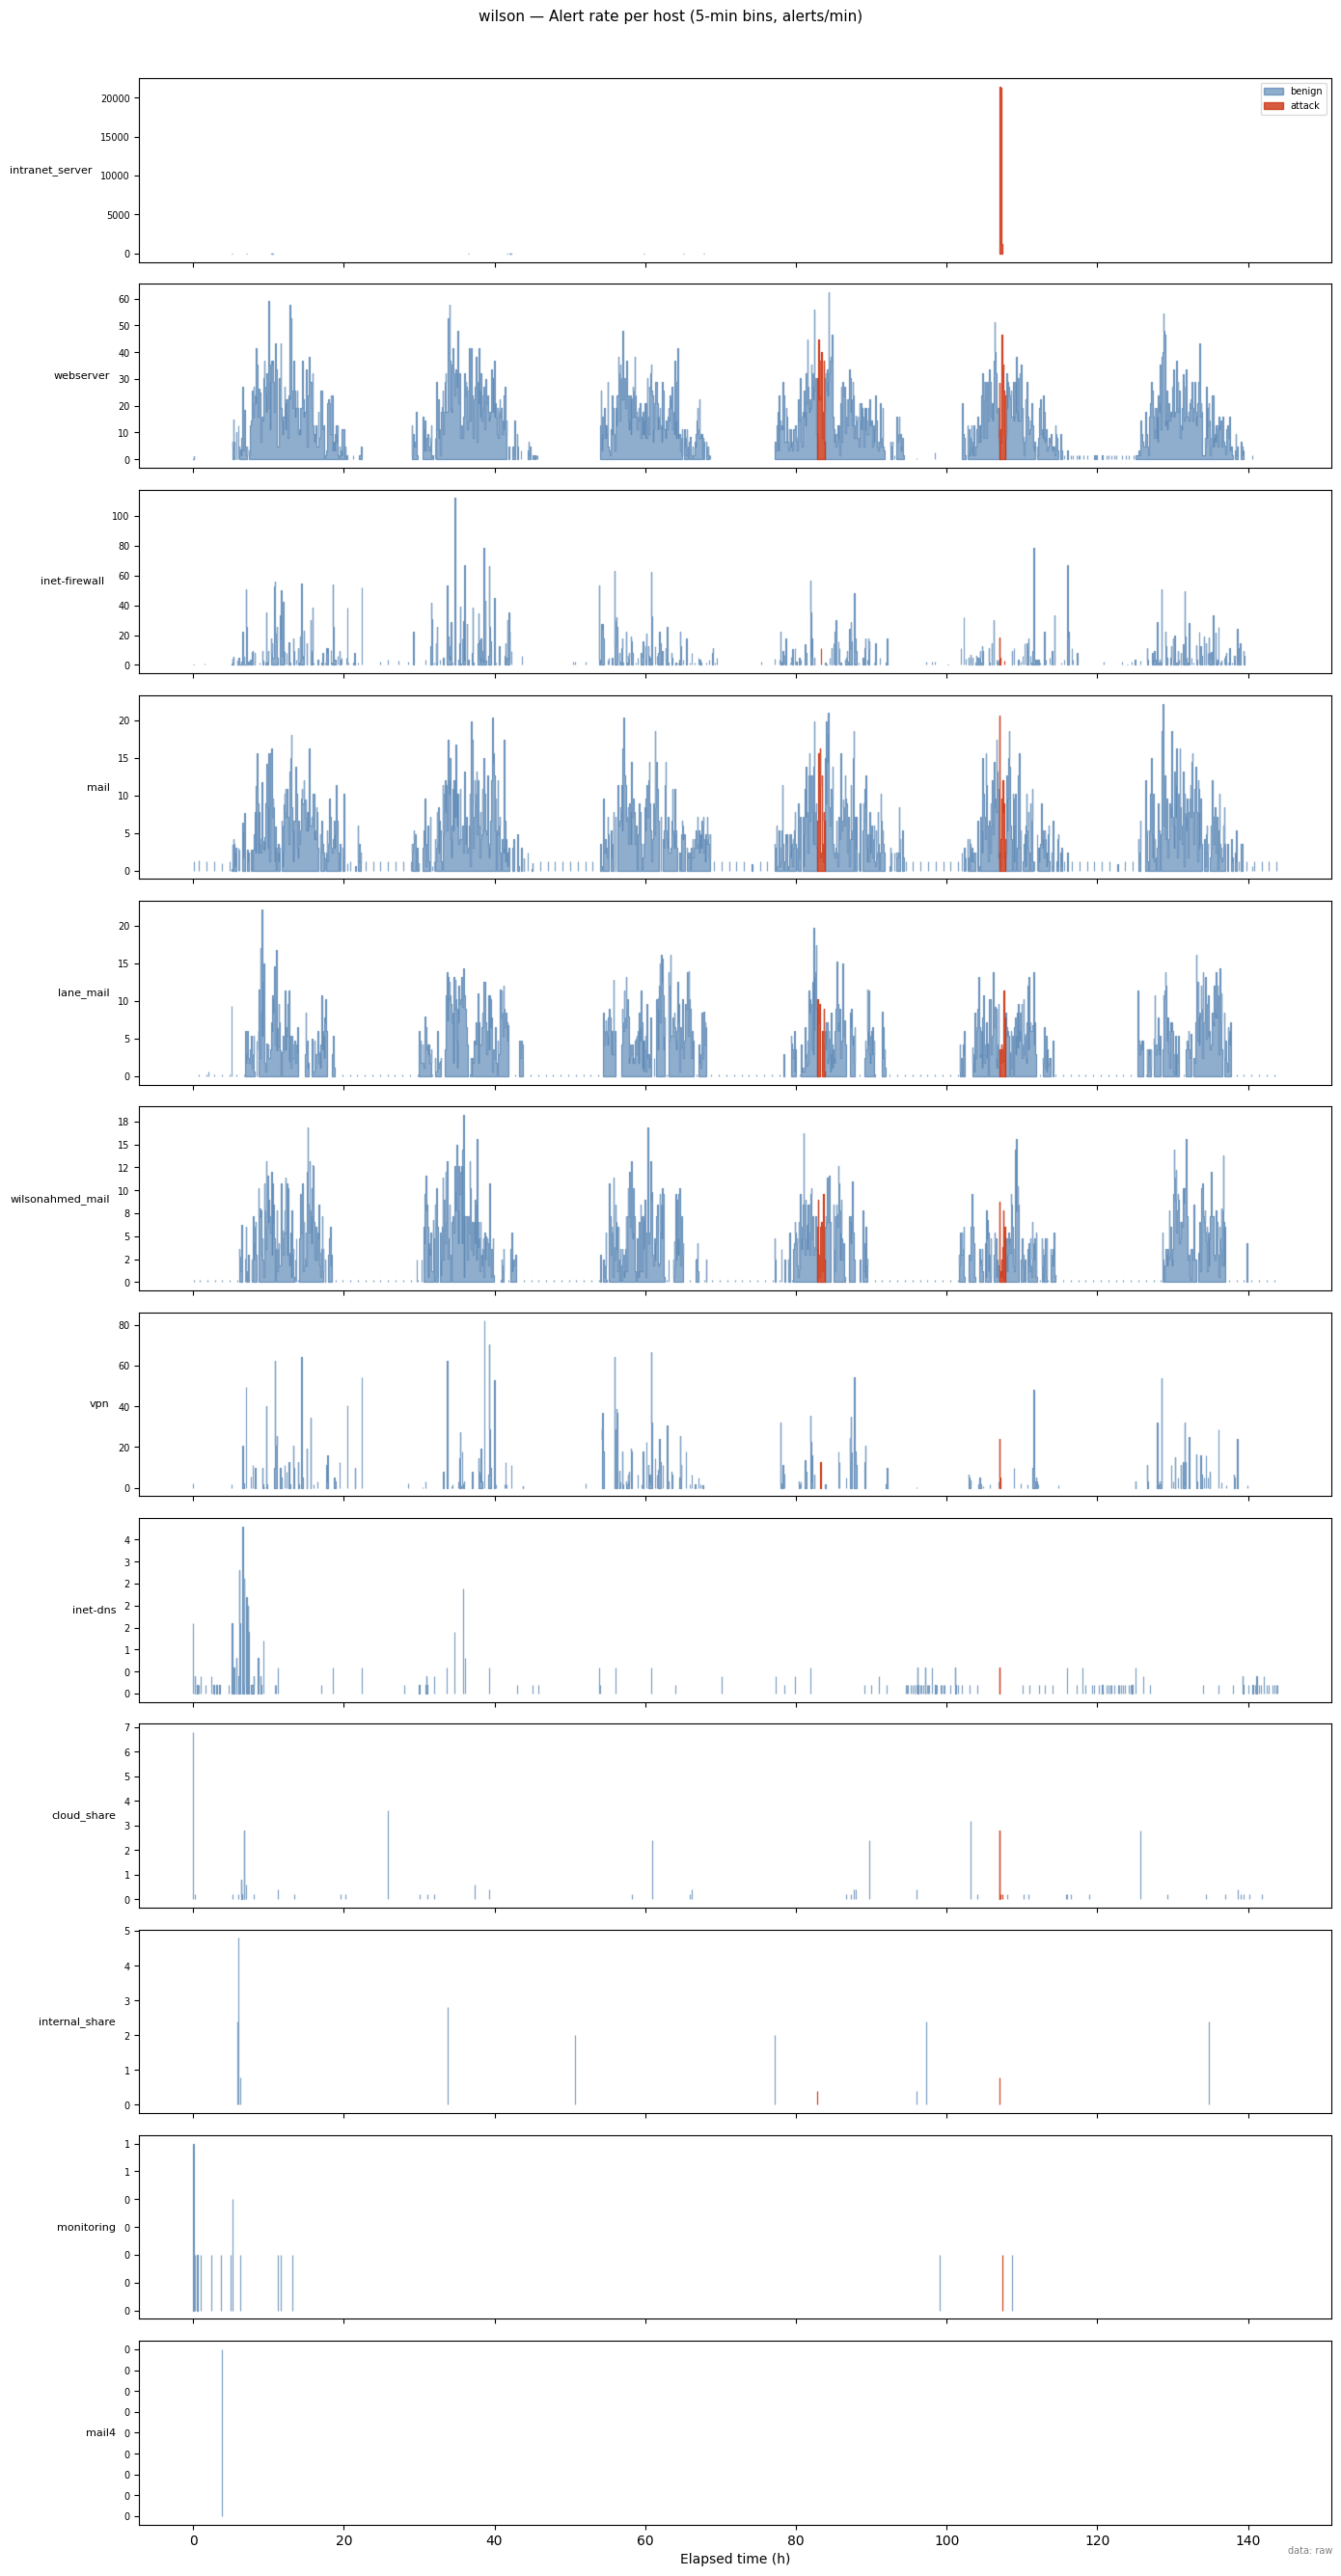

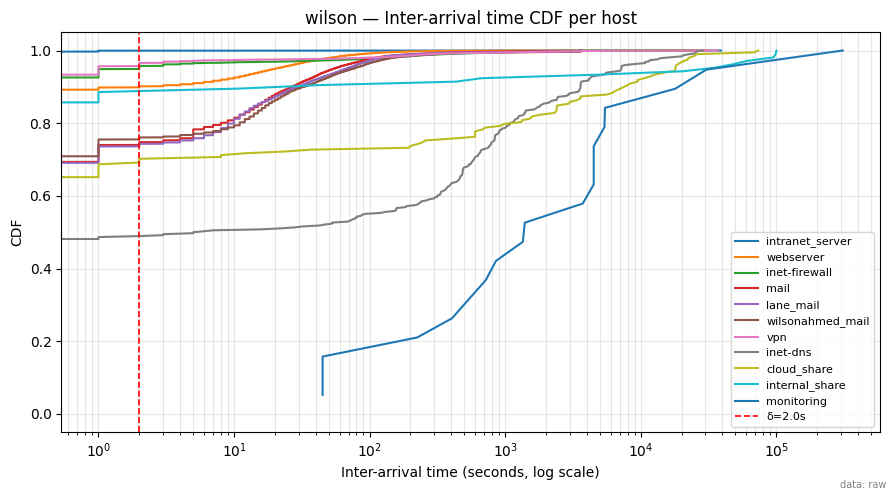

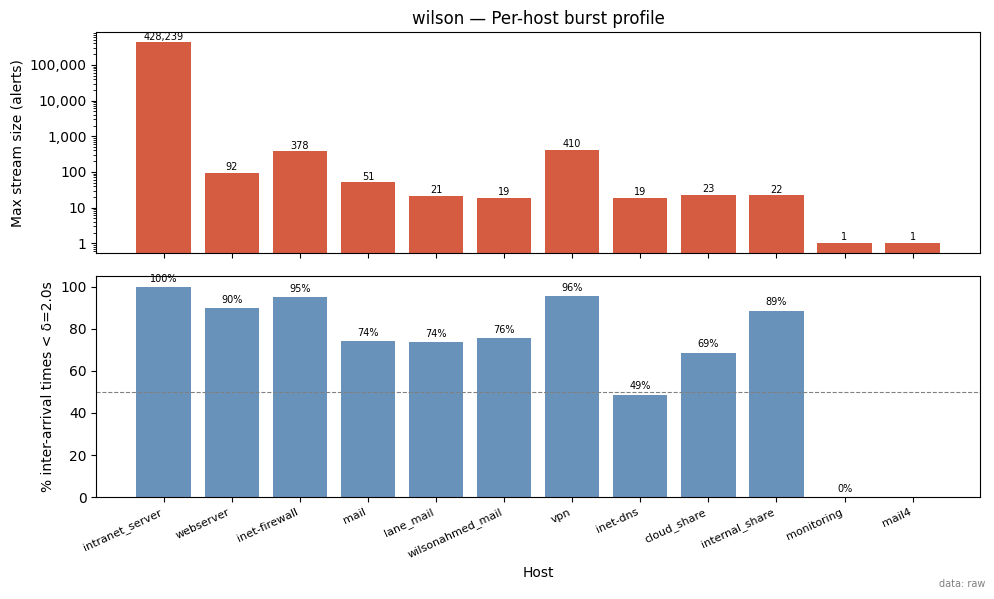

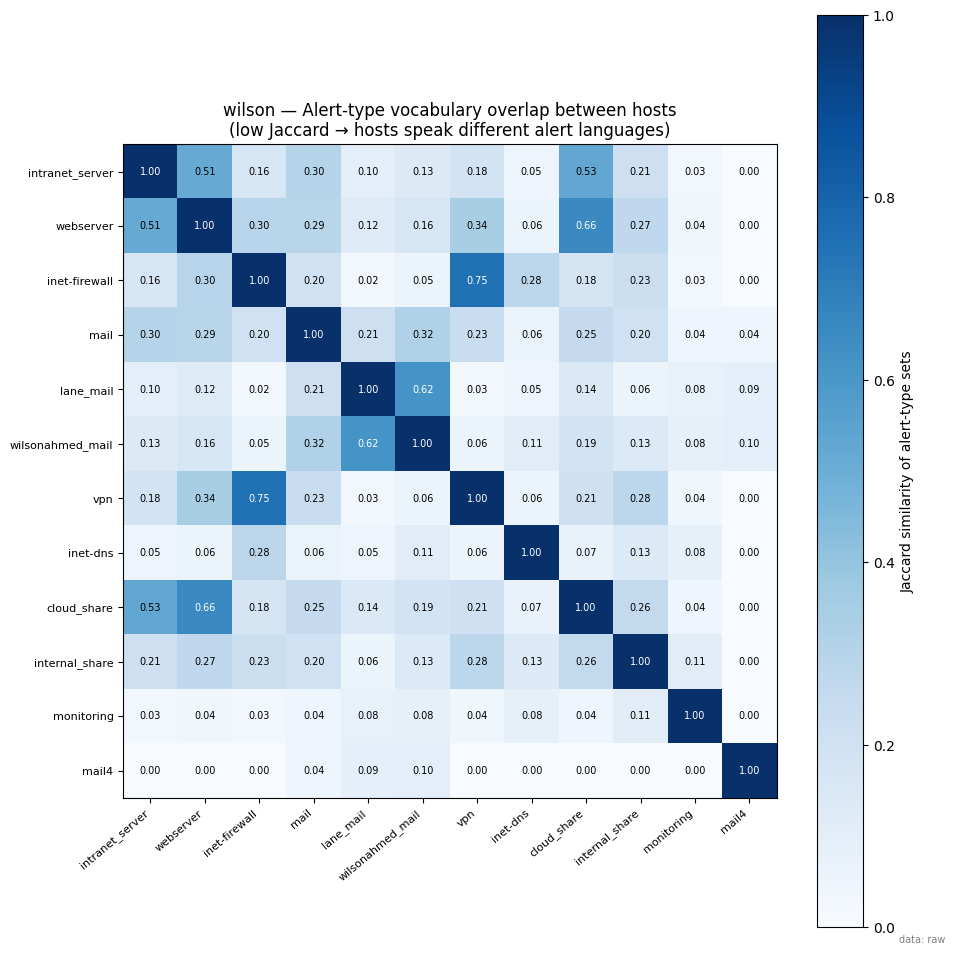

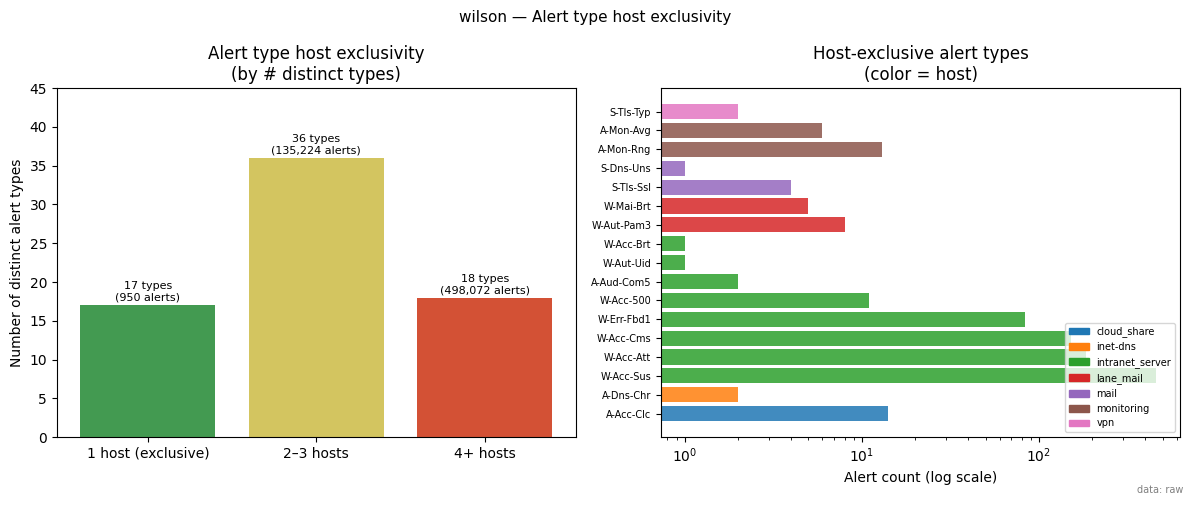

In [11]:
host_run_dir = REPO / 'artifacts' / 'experiments' / 'run_eda_host' / f'run_{run_ts}'
for scenario in scenarios:
    de.run_host_scenario_eda(scenario, host_run_dir)